# Notebook base limpio — Fases 1 a 7
## Segmentación semántica multifuente con U-Net preentrenado

Este notebook implementa las fases **1 a 7** del nuevo flujo:

1. Crear la nueva estructura del notebook  
2. Migrar solo la auditoría de datos útil  
3. Cerrar contrato de entradas y clases  
4. Redefinir normalización  
5. Rehacer split espacial definitivo  
6. Rehacer generación y filtrado de tiles  
7. Definir estrategia de balance de clases  

**Alcance de esta versión:**  
- todavía no define el modelo ni entrena  
- deja listo el pipeline de datos para conectar el modelo preentrenado  
- deja calculados los insumos que usaremos después para sampler y loss  

**Supuestos del problema:**  
- ortofoto de 4 bandas: `RGB + NIR`  
- raster de altura / nDSM de 1 banda  
- máscara multiclase con clases `{0,1,2,3,4}` e `ignore = 255`


In [3]:
# ============================================================
# 2. AUDITORÍA INICIAL DE INSUMOS
# ============================================================

assert_files_exist([PATHS.ortho_fp, PATHS.ndsm_fp, PATHS.mask_fp])

ortho_summary = read_raster_summary(PATHS.ortho_fp)
ndsm_summary  = read_raster_summary(PATHS.ndsm_fp)
mask_summary  = read_raster_summary(PATHS.mask_fp)

pretty_print_summary("ORTOFOTO", ortho_summary)
pretty_print_summary("NDSM", ndsm_summary)
pretty_print_summary("MÁSCARA", mask_summary)



=== ORTOFOTO ===
path: /home/jovyan/work/datos/DATOS_AJUSTADOS/orto_clip.tif
name: orto_clip.tif
count: 4
height: 27538
width: 19589
shape_hw: (27538, 19589)
dtype: ('uint16', 'uint16', 'uint16', 'uint16')
crs: ESRI:103599
transform: | 0.06, 0.00, 4960588.34|
| 0.00,-0.06, 2172054.84|
| 0.00, 0.00, 1.00|
res: (0.06024280898080917, 0.06024280898080917)
nodata: 65535.0
bounds: BoundingBox(left=4960588.342404325, bottom=2170395.8692393457, right=4961768.43878945, top=2172054.835713059)

=== NDSM ===
path: /home/jovyan/work/datos/DATOS_AJUSTADOS/ndsm_clip_corr0.tif
name: ndsm_clip_corr0.tif
count: 1
height: 27538
width: 19589
shape_hw: (27538, 19589)
dtype: ('float32',)
crs: ESRI:103599
transform: | 0.06, 0.00, 4960588.34|
| 0.00,-0.06, 2172054.84|
| 0.00, 0.00, 1.00|
res: (0.06024280898080917, 0.060242808980808964)
nodata: -3.4028230607370965e+38
bounds: BoundingBox(left=4960588.342404325, bottom=2170395.8692393457, right=4961768.43878945, top=2172054.835713059)

=== MÁSCARA ===
path: /h

In [4]:

# ============================================================
# 2.1 VALIDACIÓN DE COMPATIBILIDAD ESPACIAL
# ============================================================

def transforms_close(t1, t2, tol: float = 1e-6) -> bool:
    return all(abs(a - b) <= tol for a, b in zip(tuple(t1), tuple(t2)))

def validate_spatial_compatibility(
    ortho: Dict,
    ndsm: Dict,
    mask: Dict,
    tol: float = 1e-6,
) -> None:
    assert ortho["shape_hw"] == ndsm["shape_hw"] == mask["shape_hw"], (
        "Las dimensiones espaciales no coinciden entre ortofoto, nDSM y máscara."
    )
    assert ortho["crs"] == ndsm["crs"] == mask["crs"], (
        "Los CRS no coinciden entre ortofoto, nDSM y máscara."
    )
    assert transforms_close(ortho["transform"], ndsm["transform"], tol=tol), (
        "La transformada de la ortofoto y el nDSM no coincide."
    )
    assert transforms_close(ortho["transform"], mask["transform"], tol=tol), (
        "La transformada de la ortofoto y la máscara no coincide."
    )
    assert transforms_close(ndsm["transform"], mask["transform"], tol=tol), (
        "La transformada del nDSM y la máscara no coincide."
    )

validate_spatial_compatibility(ortho_summary, ndsm_summary, mask_summary)
print("Compatibilidad espacial validada correctamente.")


Compatibilidad espacial validada correctamente.


In [5]:

# ============================================================
# 2.2 REPORTE DE CLASES, NODATA Y RANGOS BÁSICOS
# ============================================================

def load_mask_and_report(mask_fp: Path) -> Tuple[np.ndarray, Dict[int, int]]:
    with rasterio.open(mask_fp) as src:
        mask = src.read(1)

    classes, counts = np.unique(mask, return_counts=True)
    report = {int(c): int(n) for c, n in zip(classes, counts)}

    print("Clases encontradas en la máscara:")
    for c, n in report.items():
        print(f"  Clase {c}: {n:,} píxeles")

    return mask, report

def inspect_raster_range(fp: Path, title: str, band: int = 1) -> None:
    with rasterio.open(fp) as src:
        arr = src.read(band).astype(np.float32)

    finite = np.isfinite(arr)
    if not finite.any():
        print(f"{title}: no hay valores finitos.")
        return

    values = arr[finite]
    print(f"\n{title} — banda {band}")
    print(f"  min   : {values.min():.6f}")
    print(f"  p01   : {np.percentile(values, 1):.6f}")
    print(f"  p50   : {np.percentile(values, 50):.6f}")
    print(f"  p99   : {np.percentile(values, 99):.6f}")
    print(f"  max   : {values.max():.6f}")

mask_array, mask_report = load_mask_and_report(PATHS.mask_fp)

print(f"\nNodata declarado en máscara: {mask_summary['nodata']}")
print(f"Nodata declarado en ortofoto: {ortho_summary['nodata']}")
print(f"Nodata declarado en nDSM: {ndsm_summary['nodata']}")

# Diagnóstico simple de rango
inspect_raster_range(PATHS.ortho_fp, "Ortofoto", band=1)
inspect_raster_range(PATHS.ndsm_fp, "nDSM", band=1)


Clases encontradas en la máscara:
  Clase 0: 123,555,519 píxeles
  Clase 1: 90,161,852 píxeles
  Clase 2: 69,330,322 píxeles
  Clase 3: 8,482,744 píxeles
  Clase 4: 861,481 píxeles
  Clase 255: 247,049,964 píxeles

Nodata declarado en máscara: 255.0
Nodata declarado en ortofoto: 65535.0
Nodata declarado en nDSM: -3.4028230607370965e+38

Ortofoto — banda 1
  min   : 1.000000
  p01   : 3.000000
  p50   : 209.000000
  p99   : 65535.000000
  max   : 65535.000000

nDSM — banda 1
  min   : -340282306073709652508363335590014353408.000000
  p01   : -340282306073709652508363335590014353408.000000
  p50   : 0.000000
  p99   : 24.107988
  max   : 41.349930


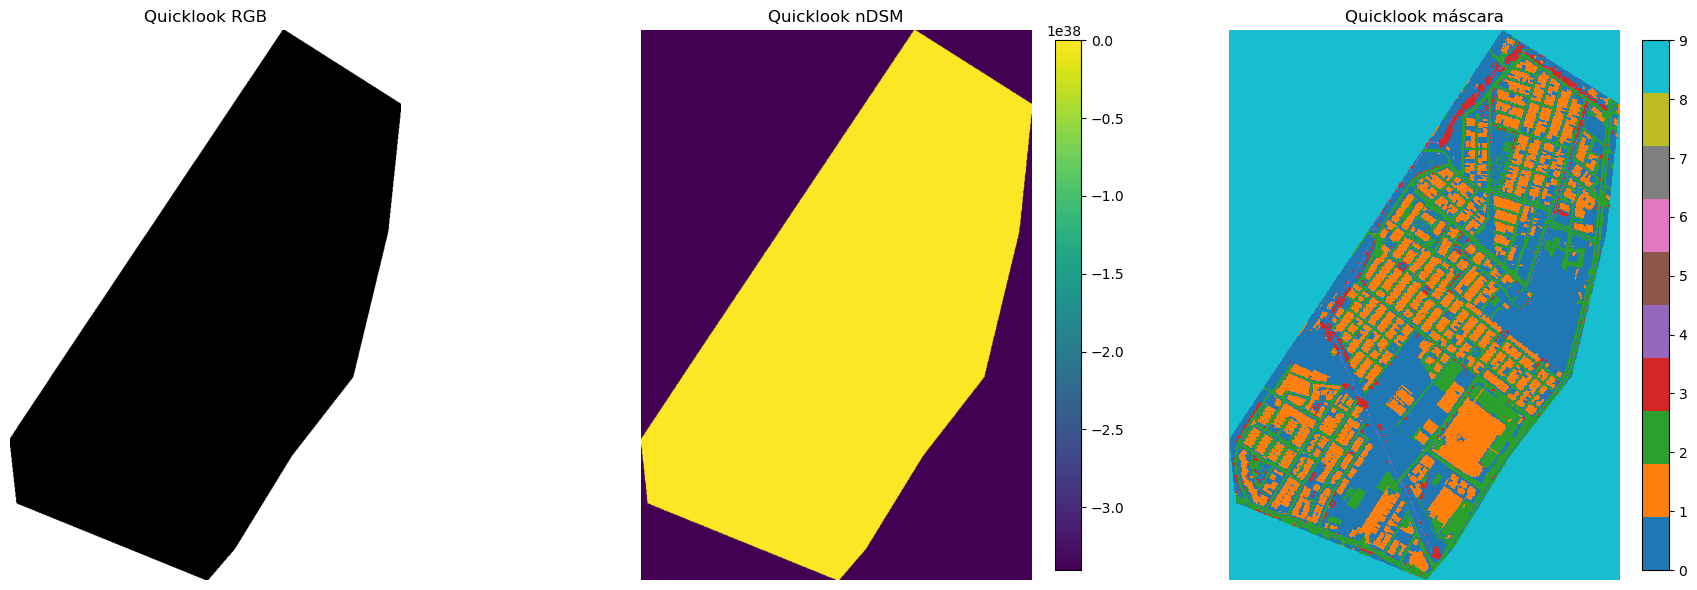

In [6]:

# ============================================================
# 2.3 VISUALIZACIÓN RÁPIDA DE CONTROL (SEGURA EN MEMORIA)
# ============================================================

from rasterio.enums import Resampling
from rasterio.windows import Window

def _read_preview(
    fp: Path,
    indexes,
    max_preview_size: int = 1200,
    window: Window | None = None,
    resampling: Resampling = Resampling.nearest,
):
    """
    Lee una versión reducida del raster para visualización rápida,
    evitando cargar el archivo completo en memoria.
    """
    with rasterio.open(fp) as src:
        if window is None:
            h, w = src.height, src.width
            scale = min(max_preview_size / max(h, w), 1.0)
            out_h = max(1, int(h * scale))
            out_w = max(1, int(w * scale))
            data = src.read(
                indexes,
                out_shape=(len(indexes), out_h, out_w),
                resampling=resampling
            )
        else:
            h, w = int(window.height), int(window.width)
            scale = min(max_preview_size / max(h, w), 1.0)
            out_h = max(1, int(h * scale))
            out_w = max(1, int(w * scale))
            data = src.read(
                indexes,
                window=window,
                out_shape=(len(indexes), out_h, out_w),
                resampling=resampling
            )
    return data

def _build_center_window(fp: Path, frac: float = 0.25) -> Window:
    """
    Construye una ventana central del raster.
    frac=0.25 significa 25% del ancho y 25% del alto.
    """
    with rasterio.open(fp) as src:
        h, w = src.height, src.width
        win_h = max(256, int(h * frac))
        win_w = max(256, int(w * frac))
        row_off = max(0, (h - win_h) // 2)
        col_off = max(0, (w - win_w) // 2)
        return Window(col_off=col_off, row_off=row_off, width=win_w, height=win_h)

def show_quicklook_safe(
    ortho_fp: Path,
    ndsm_fp: Path,
    mask_fp: Path,
    max_preview_size: int = 1200,
    use_center_window: bool = False,
    center_frac: float = 0.25,
) -> None:
    """
    Visualización rápida segura:
    - por defecto muestra todo el raster pero reducido
    - opcionalmente muestra solo una ventana central
    """
    try:
        window = _build_center_window(ortho_fp, frac=center_frac) if use_center_window else None

        ortho = _read_preview(
            ortho_fp,
            indexes=[1, 2, 3],
            max_preview_size=max_preview_size,
            window=window,
            resampling=Resampling.bilinear
        ).astype(np.float32)

        ndsm = _read_preview(
            ndsm_fp,
            indexes=[1],
            max_preview_size=max_preview_size,
            window=window,
            resampling=Resampling.bilinear
        )[0].astype(np.float32)

        mask = _read_preview(
            mask_fp,
            indexes=[1],
            max_preview_size=max_preview_size,
            window=window,
            resampling=Resampling.nearest
        )[0].astype(np.int16)

        # Quicklook solo para auditoría visual; NO para entrenamiento
        rgb = ortho.transpose(1, 2, 0)

        valid_rgb = np.isfinite(rgb)
        if valid_rgb.any():
            p2 = np.percentile(rgb[valid_rgb], 2)
            p98 = np.percentile(rgb[valid_rgb], 98)
            rgb = np.clip(rgb, p2, p98)
            rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        else:
            rgb = np.zeros_like(rgb, dtype=np.float32)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(rgb)
        axes[0].set_title("Quicklook RGB")
        axes[0].axis("off")

        im1 = axes[1].imshow(ndsm, cmap="viridis")
        axes[1].set_title("Quicklook nDSM")
        axes[1].axis("off")
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        im2 = axes[2].imshow(mask, cmap="tab10", interpolation="nearest", vmin=0, vmax=9)
        axes[2].set_title("Quicklook máscara")
        axes[2].axis("off")
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("Falló la visualización rápida.")
        print(f"Detalle: {type(e).__name__}: {e}")
        print("Sugerencia: usa un preview más pequeño o activa use_center_window=True.")

# Opción 1: vista de todo el raster, pero muy reducida
show_quicklook_safe(
    PATHS.ortho_fp,
    PATHS.ndsm_fp,
    PATHS.mask_fp,
    max_preview_size=1000,
    use_center_window=False
)

# Si aún va pesado, usa esta opción:
# show_quicklook_safe(
#     PATHS.ortho_fp,
#     PATHS.ndsm_fp,
#     PATHS.mask_fp,
#     max_preview_size=800,
#     use_center_window=True,
#     center_frac=0.15
# )


## 3) Contrato de entradas y clases

In [7]:

# ============================================================
# 3. CONTRATO DEL PROBLEMA
# ============================================================

CLASS_MAP: Dict[int, str] = {
    0: "fondo",
    1: "construccion",
    2: "pavimento",
    3: "vegetacion",
    4: "agua",
}
IGNORE_INDEX = 255

EXPECTED_ORTHO_BANDS = 4   # RGB + NIR
EXPECTED_NDSM_BANDS = 1
EXPECTED_MASK_BANDS = 1

INPUT_CHANNEL_ORDER = ("R", "G", "B", "NIR", "HEIGHT")
MODEL_INPUT_CHANNELS = len(INPUT_CHANNEL_ORDER)
MODEL_NUM_CLASSES = len(CLASS_MAP)

VALID_MASK_VALUES = set(CLASS_MAP.keys()) | {IGNORE_INDEX}

print("Mapa de clases:", CLASS_MAP)
print("Ignore index:", IGNORE_INDEX)
print("Orden de canales de entrada:", INPUT_CHANNEL_ORDER)
print("Número de canales del modelo:", MODEL_INPUT_CHANNELS)
print("Número de clases del modelo:", MODEL_NUM_CLASSES)


Mapa de clases: {0: 'fondo', 1: 'construccion', 2: 'pavimento', 3: 'vegetacion', 4: 'agua'}
Ignore index: 255
Orden de canales de entrada: ('R', 'G', 'B', 'NIR', 'HEIGHT')
Número de canales del modelo: 5
Número de clases del modelo: 5


In [8]:

# ============================================================
# 3.1 VALIDACIÓN DEL CONTRATO CONTRA LOS INSUMOS REALES
# ============================================================

def validate_problem_contract(
    ortho: Dict,
    ndsm: Dict,
    mask: Dict,
    mask_array: np.ndarray,
) -> None:
    assert ortho["count"] == EXPECTED_ORTHO_BANDS, (
        f"Se esperaban {EXPECTED_ORTHO_BANDS} bandas en la ortofoto y llegaron {ortho['count']}."
    )
    assert ndsm["count"] == EXPECTED_NDSM_BANDS, (
        f"Se esperaban {EXPECTED_NDSM_BANDS} banda en el nDSM y llegaron {ndsm['count']}."
    )
    assert mask["count"] == EXPECTED_MASK_BANDS, (
        f"Se esperaban {EXPECTED_MASK_BANDS} banda en la máscara y llegaron {mask['count']}."
    )

    unique_values = set(np.unique(mask_array).tolist())
    invalid_values = sorted(unique_values - VALID_MASK_VALUES)
    assert not invalid_values, (
        "La máscara contiene valores no permitidos: " + ", ".join(map(str, invalid_values))
    )

    if ortho["dtype"][0] not in ("uint8", "uint16", "float32", "float64"):
        print(f"Advertencia: dtype de ortofoto poco usual para entrenamiento: {ortho['dtype']}")

    if ndsm["dtype"][0] not in ("int16", "int32", "float32", "float64"):
        print(f"Advertencia: dtype de nDSM poco usual para alturas: {ndsm['dtype']}")

validate_problem_contract(ortho_summary, ndsm_summary, mask_summary, mask_array)
print("Contrato de entradas y clases validado correctamente.")


Contrato de entradas y clases validado correctamente.



## 4) Redefinición de normalización

### Política adoptada
- **NO** normalizar altura por tile  
- **SÍ** estimar estadísticas de normalización desde el conjunto de entrenamiento  
- **RGB/NIR**: escalado robusto por banda usando percentiles globales del entrenamiento  
- **HEIGHT**: recorte robusto + estandarización global del entrenamiento  

> En esta fase dejamos implementadas las funciones y estructuras para ajustar la normalización correctamente.
> La **estimación final** se debe ejecutar después de definir el split y los tiles de entrenamiento.


In [9]:

# ============================================================
# 4. PERFIL DE NORMALIZACIÓN
# ============================================================

@dataclass
class NormalizationProfile:
    ortho_low: np.ndarray     # shape: [4]
    ortho_high: np.ndarray    # shape: [4]
    height_low: float
    height_high: float
    height_mean: float
    height_std: float
    ortho_bands: Tuple[int, ...] = (1, 2, 3, 4)
    height_band: int = 1
    lower_q_ortho: float = 2.0
    upper_q_ortho: float = 98.0
    lower_q_height: float = 1.0
    upper_q_height: float = 99.0

    def to_dict(self) -> Dict:
        out = asdict(self)
        out["ortho_low"] = self.ortho_low.tolist()
        out["ortho_high"] = self.ortho_high.tolist()
        return out

def robust_band_quantiles(
    array: np.ndarray,
    lower_q: float,
    upper_q: float,
) -> Tuple[np.ndarray, np.ndarray]:
    '''
    array esperado: [C, H, W] o [C, N]
    '''
    if array.ndim == 3:
        flat = array.reshape(array.shape[0], -1)
    elif array.ndim == 2:
        flat = array
    else:
        raise ValueError("El array debe tener forma [C,H,W] o [C,N].")

    low = np.nanpercentile(flat, lower_q, axis=1).astype(np.float32)
    high = np.nanpercentile(flat, upper_q, axis=1).astype(np.float32)
    high = np.where(high <= low, low + 1e-6, high)
    return low, high

def robust_scalar_stats(
    array: np.ndarray,
    lower_q: float = 1.0,
    upper_q: float = 99.0,
) -> Tuple[float, float, float, float]:
    values = array[np.isfinite(array)].astype(np.float32)
    if values.size == 0:
        raise ValueError("No hay valores finitos para estimar estadísticas del canal de altura.")

    low = float(np.percentile(values, lower_q))
    high = float(np.percentile(values, upper_q))
    clipped = np.clip(values, low, high)

    mean = float(clipped.mean())
    std = float(clipped.std())
    if std < 1e-8:
        std = 1.0

    return low, high, mean, std


In [10]:
# ============================================================
# 4.1 FUNCIONES PARA AJUSTAR Y APLICAR NORMALIZACIÓN (ROBUSTAS)
# ============================================================

def sanitize_height_array(
    height_array: np.ndarray,
    nodata_value: Optional[float] = None,
    hard_valid_min: float = -1000.0,
    hard_valid_max: float = 1000.0,
) -> np.ndarray:
    """
    Limpia el canal de altura:
    - convierte a float32
    - reemplaza nodata por NaN
    - elimina no finitos
    - elimina extremos absurdos
    """
    h = np.asarray(height_array, dtype=np.float32).copy()

    if nodata_value is not None:
        h[h == np.float32(nodata_value)] = np.nan

    h[~np.isfinite(h)] = np.nan
    h[(h < hard_valid_min) | (h > hard_valid_max)] = np.nan
    return h


def fit_normalization_profile_from_arrays(
    ortho_stack: np.ndarray,   # [4, H, W] o [4, N]
    height_array: np.ndarray,  # [H, W] o [N]
    lower_q_ortho: float = 2.0,
    upper_q_ortho: float = 98.0,
    lower_q_height: float = 1.0,
    upper_q_height: float = 99.0,
) -> NormalizationProfile:
    ortho_low, ortho_high = robust_band_quantiles(
        ortho_stack,
        lower_q=lower_q_ortho,
        upper_q=upper_q_ortho,
    )

    h_low, h_high, h_mean, h_std = robust_scalar_stats(
        height_array,
        lower_q=lower_q_height,
        upper_q=upper_q_height,
    )

    profile = NormalizationProfile(
        ortho_low=ortho_low,
        ortho_high=ortho_high,
        height_low=h_low,
        height_high=h_high,
        height_mean=h_mean,
        height_std=h_std,
        lower_q_ortho=lower_q_ortho,
        upper_q_ortho=upper_q_ortho,
        lower_q_height=lower_q_height,
        upper_q_height=upper_q_height,
    )

    # validación fuerte
    if not np.all(np.isfinite(profile.ortho_low)):
        raise ValueError("ortho_low contiene valores no finitos.")
    if not np.all(np.isfinite(profile.ortho_high)):
        raise ValueError("ortho_high contiene valores no finitos.")
    if not np.isfinite(profile.height_low):
        raise ValueError("height_low no es finito.")
    if not np.isfinite(profile.height_high):
        raise ValueError("height_high no es finito.")
    if not np.isfinite(profile.height_mean):
        raise ValueError("height_mean no es finito.")
    if not np.isfinite(profile.height_std):
        raise ValueError("height_std no es finito.")
    if profile.height_std < 1e-8:
        raise ValueError("height_std es demasiado pequeño o inválido.")

    return profile


def normalize_ortho(ortho_4ch: np.ndarray, profile: NormalizationProfile) -> np.ndarray:
    ortho = np.asarray(ortho_4ch, dtype=np.float32).copy()

    for ch in range(ortho.shape[0]):
        low = float(profile.ortho_low[ch])
        high = float(profile.ortho_high[ch])
        denom = max(high - low, 1e-8)

        ortho[ch] = np.clip(ortho[ch], low, high)
        ortho[ch] = (ortho[ch] - low) / denom

    ortho[~np.isfinite(ortho)] = 0.0
    return ortho.astype(np.float32)


def normalize_height(height_2d: np.ndarray, profile: NormalizationProfile) -> np.ndarray:
    h = sanitize_height_array(height_2d)

    # si quedan NaN, se recortan después y se rellenan al final
    h = np.clip(h, profile.height_low, profile.height_high)

    denom = float(profile.height_std) + 1e-8
    if (not np.isfinite(denom)) or denom <= 0:
        raise ValueError(
            f"height_std inválido en profile: {profile.height_std}"
        )

    h = (h - float(profile.height_mean)) / denom

    # sustituir NaN residuales por 0.0 (altura normalizada neutra)
    h[~np.isfinite(h)] = 0.0
    return h.astype(np.float32)


def normalize_multisource_sample(
    ortho_4ch: np.ndarray,
    height_2d: np.ndarray,
    profile: NormalizationProfile,
) -> np.ndarray:
    ortho_norm = normalize_ortho(ortho_4ch, profile)
    height_norm = normalize_height(height_2d, profile)[None, ...]
    x = np.concatenate([ortho_norm, height_norm], axis=0).astype(np.float32)

    if not np.all(np.isfinite(x)):
        raise ValueError("La muestra multifuente normalizada contiene NaN o Inf.")

    return x

In [11]:

# ============================================================
# 4.2 DIAGNÓSTICO PRELIMINAR DE DISTRIBUCIONES
#     (NO reemplaza el ajuste final con train tiles)
# ============================================================

from rasterio.enums import Resampling
from dataclasses import dataclass, asdict

@dataclass
class NormalizationProfile:
    ortho_low: np.ndarray
    ortho_high: np.ndarray
    height_low: float
    height_high: float
    height_mean: float
    height_std: float
    ortho_bands: Tuple[int, ...] = (1, 2, 3, 4)
    height_band: int = 1
    lower_q_ortho: float = 2.0
    upper_q_ortho: float = 98.0
    lower_q_height: float = 1.0
    upper_q_height: float = 99.0

    def to_dict(self) -> Dict:
        out = asdict(self)
        out["ortho_low"] = self.ortho_low.tolist()
        out["ortho_high"] = self.ortho_high.tolist()
        return out

def preview_global_normalization_profile(
    ortho_fp: Path,
    ndsm_fp: Path,
    max_preview_size: int = 1024,
    step: int = 8,
    hard_valid_height_min: float = -1000.0,
    hard_valid_height_max: float = 1000.0,
) -> NormalizationProfile:
    """
    Diagnóstico preliminar seguro:
    - usa previews reducidos
    - filtra nodata/extremos
    - evita overflow en altura
    """

    # --------------------------------------------------------
    # ORTOFOTO: preview reducido
    # --------------------------------------------------------
    with rasterio.open(ortho_fp) as src_o:
        h, w = src_o.height, src_o.width
        scale = min(max_preview_size / max(h, w), 1.0)
        out_h = max(1, int(h * scale))
        out_w = max(1, int(w * scale))

        ortho = src_o.read(
            [1, 2, 3, 4],
            out_shape=(4, out_h, out_w),
            resampling=Resampling.nearest,
            masked=True
        )

    ortho = ortho[:, ::step, ::step]

    ortho_low = []
    ortho_high = []

    for b in range(ortho.shape[0]):
        band = ortho[b]

        if np.ma.isMaskedArray(band):
            vals = band.compressed().astype(np.float64)
        else:
            vals = band[np.isfinite(band)].astype(np.float64)

        if vals.size == 0:
            ortho_low.append(0.0)
            ortho_high.append(1.0)
        else:
            ortho_low.append(float(np.percentile(vals, 2)))
            ortho_high.append(float(np.percentile(vals, 98)))

    ortho_low = np.array(ortho_low, dtype=np.float64)
    ortho_high = np.array(ortho_high, dtype=np.float64)

    # --------------------------------------------------------
    # NDSM: preview reducido y MUY robusto
    # --------------------------------------------------------
    with rasterio.open(ndsm_fp) as src_n:
        h, w = src_n.height, src_n.width
        scale = min(max_preview_size / max(h, w), 1.0)
        out_h = max(1, int(h * scale))
        out_w = max(1, int(w * scale))

        # OJO: nearest, no bilinear, para no mezclar nodata extremo
        ndsm = src_n.read(
            1,
            out_shape=(out_h, out_w),
            resampling=Resampling.nearest,
            masked=True
        )

        ndsm_nodata = src_n.nodata

    ndsm = ndsm[::step, ::step]

    if np.ma.isMaskedArray(ndsm):
        vals = ndsm.compressed().astype(np.float64)
    else:
        vals = ndsm[np.isfinite(ndsm)].astype(np.float64)

    # Filtro extra por seguridad contra nodata extremos no enmascarados
    vals = vals[np.isfinite(vals)]
    vals = vals[(vals > hard_valid_height_min) & (vals < hard_valid_height_max)]

    if ndsm_nodata is not None:
        vals = vals[vals != ndsm_nodata]

    if vals.size == 0:
        raise ValueError(
            "No quedaron valores válidos de nDSM tras filtrar nodata/extremos. "
            "Revisa el raster de altura y su valor nodata."
        )

    height_low = float(np.percentile(vals, 1))
    height_high = float(np.percentile(vals, 99))

    vals_clipped = np.clip(vals, height_low, height_high).astype(np.float64)

    height_mean = float(vals_clipped.mean())
    height_std = float(vals_clipped.std() + 1e-8)

    return NormalizationProfile(
        ortho_low=ortho_low,
        ortho_high=ortho_high,
        height_low=height_low,
        height_high=height_high,
        height_mean=height_mean,
        height_std=height_std,
    )

preview_profile = preview_global_normalization_profile(
    PATHS.ortho_fp,
    PATHS.ndsm_fp,
    max_preview_size=1024,
    step=8,
    hard_valid_height_min=-1000.0,
    hard_valid_height_max=1000.0,
)

print("Perfil preliminar de normalización:")
print(preview_profile.to_dict())

Perfil preliminar de normalización:
{'ortho_low': [3.0, 9.100000000000009, 20.0, 71.0], 'ortho_high': [233.0, 236.0, 239.0, 238.0], 'height_low': 0.0, 'height_high': 28.4707935333252, 'height_mean': 3.2767005373210076, 'height_std': 5.342599860411585, 'ortho_bands': (1, 2, 3, 4), 'height_band': 1, 'lower_q_ortho': 2.0, 'upper_q_ortho': 98.0, 'lower_q_height': 1.0, 'upper_q_height': 99.0}


In [12]:

# ============================================================
# 4.3 PRUEBA DE APLICACIÓN DE NORMALIZACIÓN SOBRE UNA VISTA RÁPIDA
#     (SEGURO EN MEMORIA)
# ============================================================

from rasterio.enums import Resampling
from rasterio.windows import Window

def build_center_window_from_src(src, frac: float = 0.15) -> Window:
    h, w = src.height, src.width
    win_h = max(256, int(h * frac))
    win_w = max(256, int(w * frac))
    row_off = max(0, (h - win_h) // 2)
    col_off = max(0, (w - win_w) // 2)
    return Window(col_off=col_off, row_off=row_off, width=win_w, height=win_h)

def read_preview_for_normalization(
    ortho_fp: Path,
    ndsm_fp: Path,
    max_preview_size: int = 1024,
    use_center_window: bool = True,
    center_frac: float = 0.15,
):
    with rasterio.open(ortho_fp) as src_o:
        window = build_center_window_from_src(src_o, frac=center_frac) if use_center_window else None

        if window is None:
            h, w = src_o.height, src_o.width
        else:
            h, w = int(window.height), int(window.width)

        scale = min(max_preview_size / max(h, w), 1.0)
        out_h = max(1, int(h * scale))
        out_w = max(1, int(w * scale))

        ortho = src_o.read(
            [1, 2, 3, 4],
            window=window,
            out_shape=(4, out_h, out_w),
            resampling=Resampling.nearest,
            masked=True
        )

    with rasterio.open(ndsm_fp) as src_n:
        if window is None:
            h, w = src_n.height, src_n.width
        else:
            h, w = int(window.height), int(window.width)

        scale = min(max_preview_size / max(h, w), 1.0)
        out_h = max(1, int(h * scale))
        out_w = max(1, int(w * scale))

        ndsm = src_n.read(
            1,
            window=window,
            out_shape=(out_h, out_w),
            resampling=Resampling.nearest,
            masked=True
        )

        ndsm_nodata = src_n.nodata

    # Convertir a arrays normales, rellenando con NaN para conservar invalidos
    ortho = ortho.astype(np.float32).filled(np.nan)
    ndsm = ndsm.astype(np.float32).filled(np.nan)

    if ndsm_nodata is not None:
        ndsm[ndsm == ndsm_nodata] = np.nan

    # Filtro duro contra valores absurdos de altura
    ndsm[(ndsm < -1000.0) | (ndsm > 1000.0)] = np.nan

    return ortho, ndsm

ortho_preview, ndsm_preview = read_preview_for_normalization(
    PATHS.ortho_fp,
    PATHS.ndsm_fp,
    max_preview_size=800,
    use_center_window=True,
    center_frac=0.10,
)

x_preview = normalize_multisource_sample(ortho_preview, ndsm_preview, preview_profile)

print("Shape de la entrada normalizada:", x_preview.shape)
print("Canales esperados:", INPUT_CHANNEL_ORDER)
print("Rango aproximado RGB/NIR normalizado:")

for i, ch in enumerate(INPUT_CHANNEL_ORDER[:4]):
    vals = x_preview[i]
    valid = np.isfinite(vals)
    if valid.any():
        print(f"  {ch}: min={vals[valid].min():.4f}, max={vals[valid].max():.4f}")
    else:
        print(f"  {ch}: sin valores válidos")

hvals = x_preview[4]
hvalid = np.isfinite(hvals)
if hvalid.any():
    print(
        f"HEIGHT normalizada: min={hvals[hvalid].min():.4f}, "
        f"max={hvals[hvalid].max():.4f}, "
        f"mean={hvals[hvalid].mean():.4f}, "
        f"std={hvals[hvalid].std():.4f}"
    )
else:
    print("HEIGHT normalizada: sin valores válidos")


Shape de la entrada normalizada: (5, 800, 568)
Canales esperados: ('R', 'G', 'B', 'NIR', 'HEIGHT')
Rango aproximado RGB/NIR normalizado:
  R: min=0.0000, max=1.0000
  G: min=0.0000, max=1.0000
  B: min=0.0000, max=1.0000
  NIR: min=0.0000, max=1.0000
HEIGHT normalizada: min=-0.6133, max=1.2141, mean=0.0474, std=0.4817


## 5) Split espacial definitivo

In [13]:
# ============================================================
# 5. CONFIGURACIÓN DEL SPLIT ESPACIAL DEFINITIVO
# ============================================================

@dataclass(frozen=True)
class TileConfig:
    tile_size: int = 256
    stride: int = 256
    drop_incomplete: bool = True

@dataclass(frozen=True)
class SpatialSplitConfig:
    axis: str = "x"              # "x" = franjas verticales; "y" = franjas horizontales
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15
    gap_px: int = 0              # opcional: zona colchón entre splits para reducir fuga espacial

    def validate(self) -> None:
        assert self.axis in {"x", "y"}, "axis debe ser 'x' o 'y'."
        total = self.train_frac + self.val_frac + self.test_frac
        assert abs(total - 1.0) < 1e-8, "Las fracciones train/val/test deben sumar 1.0."
        assert self.gap_px >= 0, "gap_px no puede ser negativo."

TILE_CFG = TileConfig(tile_size=256, stride=256, drop_incomplete=True)
SPLIT_CFG = SpatialSplitConfig(axis="x", train_frac=0.70, val_frac=0.15, test_frac=0.15, gap_px=0)

SPLIT_CFG.validate()

print("Configuración de tiles:", TILE_CFG)
print("Configuración de split:", SPLIT_CFG)

Configuración de tiles: TileConfig(tile_size=256, stride=256, drop_incomplete=True)
Configuración de split: SpatialSplitConfig(axis='x', train_frac=0.7, val_frac=0.15, test_frac=0.15, gap_px=0)


In [14]:
# ============================================================
# 5.1 GENERACIÓN BASE DE TILES Y ASIGNACIÓN DE SPLIT
# ============================================================

def generate_tiles(height: int, width: int, tile_size: int = 256, stride: int = 256, drop_incomplete: bool = True) -> List[Tile]:
    tiles: List[Tile] = []

    max_r = height - tile_size if drop_incomplete else height - 1
    max_c = width - tile_size if drop_incomplete else width - 1

    for r0 in range(0, max_r + 1, stride):
        for c0 in range(0, max_c + 1, stride):
            h = tile_size
            w = tile_size

            if not drop_incomplete:
                h = min(tile_size, height - r0)
                w = min(tile_size, width - c0)

            if h > 0 and w > 0:
                tiles.append((r0, c0, h, w))

    return tiles

def tile_center(tile: Tile) -> Tuple[float, float]:
    r0, c0, h, w = tile
    return (r0 + h / 2.0, c0 + w / 2.0)

def assign_spatial_split(tile: Tile, raster_height: int, raster_width: int, cfg: SpatialSplitConfig) -> str:
    r_center, c_center = tile_center(tile)

    if cfg.axis == "x":
        coord = c_center
        total = raster_width
    else:
        coord = r_center
        total = raster_height

    train_end = cfg.train_frac * total
    val_end = (cfg.train_frac + cfg.val_frac) * total

    # zonas colchón opcionales
    train_gap_end = train_end - cfg.gap_px / 2.0
    val_gap_start = train_end + cfg.gap_px / 2.0
    val_gap_end = val_end - cfg.gap_px / 2.0
    test_gap_start = val_end + cfg.gap_px / 2.0

    if coord < train_gap_end:
        return "train"
    elif val_gap_start <= coord < val_gap_end:
        return "val"
    elif coord >= test_gap_start:
        return "test"
    else:
        return "discard"

with rasterio.open(PATHS.ortho_fp) as src:
    RASTER_HEIGHT, RASTER_WIDTH = src.height, src.width

all_tiles = generate_tiles(
    height=RASTER_HEIGHT,
    width=RASTER_WIDTH,
    tile_size=TILE_CFG.tile_size,
    stride=TILE_CFG.stride,
    drop_incomplete=TILE_CFG.drop_incomplete,
)

tile_split_map: Dict[Tile, str] = {
    tile: assign_spatial_split(tile, RASTER_HEIGHT, RASTER_WIDTH, SPLIT_CFG)
    for tile in all_tiles
}

tiles_train_raw = [t for t in all_tiles if tile_split_map[t] == "train"]
tiles_val_raw   = [t for t in all_tiles if tile_split_map[t] == "val"]
tiles_test_raw  = [t for t in all_tiles if tile_split_map[t] == "test"]
tiles_discarded = [t for t in all_tiles if tile_split_map[t] == "discard"]

print(f"Tiles totales generados      : {len(all_tiles):,}")
print(f"Tiles train (pre-filtro)     : {len(tiles_train_raw):,}")
print(f"Tiles val   (pre-filtro)     : {len(tiles_val_raw):,}")
print(f"Tiles test  (pre-filtro)     : {len(tiles_test_raw):,}")
print(f"Tiles descartados por gap    : {len(tiles_discarded):,}")

Tiles totales generados      : 8,132
Tiles train (pre-filtro)     : 5,778
Tiles val   (pre-filtro)     : 1,177
Tiles test  (pre-filtro)     : 1,177
Tiles descartados por gap    : 0


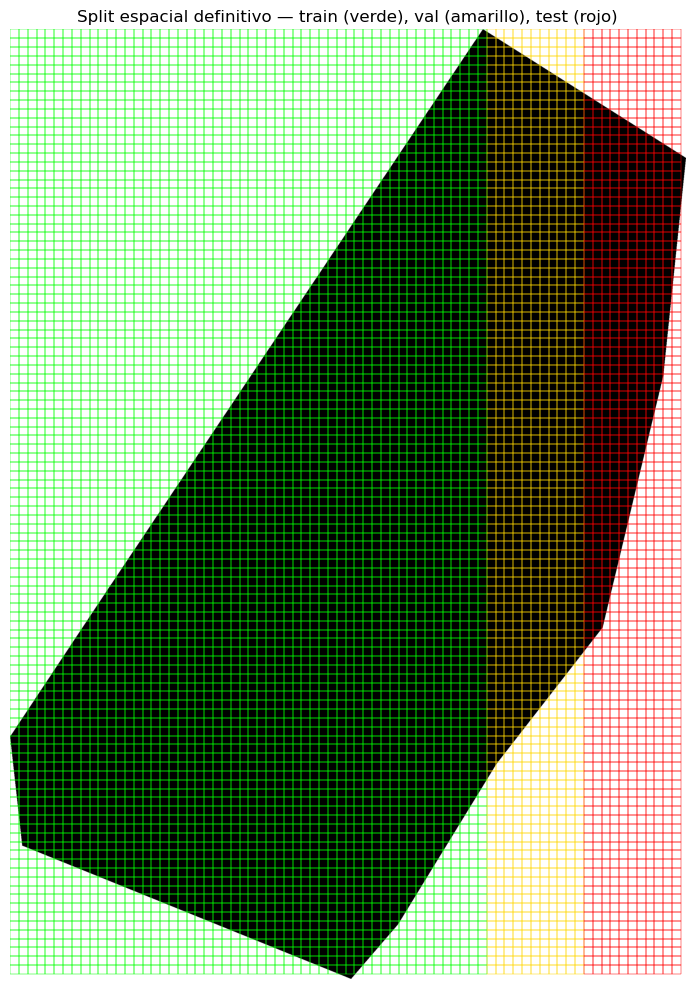

In [15]:
# ============================================================
# 5.2 VISUALIZACIÓN DEL SPLIT ESPACIAL
# ============================================================

def build_rgb_quicklook_for_split(ortho_fp: Path, step: int = 8) -> np.ndarray:
    with rasterio.open(ortho_fp) as src:
        rgb = src.read([1, 2, 3]).astype(np.float32)[:, ::step, ::step]

    rgb = rgb.transpose(1, 2, 0)
    lo = np.percentile(rgb, 2)
    hi = np.percentile(rgb, 98)
    rgb = np.clip(rgb, lo, hi)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return rgb

def show_spatial_split_overlay(
    ortho_fp: Path,
    tiles_train: Sequence[Tile],
    tiles_val: Sequence[Tile],
    tiles_test: Sequence[Tile],
    step: int = 8,
) -> None:
    rgb_vis = build_rgb_quicklook_for_split(ortho_fp, step=step)

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(rgb_vis)

    def add_rectangles(tiles: Sequence[Tile], color: str, linewidth: float = 0.35):
        for r0, c0, h, w in tiles:
            rect = plt.Rectangle(
                (c0 / step, r0 / step),
                w / step,
                h / step,
                fill=False,
                edgecolor=color,
                linewidth=linewidth,
            )
            ax.add_patch(rect)

    add_rectangles(tiles_train, color="lime")
    add_rectangles(tiles_val, color="gold")
    add_rectangles(tiles_test, color="red")

    ax.set_title("Split espacial definitivo — train (verde), val (amarillo), test (rojo)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

show_spatial_split_overlay(
    PATHS.ortho_fp,
    tiles_train_raw,
    tiles_val_raw,
    tiles_test_raw,
    step=8,
)

## 6) Generación y filtrado de tiles

In [16]:
# ============================================================
# 6. CONFIGURACIÓN DEL FILTRADO DE TILES
# ============================================================

@dataclass(frozen=True)
class TileFilterConfig:
    ignore_index: int = IGNORE_INDEX
    min_valid_fraction: float = 0.10     # fracción mínima de píxeles distintos de ignore
    min_valid_pixels: int = 256          # seguridad adicional: al menos una franja útil
    min_labeled_classes: int = 1         # cuántas clases reales (0..4) deben estar presentes
    allow_background_only: bool = True   # si False, exige al menos una clase distinta de fondo
    require_finite_height: bool = True   # descarta tiles con altura no finita
    max_invalid_height_fraction: float = 0.05

FILTER_CFG = TileFilterConfig()

print("Configuración de filtrado:", FILTER_CFG)

Configuración de filtrado: TileFilterConfig(ignore_index=255, min_valid_fraction=0.1, min_valid_pixels=256, min_labeled_classes=1, allow_background_only=True, require_finite_height=True, max_invalid_height_fraction=0.05)


In [17]:
# ============================================================
# 6.1 METADATOS POR TILE
# ============================================================

def summarize_tile(
    tile: Tile,
    mask_fp: Path,
    ndsm_fp: Path,
    class_map: Dict[int, str],
    ignore_index: int = IGNORE_INDEX,
) -> Dict:
    mask_tile = read_window_singleband(mask_fp, tile, band=1).astype(np.int32)
    ndsm_tile = read_window_singleband(ndsm_fp, tile, band=1).astype(np.float32)

    total_pixels = mask_tile.size
    valid_mask = (mask_tile != ignore_index)
    valid_pixels = int(valid_mask.sum())
    valid_fraction = valid_pixels / float(total_pixels)

    if valid_pixels > 0:
        valid_values = mask_tile[valid_mask]
        classes_present, counts_present = np.unique(valid_values, return_counts=True)
        class_counts = {int(c): int(n) for c, n in zip(classes_present, counts_present)}
    else:
        class_counts = {}

    labeled_classes_present = sorted(class_counts.keys())
    non_background_classes = [c for c in labeled_classes_present if c != 0]

    finite_height = np.isfinite(ndsm_tile)
    invalid_height_fraction = 1.0 - float(finite_height.sum()) / float(ndsm_tile.size)

    return {
        "tile": tile,
        "r0": tile[0],
        "c0": tile[1],
        "h": tile[2],
        "w": tile[3],
        "total_pixels": total_pixels,
        "valid_pixels": valid_pixels,
        "valid_fraction": valid_fraction,
        "class_counts": class_counts,
        "classes_present": labeled_classes_present,
        "num_labeled_classes": len(labeled_classes_present),
        "has_non_background": len(non_background_classes) > 0,
        "invalid_height_fraction": invalid_height_fraction,
    }

def tile_passes_filter(meta: Dict, cfg: TileFilterConfig) -> bool:
    if meta["valid_pixels"] < cfg.min_valid_pixels:
        return False
    if meta["valid_fraction"] < cfg.min_valid_fraction:
        return False
    if meta["num_labeled_classes"] < cfg.min_labeled_classes:
        return False
    if not cfg.allow_background_only and not meta["has_non_background"]:
        return False
    if cfg.require_finite_height and meta["invalid_height_fraction"] > cfg.max_invalid_height_fraction:
        return False
    return True

def build_tile_metadata_catalog(
    tiles: Sequence[Tile],
    mask_fp: Path,
    ndsm_fp: Path,
    class_map: Dict[int, str],
    cfg: TileFilterConfig,
) -> List[Dict]:
    catalog: List[Dict] = []
    for tile in tiles:
        meta = summarize_tile(
            tile=tile,
            mask_fp=mask_fp,
            ndsm_fp=ndsm_fp,
            class_map=class_map,
            ignore_index=cfg.ignore_index,
        )
        meta["keep"] = tile_passes_filter(meta, cfg)
        catalog.append(meta)
    return catalog

In [18]:
# ============================================================
# 6.2 APLICAR FILTRADO A TRAIN / VAL / TEST
# ============================================================

train_catalog = build_tile_metadata_catalog(
    tiles_train_raw, PATHS.mask_fp, PATHS.ndsm_fp, CLASS_MAP, FILTER_CFG
)
val_catalog = build_tile_metadata_catalog(
    tiles_val_raw, PATHS.mask_fp, PATHS.ndsm_fp, CLASS_MAP, FILTER_CFG
)
test_catalog = build_tile_metadata_catalog(
    tiles_test_raw, PATHS.mask_fp, PATHS.ndsm_fp, CLASS_MAP, FILTER_CFG
)

tiles_train = [m["tile"] for m in train_catalog if m["keep"]]
tiles_val   = [m["tile"] for m in val_catalog if m["keep"]]
tiles_test  = [m["tile"] for m in test_catalog if m["keep"]]

print("Después del filtrado:")
print(f"  Tiles train: {len(tiles_train):,} / {len(tiles_train_raw):,}")
print(f"  Tiles val  : {len(tiles_val):,} / {len(tiles_val_raw):,}")
print(f"  Tiles test : {len(tiles_test):,} / {len(tiles_test_raw):,}")

Después del filtrado:
  Tiles train: 3,259 / 5,778
  Tiles val  : 823 / 1,177
  Tiles test : 479 / 1,177


In [19]:
# ============================================================
# 6.3 REPORTE DE CALIDAD DEL FILTRADO
# ============================================================

def summarize_catalog(catalog: Sequence[Dict], split_name: str) -> None:
    n_total = len(catalog)
    n_keep = sum(int(m["keep"]) for m in catalog)
    n_drop = n_total - n_keep

    valid_fracs = np.array([m["valid_fraction"] for m in catalog], dtype=np.float32)
    nclasses = np.array([m["num_labeled_classes"] for m in catalog], dtype=np.int32)

    print(f"\n=== Resumen split: {split_name} ===")
    print(f"Tiles totales        : {n_total:,}")
    print(f"Tiles conservados    : {n_keep:,}")
    print(f"Tiles descartados    : {n_drop:,}")
    if n_total > 0:
        print(f"Valid fraction — min : {valid_fracs.min():.4f}")
        print(f"Valid fraction — p50 : {np.percentile(valid_fracs, 50):.4f}")
        print(f"Valid fraction — p95 : {np.percentile(valid_fracs, 95):.4f}")
        print(f"Número de clases — p50: {np.percentile(nclasses, 50):.2f}")
        print(f"Número de clases — max: {nclasses.max()}")

def aggregate_class_pixels(catalog: Sequence[Dict]) -> Dict[int, int]:
    totals = {c: 0 for c in CLASS_MAP.keys()}
    for meta in catalog:
        if not meta["keep"]:
            continue
        for c, n in meta["class_counts"].items():
            if c in totals:
                totals[c] += int(n)
    return totals

summarize_catalog(train_catalog, "train")
summarize_catalog(val_catalog, "val")
summarize_catalog(test_catalog, "test")

print("\nDistribución agregada de píxeles válidos por clase (post-filtro):")
for split_name, catalog in [("train", train_catalog), ("val", val_catalog), ("test", test_catalog)]:
    totals = aggregate_class_pixels(catalog)
    total_valid = sum(totals.values())
    print(f"\n{split_name.upper()}:")
    for c, class_name in CLASS_MAP.items():
        frac = (totals[c] / total_valid) if total_valid > 0 else 0.0
        print(f"  Clase {c} ({class_name}): {totals[c]:,} píxeles ({frac:.2%})")


=== Resumen split: train ===
Tiles totales        : 5,778
Tiles conservados    : 3,259
Tiles descartados    : 2,519
Valid fraction — min : 0.0000
Valid fraction — p50 : 1.0000
Valid fraction — p95 : 1.0000
Número de clases — p50: 1.00
Número de clases — max: 5

=== Resumen split: val ===
Tiles totales        : 1,177
Tiles conservados    : 823
Tiles descartados    : 354
Valid fraction — min : 0.0000
Valid fraction — p50 : 1.0000
Valid fraction — p95 : 1.0000
Número de clases — p50: 2.00
Número de clases — max: 5

=== Resumen split: test ===
Tiles totales        : 1,177
Tiles conservados    : 479
Tiles descartados    : 698
Valid fraction — min : 0.0000
Valid fraction — p50 : 0.0000
Valid fraction — p95 : 1.0000
Número de clases — p50: 0.00
Número de clases — max: 5

Distribución agregada de píxeles válidos por clase (post-filtro):

TRAIN:
  Clase 0 (fondo): 84,642,754 píxeles (40.44%)
  Clase 1 (construccion): 69,857,579 píxeles (33.38%)
  Clase 2 (pavimento): 48,002,596 píxeles (22.94%

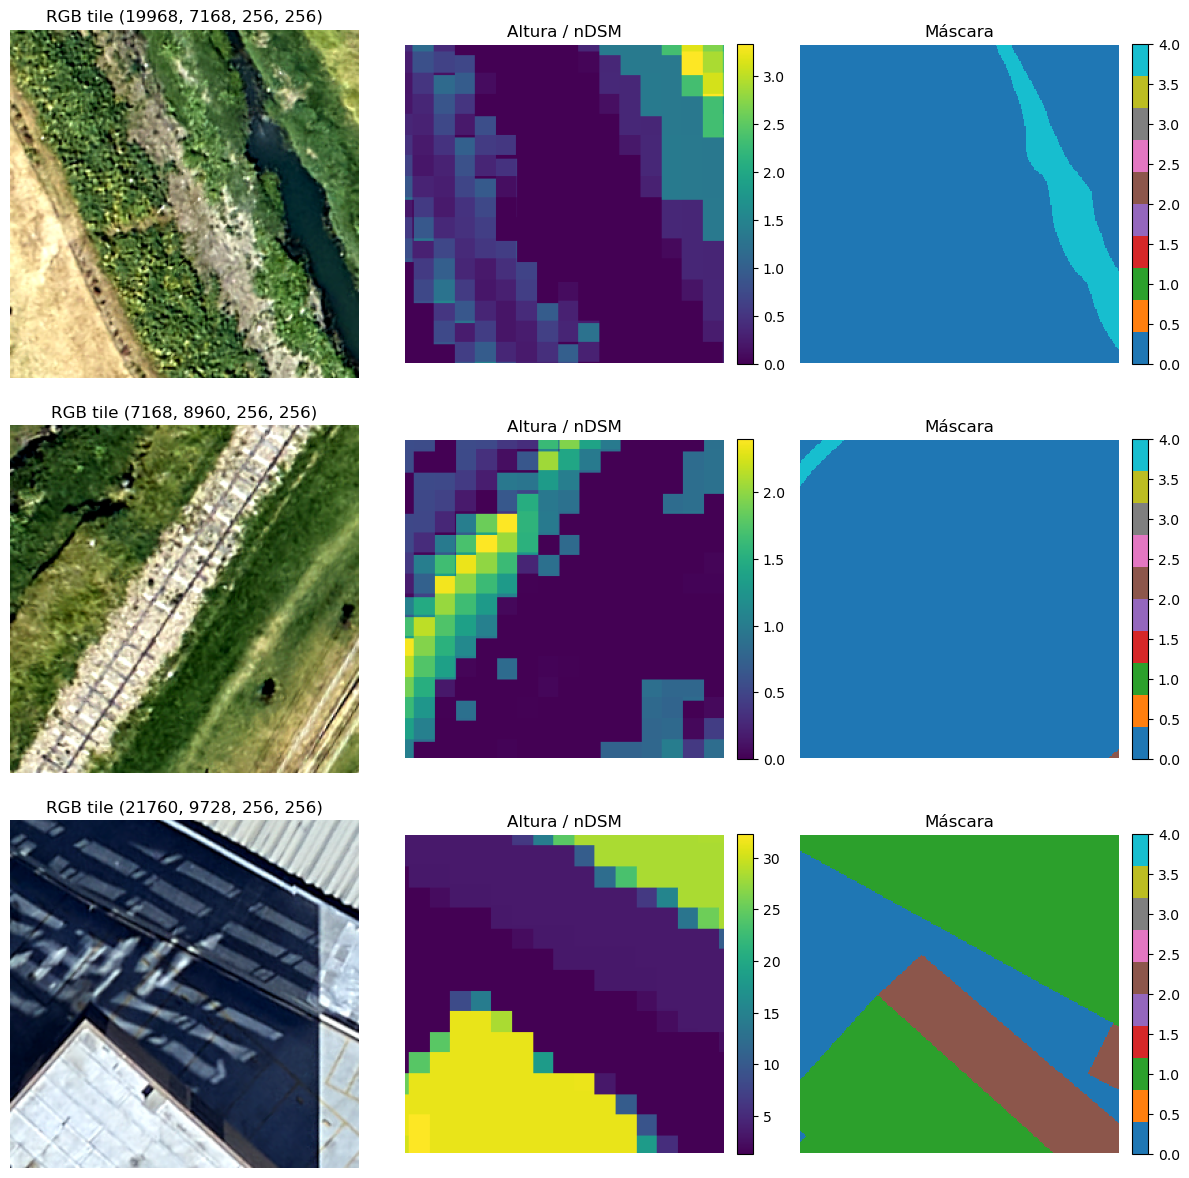

In [20]:
# ============================================================
# 6.4 MUESTRAS DE TILES CONSERVADOS PARA CONTROL VISUAL
# ============================================================

def normalize_rgb_for_display(rgb_3ch: np.ndarray) -> np.ndarray:
    x = rgb_3ch.transpose(1, 2, 0).astype(np.float32)
    lo = np.percentile(x, 2)
    hi = np.percentile(x, 98)
    x = np.clip(x, lo, hi)
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return x

def show_tile_examples(
    ortho_fp: Path,
    ndsm_fp: Path,
    mask_fp: Path,
    tiles: Sequence[Tile],
    n_examples: int = 3,
    seed: int = 42,
) -> None:
    if len(tiles) == 0:
        print("No hay tiles para visualizar.")
        return

    rng = np.random.default_rng(seed)
    selected_idx = rng.choice(len(tiles), size=min(n_examples, len(tiles)), replace=False)

    fig, axes = plt.subplots(len(selected_idx), 3, figsize=(12, 4 * len(selected_idx)))
    if len(selected_idx) == 1:
        axes = np.array([axes])

    for row, idx in enumerate(selected_idx):
        tile = tiles[int(idx)]

        ortho_tile = read_window_multiband(ortho_fp, tile, bands=[1, 2, 3]).astype(np.float32)
        ndsm_tile = read_window_singleband(ndsm_fp, tile, band=1).astype(np.float32)
        mask_tile = read_window_singleband(mask_fp, tile, band=1).astype(np.int32)

        axes[row, 0].imshow(normalize_rgb_for_display(ortho_tile))
        axes[row, 0].set_title(f"RGB tile {tile}")
        axes[row, 0].axis("off")

        im1 = axes[row, 1].imshow(ndsm_tile, cmap="viridis")
        axes[row, 1].set_title("Altura / nDSM")
        axes[row, 1].axis("off")
        plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

        im2 = axes[row, 2].imshow(mask_tile, cmap="tab10", interpolation="nearest", vmin=0, vmax=max(CLASS_MAP))
        axes[row, 2].set_title("Máscara")
        axes[row, 2].axis("off")
        plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

show_tile_examples(PATHS.ortho_fp, PATHS.ndsm_fp, PATHS.mask_fp, tiles_train, n_examples=3, seed=SEED)

## 7) Estrategia de balance de clases

En esta fase **no se modifica** `val` ni `test`; el balance se define **solo para entrenamiento**.

La estrategia queda preparada en dos capas complementarias:

1. **Pesos por clase** para la pérdida, derivados de la distribución real de píxeles en `train`.
2. **Pesos por tile** para muestreo, favoreciendo:
   - tiles con clases raras
   - tiles más diversos
   - tiles con presencia útil de vegetación y agua

**Salidas clave de esta fase:**
- `LOSS_CLASS_WEIGHTS`
- `TRAIN_SAMPLER_WEIGHTS`
- `train_balance_catalog`
- diagnósticos de distribución cruda vs distribución balanceada esperada


In [21]:
# ============================================================
# 7. CONFIGURACIÓN DE BALANCE DE CLASES
# ============================================================

@dataclass(frozen=True)
class ClassBalanceConfig:
    # pesos para la loss
    loss_beta: float = 0.999
    loss_min_weight: float = 0.25
    loss_max_weight: float = 8.00

    # pesos para muestreo por tile
    sampler_power: float = 0.50
    diversity_bonus: float = 0.20
    background_only_penalty: float = 0.85
    min_sampling_weight: float = 0.10
    max_sampling_weight: float = 12.0

    # prioridad explícita a clases raras / difíciles
    priority_boosts: Tuple[Tuple[int, float], ...] = (
        (3, 2.0),   # vegetación
        (4, 4.0),   # agua
    )

BALANCE_CFG = ClassBalanceConfig()
print("Configuración de balance:", BALANCE_CFG)


Configuración de balance: ClassBalanceConfig(loss_beta=0.999, loss_min_weight=0.25, loss_max_weight=8.0, sampler_power=0.5, diversity_bonus=0.2, background_only_penalty=0.85, min_sampling_weight=0.1, max_sampling_weight=12.0, priority_boosts=((3, 2.0), (4, 4.0)))


In [22]:
# ============================================================
# 7.1 CÁLCULO DE PESOS POR CLASE Y PESOS POR TILE
# ============================================================

def kept_catalog_only(catalog: Sequence[Dict]) -> List[Dict]:
    return [dict(meta) for meta in catalog if meta.get("keep", False)]

def class_pixel_totals(catalog: Sequence[Dict], class_map: Dict[int, str]) -> Dict[int, int]:
    totals = {c: 0 for c in class_map.keys()}
    for meta in catalog:
        for c, n in meta["class_counts"].items():
            if c in totals:
                totals[c] += int(n)
    return totals

def normalize_dict_values(d: Dict[int, float]) -> Dict[int, float]:
    vals = np.array(list(d.values()), dtype=np.float32)
    mean_val = float(vals.mean()) if vals.size > 0 else 1.0
    if mean_val <= 0:
        mean_val = 1.0
    return {k: float(v) / mean_val for k, v in d.items()}

def compute_effective_number_class_weights(
    class_counts: Dict[int, int],
    beta: float = 0.999,
    min_weight: float = 0.25,
    max_weight: float = 8.00,
) -> Dict[int, float]:
    raw: Dict[int, float] = {}
    for c, n in class_counts.items():
        if n <= 0:
            raw[c] = float(max_weight)
        else:
            effective_num = (1.0 - beta ** n) / (1.0 - beta)
            raw[c] = float(1.0 / max(effective_num, 1e-8))

    norm = normalize_dict_values(raw)
    clipped = {c: float(np.clip(w, min_weight, max_weight)) for c, w in norm.items()}

    # renormaliza otra vez para que la media quede cerca de 1.0 tras el clip
    return normalize_dict_values(clipped)

def tile_class_fractions(meta: Dict, class_map: Dict[int, str]) -> Dict[int, float]:
    valid_pixels = max(int(meta["valid_pixels"]), 1)
    return {c: float(meta["class_counts"].get(c, 0)) / valid_pixels for c in class_map.keys()}

def compute_global_class_fractions(class_counts: Dict[int, int]) -> Dict[int, float]:
    total = float(sum(class_counts.values()))
    if total <= 0:
        return {c: 0.0 for c in class_counts.keys()}
    return {c: float(n) / total for c, n in class_counts.items()}

def compute_tile_sampling_weight(
    meta: Dict,
    global_class_fractions: Dict[int, float],
    cfg: ClassBalanceConfig,
    class_map: Dict[int, str],
) -> float:
    tile_fracs = tile_class_fractions(meta, class_map)

    rarity_score = 0.0
    for c in class_map.keys():
        tile_frac = tile_fracs[c]
        global_frac = max(global_class_fractions[c], 1e-8)
        rarity_score += tile_frac * ((1.0 / global_frac) ** cfg.sampler_power)

    diversity_multiplier = 1.0 + cfg.diversity_bonus * max(meta["num_labeled_classes"] - 1, 0)

    priority_multiplier = 1.0
    for class_id, boost in cfg.priority_boosts:
        priority_multiplier += tile_fracs.get(class_id, 0.0) * boost

    bg_penalty = cfg.background_only_penalty if not meta["has_non_background"] else 1.0

    weight = rarity_score * diversity_multiplier * priority_multiplier * bg_penalty
    weight = float(np.clip(weight, cfg.min_sampling_weight, cfg.max_sampling_weight))
    return weight

train_balance_catalog = kept_catalog_only(train_catalog)

TRAIN_CLASS_PIXEL_TOTALS = class_pixel_totals(train_balance_catalog, CLASS_MAP)
TRAIN_CLASS_FRACTIONS = compute_global_class_fractions(TRAIN_CLASS_PIXEL_TOTALS)

LOSS_CLASS_WEIGHT_MAP = compute_effective_number_class_weights(
    TRAIN_CLASS_PIXEL_TOTALS,
    beta=BALANCE_CFG.loss_beta,
    min_weight=BALANCE_CFG.loss_min_weight,
    max_weight=BALANCE_CFG.loss_max_weight,
)

for meta in train_balance_catalog:
    meta["class_fractions"] = tile_class_fractions(meta, CLASS_MAP)
    meta["sampling_weight_raw"] = compute_tile_sampling_weight(
        meta,
        global_class_fractions=TRAIN_CLASS_FRACTIONS,
        cfg=BALANCE_CFG,
        class_map=CLASS_MAP,
    )

raw_weights = np.array([m["sampling_weight_raw"] for m in train_balance_catalog], dtype=np.float32)
if raw_weights.size == 0:
    raise ValueError("No hay tiles de entrenamiento conservados después del filtrado.")
raw_weights = raw_weights / (raw_weights.mean() + 1e-8)

for meta, w in zip(train_balance_catalog, raw_weights):
    meta["sampling_weight"] = float(w)

TRAIN_SAMPLER_WEIGHTS = np.array([m["sampling_weight"] for m in train_balance_catalog], dtype=np.float32)
TRAIN_TILES_BALANCED = [m["tile"] for m in train_balance_catalog]
LOSS_CLASS_WEIGHTS = np.array(
    [LOSS_CLASS_WEIGHT_MAP[c] for c in sorted(CLASS_MAP.keys())],
    dtype=np.float32,
)

print("Distribución de píxeles por clase en TRAIN (post-filtro):")
for c, class_name in CLASS_MAP.items():
    print(
        f"  Clase {c} ({class_name}): "
        f"{TRAIN_CLASS_PIXEL_TOTALS[c]:,} px | frac={TRAIN_CLASS_FRACTIONS[c]:.3%} | "
        f"loss_weight={LOSS_CLASS_WEIGHT_MAP[c]:.4f}"
    )

print("\nSampler de entrenamiento listo.")
print(f"  Número de tiles balanceados: {len(TRAIN_TILES_BALANCED):,}")
print(f"  Peso mínimo sampler       : {TRAIN_SAMPLER_WEIGHTS.min():.4f}")
print(f"  Peso p50 sampler          : {np.percentile(TRAIN_SAMPLER_WEIGHTS, 50):.4f}")
print(f"  Peso p95 sampler          : {np.percentile(TRAIN_SAMPLER_WEIGHTS, 95):.4f}")
print(f"  Peso máximo sampler       : {TRAIN_SAMPLER_WEIGHTS.max():.4f}")
print("\nVector LOSS_CLASS_WEIGHTS listo para fases posteriores:")
print(LOSS_CLASS_WEIGHTS)


Distribución de píxeles por clase en TRAIN (post-filtro):
  Clase 0 (fondo): 84,642,754 px | frac=40.443% | loss_weight=1.0000
  Clase 1 (construccion): 69,857,579 px | frac=33.379% | loss_weight=1.0000
  Clase 2 (pavimento): 48,002,596 px | frac=22.936% | loss_weight=1.0000
  Clase 3 (vegetacion): 6,199,134 px | frac=2.962% | loss_weight=1.0000
  Clase 4 (agua): 585,124 px | frac=0.280% | loss_weight=1.0000

Sampler de entrenamiento listo.
  Número de tiles balanceados: 3,259
  Peso mínimo sampler       : 0.4770
  Peso p50 sampler          : 0.8708
  Peso p95 sampler          : 2.2442
  Peso máximo sampler       : 4.2829

Vector LOSS_CLASS_WEIGHTS listo para fases posteriores:
[1.0000001 1.0000001 1.0000001 1.0000001 1.0000001]


In [23]:
# ============================================================
# 7.2 DIAGNÓSTICO: DISTRIBUCIÓN CRUDA VS DISTRIBUCIÓN BALANCEADA ESPERADA
# ============================================================

def expected_weighted_class_pixels(catalog: Sequence[Dict], class_map: Dict[int, str]) -> Dict[int, float]:
    totals = {c: 0.0 for c in class_map.keys()}
    for meta in catalog:
        w = float(meta["sampling_weight"])
        for c in class_map.keys():
            totals[c] += float(meta["class_counts"].get(c, 0)) * w
    return totals

def print_distribution_comparison(
    raw_counts: Dict[int, int],
    weighted_counts: Dict[int, float],
    class_map: Dict[int, str],
) -> None:
    raw_total = float(sum(raw_counts.values()))
    weighted_total = float(sum(weighted_counts.values()))

    print("Comparación de distribución de clase en TRAIN:")
    print("  (cruda = post-filtro, balanceada = expectativa bajo sampler ponderado)\n")

    for c, class_name in class_map.items():
        raw_frac = (raw_counts[c] / raw_total) if raw_total > 0 else 0.0
        weighted_frac = (weighted_counts[c] / weighted_total) if weighted_total > 0 else 0.0
        print(
            f"  Clase {c} ({class_name}): "
            f"raw={raw_frac:.3%} | weighted={weighted_frac:.3%}"
        )

WEIGHTED_CLASS_PIXEL_TOTALS = expected_weighted_class_pixels(train_balance_catalog, CLASS_MAP)
print_distribution_comparison(TRAIN_CLASS_PIXEL_TOTALS, WEIGHTED_CLASS_PIXEL_TOTALS, CLASS_MAP)

# resumen de tiles con más peso
top_k = min(10, len(train_balance_catalog))
ranked = sorted(train_balance_catalog, key=lambda m: m["sampling_weight"], reverse=True)[:top_k]

print("\nTop tiles priorizados por el sampler:")
for idx, meta in enumerate(ranked, start=1):
    print(
        f"{idx:02d}. tile={meta['tile']} | "
        f"weight={meta['sampling_weight']:.4f} | "
        f"valid_frac={meta['valid_fraction']:.3f} | "
        f"classes={meta['classes_present']}"
    )


Comparación de distribución de clase en TRAIN:
  (cruda = post-filtro, balanceada = expectativa bajo sampler ponderado)

  Clase 0 (fondo): raw=40.443% | weighted=38.802%
  Clase 1 (construccion): raw=33.379% | weighted=28.156%
  Clase 2 (pavimento): raw=22.936% | weighted=23.825%
  Clase 3 (vegetacion): raw=2.962% | weighted=8.398%
  Clase 4 (agua): raw=0.280% | weighted=0.819%

Top tiles priorizados por el sampler:
01. tile=(1792, 13312, 256, 256) | weight=4.2829 | valid_frac=1.000 | classes=[0, 3, 4]
02. tile=(1792, 13568, 256, 256) | weight=4.2829 | valid_frac=1.000 | classes=[0, 2, 3, 4]
03. tile=(2304, 12800, 256, 256) | weight=4.2829 | valid_frac=1.000 | classes=[0, 3]
04. tile=(2304, 13056, 256, 256) | weight=4.2829 | valid_frac=1.000 | classes=[0, 3, 4]
05. tile=(2560, 12800, 256, 256) | weight=4.2829 | valid_frac=1.000 | classes=[0, 3, 4]
06. tile=(2816, 12544, 256, 256) | weight=4.2829 | valid_frac=1.000 | classes=[0, 3]
07. tile=(3072, 12288, 256, 256) | weight=4.2829 | val

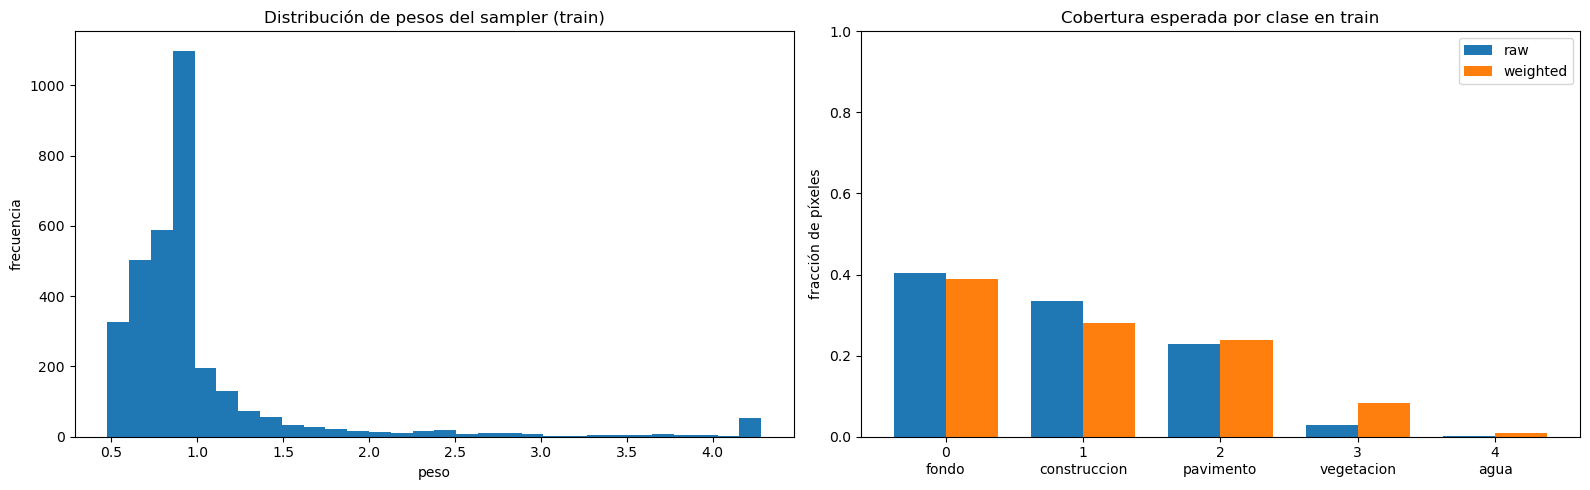

In [24]:
# ============================================================
# 7.3 VISUALIZACIÓN DE PESOS Y COBERTURA POR CLASE
# ============================================================

def plot_balance_diagnostics(
    train_sampler_weights: np.ndarray,
    raw_counts: Dict[int, int],
    weighted_counts: Dict[int, float],
    class_map: Dict[int, str],
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(train_sampler_weights, bins=30)
    axes[0].set_title("Distribución de pesos del sampler (train)")
    axes[0].set_xlabel("peso")
    axes[0].set_ylabel("frecuencia")

    class_ids = list(sorted(class_map.keys()))
    raw_total = float(sum(raw_counts.values()))
    weighted_total = float(sum(weighted_counts.values()))

    raw_fracs = [(raw_counts[c] / raw_total) if raw_total > 0 else 0.0 for c in class_ids]
    weighted_fracs = [(weighted_counts[c] / weighted_total) if weighted_total > 0 else 0.0 for c in class_ids]

    x = np.arange(len(class_ids))
    width = 0.38

    axes[1].bar(x - width / 2, raw_fracs, width=width, label="raw")
    axes[1].bar(x + width / 2, weighted_fracs, width=width, label="weighted")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"{c}\n{class_map[c]}" for c in class_ids])
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Cobertura esperada por clase en train")
    axes[1].set_ylabel("fracción de píxeles")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_balance_diagnostics(
    TRAIN_SAMPLER_WEIGHTS,
    TRAIN_CLASS_PIXEL_TOTALS,
    WEIGHTED_CLASS_PIXEL_TOTALS,
    CLASS_MAP,
)


## 8) Incorporación de U-Net preentrenado RGB

En esta fase se incorpora el **experimento control** con **U-Net preentrenado en RGB**.

Objetivos de esta fase:
- cerrar el **perfil final de normalización** usando **solo tiles de train**
- construir el `Dataset` / `DataLoader` del experimento control RGB
- instanciar una **U-Net con encoder preentrenado**
- validar que el flujo completo `datos -> modelo -> logits -> loss` funciona correctamente

Importante:
- aquí **todavía no entrenamos**
- la adaptación a **5 canales** entra en la **fase 9**
- este experimento control sirve como referencia limpia para comparar luego contra `RGB + NIR + HEIGHT`


In [25]:

# ============================================================
# 8. IMPORTS DEL STACK DE DEEP LEARNING Y CONFIGURACIÓN DE RUNTIME
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

try:
    import segmentation_models_pytorch as smp
except ImportError as e:
    raise ImportError(
        "No se encontró 'segmentation_models_pytorch'. "
        "Instálalo antes de continuar con la fase 8. "
        "Ejemplo: pip install segmentation-models-pytorch"
    ) from e

TORCH_SEED = SEED
torch.manual_seed(TORCH_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TORCH_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("PyTorch listo.")
print("  device:", DEVICE)
print("  torch version:", torch.__version__)
print("  CUDA disponible:", torch.cuda.is_available())
print("  segmentation_models_pytorch:", smp.__version__)


/opt/conda/envs/sara_semseg/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/conda/envs/sara_semseg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch listo.
  device: cuda
  torch version: 2.11.0+cu130
  CUDA disponible: True
  segmentation_models_pytorch: 0.5.0


In [26]:
# ============================================================
# 8.1 AJUSTE FINAL DEL PERFIL DE NORMALIZACIÓN USANDO SOLO TRAIN
#     (ROBUSTO CONTRA NODATA DEL NDSM)
# ============================================================

@dataclass(frozen=True)
class NormalizationFitConfig:
    max_train_tiles_for_fit: int = 256
    inner_stride: int = 4
    seed: int = SEED
    hard_valid_height_min: float = -1000.0
    hard_valid_height_max: float = 1000.0

NORM_FIT_CFG = NormalizationFitConfig()

def sample_train_tiles_for_normalization(
    train_catalog: Sequence[Dict],
    max_tiles: int = 256,
    seed: int = 42,
) -> List[Tile]:
    tiles = [meta["tile"] for meta in train_catalog if meta.get("keep", True)]
    if len(tiles) == 0:
        raise ValueError("No hay tiles de train disponibles para ajustar el perfil de normalización.")

    if len(tiles) <= max_tiles:
        return list(tiles)

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(tiles), size=max_tiles, replace=False)
    return [tiles[int(i)] for i in idx]

def fit_normalization_profile_from_train_tiles(
    ortho_fp: Path,
    ndsm_fp: Path,
    train_catalog: Sequence[Dict],
    cfg: NormalizationFitConfig,
) -> NormalizationProfile:
    selected_tiles = sample_train_tiles_for_normalization(
        train_catalog=train_catalog,
        max_tiles=cfg.max_train_tiles_for_fit,
        seed=cfg.seed,
    )

    with rasterio.open(ndsm_fp) as src_n:
        ndsm_nodata = src_n.nodata

    ortho_chunks: List[np.ndarray] = []
    height_chunks: List[np.ndarray] = []

    for tile in selected_tiles:
        ortho_tile = read_window_multiband(ortho_fp, tile, bands=[1, 2, 3, 4]).astype(np.float32)
        height_tile = read_window_singleband(ndsm_fp, tile, band=1).astype(np.float32)

        # submuestreo espacial interno
        ortho_tile = ortho_tile[:, ::cfg.inner_stride, ::cfg.inner_stride]
        height_tile = height_tile[::cfg.inner_stride, ::cfg.inner_stride]

        ortho_chunks.append(ortho_tile.reshape(ortho_tile.shape[0], -1))

        # saneamiento ROBUSTO de altura
        height_tile = sanitize_height_array(
            height_tile,
            nodata_value=ndsm_nodata,
            hard_valid_min=cfg.hard_valid_height_min,
            hard_valid_max=cfg.hard_valid_height_max,
        )

        finite_height = height_tile[np.isfinite(height_tile)]
        if finite_height.size > 0:
            height_chunks.append(finite_height.reshape(-1))

    if len(ortho_chunks) == 0:
        raise ValueError("No fue posible reunir muestras de ortofoto para el perfil de normalización.")
    if len(height_chunks) == 0:
        raise ValueError(
            "No fue posible reunir muestras válidas de altura para el perfil de normalización. "
            "Revisa el nDSM y su valor nodata."
        )

    ortho_train_sample = np.concatenate(ortho_chunks, axis=1).astype(np.float32)
    height_train_sample = np.concatenate(height_chunks, axis=0).astype(np.float32)

    profile = fit_normalization_profile_from_arrays(
        ortho_stack=ortho_train_sample,
        height_array=height_train_sample,
        lower_q_ortho=preview_profile.lower_q_ortho,
        upper_q_ortho=preview_profile.upper_q_ortho,
        lower_q_height=preview_profile.lower_q_height,
        upper_q_height=preview_profile.upper_q_height,
    )

    # chequeos fuertes
    print("Chequeo de perfil final TRAIN:")
    print(profile.to_dict())

    if not np.isfinite(profile.height_mean):
        raise ValueError("height_mean quedó no finito después del ajuste TRAIN.")
    if not np.isfinite(profile.height_std):
        raise ValueError("height_std quedó no finito después del ajuste TRAIN.")
    if profile.height_std <= 0:
        raise ValueError("height_std quedó no positivo después del ajuste TRAIN.")

    return profile

TRAIN_NORMALIZATION_PROFILE = fit_normalization_profile_from_train_tiles(
    ortho_fp=PATHS.ortho_fp,
    ndsm_fp=PATHS.ndsm_fp,
    train_catalog=train_balance_catalog,
    cfg=NORM_FIT_CFG,
)

print("Perfil FINAL de normalización ajustado con TRAIN:")
print(TRAIN_NORMALIZATION_PROFILE.to_dict())

Chequeo de perfil final TRAIN:
{'ortho_low': [3.0, 7.0, 17.0, 69.0], 'ortho_high': [251.0, 252.0, 252.0, 249.0], 'height_low': 0.0, 'height_high': 33.18098449707031, 'height_mean': 3.788656711578369, 'height_std': 6.079319000244141, 'ortho_bands': (1, 2, 3, 4), 'height_band': 1, 'lower_q_ortho': 2.0, 'upper_q_ortho': 98.0, 'lower_q_height': 1.0, 'upper_q_height': 99.0}
Perfil FINAL de normalización ajustado con TRAIN:
{'ortho_low': [3.0, 7.0, 17.0, 69.0], 'ortho_high': [251.0, 252.0, 252.0, 249.0], 'height_low': 0.0, 'height_high': 33.18098449707031, 'height_mean': 3.788656711578369, 'height_std': 6.079319000244141, 'ortho_bands': (1, 2, 3, 4), 'height_band': 1, 'lower_q_ortho': 2.0, 'upper_q_ortho': 98.0, 'lower_q_height': 1.0, 'upper_q_height': 99.0}


In [27]:

# ============================================================
# 8.2 DATASET Y DATALOADERS DEL EXPERIMENTO CONTROL RGB
# ============================================================

@dataclass(frozen=True)
class LoaderConfig:
    batch_size_train: int = 8
    batch_size_eval: int = 8
    num_workers: int = 0
    pin_memory: bool = torch.cuda.is_available()
    persistent_workers: bool = False

RGB_LOADER_CFG = LoaderConfig()

def normalize_rgb_sample(ortho_4ch: np.ndarray, profile: NormalizationProfile) -> np.ndarray:
    ortho_norm = normalize_ortho(ortho_4ch, profile)
    rgb = ortho_norm[:3]  # R, G, B
    return rgb.astype(np.float32)

class SegmentationTileDataset(Dataset):
    def __init__(
        self,
        tiles: Sequence[Tile],
        ortho_fp: Path,
        ndsm_fp: Path,
        mask_fp: Path,
        profile: NormalizationProfile,
        mode: str = "rgb",
    ) -> None:
        assert mode in {"rgb", "multisource"}, "mode debe ser 'rgb' o 'multisource'."
        self.tiles = list(tiles)
        self.ortho_fp = Path(ortho_fp)
        self.ndsm_fp = Path(ndsm_fp)
        self.mask_fp = Path(mask_fp)
        self.profile = profile
        self.mode = mode

    def __len__(self) -> int:
        return len(self.tiles)

    def __getitem__(self, idx: int):
        tile = self.tiles[idx]

        ortho_4ch = read_window_multiband(self.ortho_fp, tile, bands=[1, 2, 3, 4]).astype(np.float32)
        ndsm = read_window_singleband(self.ndsm_fp, tile, band=1).astype(np.float32)
        mask = read_window_singleband(self.mask_fp, tile, band=1).astype(np.int64)

        if self.mode == "rgb":
            x = normalize_rgb_sample(ortho_4ch, self.profile)
        else:
            x = normalize_multisource_sample(ortho_4ch, ndsm, self.profile)

        x_t = torch.from_numpy(x.astype(np.float32))
        y_t = torch.from_numpy(mask.astype(np.int64))
        return x_t, y_t

train_rgb_dataset = SegmentationTileDataset(
    tiles=TRAIN_TILES_BALANCED,
    ortho_fp=PATHS.ortho_fp,
    ndsm_fp=PATHS.ndsm_fp,
    mask_fp=PATHS.mask_fp,
    profile=TRAIN_NORMALIZATION_PROFILE,
    mode="rgb",
)

val_rgb_dataset = SegmentationTileDataset(
    tiles=tiles_val,
    ortho_fp=PATHS.ortho_fp,
    ndsm_fp=PATHS.ndsm_fp,
    mask_fp=PATHS.mask_fp,
    profile=TRAIN_NORMALIZATION_PROFILE,
    mode="rgb",
)

test_rgb_dataset = SegmentationTileDataset(
    tiles=tiles_test,
    ortho_fp=PATHS.ortho_fp,
    ndsm_fp=PATHS.ndsm_fp,
    mask_fp=PATHS.mask_fp,
    profile=TRAIN_NORMALIZATION_PROFILE,
    mode="rgb",
)

train_rgb_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(TRAIN_SAMPLER_WEIGHTS, dtype=torch.double),
    num_samples=len(TRAIN_SAMPLER_WEIGHTS),
    replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)

train_rgb_loader = DataLoader(
    train_rgb_dataset,
    batch_size=RGB_LOADER_CFG.batch_size_train,
    sampler=train_rgb_sampler,
    num_workers=RGB_LOADER_CFG.num_workers,
    pin_memory=RGB_LOADER_CFG.pin_memory,
    persistent_workers=RGB_LOADER_CFG.persistent_workers if RGB_LOADER_CFG.num_workers > 0 else False,
)

val_rgb_loader = DataLoader(
    val_rgb_dataset,
    batch_size=RGB_LOADER_CFG.batch_size_eval,
    shuffle=False,
    num_workers=RGB_LOADER_CFG.num_workers,
    pin_memory=RGB_LOADER_CFG.pin_memory,
    persistent_workers=RGB_LOADER_CFG.persistent_workers if RGB_LOADER_CFG.num_workers > 0 else False,
)

test_rgb_loader = DataLoader(
    test_rgb_dataset,
    batch_size=RGB_LOADER_CFG.batch_size_eval,
    shuffle=False,
    num_workers=RGB_LOADER_CFG.num_workers,
    pin_memory=RGB_LOADER_CFG.pin_memory,
    persistent_workers=RGB_LOADER_CFG.persistent_workers if RGB_LOADER_CFG.num_workers > 0 else False,
)

print("Datasets RGB listos.")
print(f"  train_rgb_dataset: {len(train_rgb_dataset):,} tiles")
print(f"  val_rgb_dataset  : {len(val_rgb_dataset):,} tiles")
print(f"  test_rgb_dataset : {len(test_rgb_dataset):,} tiles")
print("DataLoaders RGB listos para la fase 10.")


Datasets RGB listos.
  train_rgb_dataset: 3,259 tiles
  val_rgb_dataset  : 823 tiles
  test_rgb_dataset : 479 tiles
DataLoaders RGB listos para la fase 10.


In [28]:
# ============================================================
# 8.3 CONFIGURACIÓN DEL EXPERIMENTO CONTROL RGB (CUDA FIJO)
# ============================================================

import torch
import torch.nn as nn
from dataclasses import dataclass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

@dataclass(frozen=True)
class RGBModelConfig:
    architecture: str = "Unet"
    encoder_name: str = "resnet34"
    encoder_weights: str = "imagenet"
    in_channels: int = 3
    classes: int = MODEL_NUM_CLASSES
    activation: Optional[str] = None
    decoder_use_batchnorm: bool = True

RGB_MODEL_CFG = RGBModelConfig()

def count_trainable_parameters(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

def build_segmentation_loss(
    class_weights,
    ignore_index: int,
    device: torch.device,
) -> nn.Module:
    if isinstance(class_weights, torch.Tensor):
        weight_t = class_weights.detach().clone().float()
    else:
        weight_t = torch.as_tensor(class_weights, dtype=torch.float32)

    weight_t = weight_t.to(device)

    criterion = nn.CrossEntropyLoss(
        weight=weight_t,
        ignore_index=int(ignore_index),
    )

    # MUY IMPORTANTE: mover también el módulo para que su buffer `weight`
    # quede definitivamente en el mismo device.
    criterion = criterion.to(device)
    return criterion

# aliases robustos para no romper celdas posteriores
rgb_train_loader = train_rgb_loader
rgb_val_loader = val_rgb_loader
rgb_test_loader = test_rgb_loader

rgb_model = smp.Unet(
    encoder_name=RGB_MODEL_CFG.encoder_name,
    encoder_weights=RGB_MODEL_CFG.encoder_weights,
    in_channels=RGB_MODEL_CFG.in_channels,
    classes=RGB_MODEL_CFG.classes,
    activation=RGB_MODEL_CFG.activation,
    decoder_use_batchnorm=RGB_MODEL_CFG.decoder_use_batchnorm,
).to(DEVICE)

rgb_criterion = build_segmentation_loss(
    class_weights=LOSS_CLASS_WEIGHTS,
    ignore_index=IGNORE_INDEX,
    device=DEVICE,
)

# Verificación fuerte
criterion_weight_device = (
    rgb_criterion.weight.device if getattr(rgb_criterion, "weight", None) is not None else "None"
)

print("\nConfiguración RGB lista.")
print("  Modelo en device         :", next(rgb_model.parameters()).device)
print("  Criterion weight device  :", criterion_weight_device)
print("  Train loader batches     :", len(train_rgb_loader))
print("  Val loader batches       :", len(val_rgb_loader))
print("  Batch size train         :", RGB_LOADER_CFG.batch_size_train)
print("  Batch size eval          :", RGB_LOADER_CFG.batch_size_eval)
print("  NUM_CLASSES              :", MODEL_NUM_CLASSES)
print("  IGNORE_INDEX             :", IGNORE_INDEX)
print("  Encoder                  :", RGB_MODEL_CFG.encoder_name)
print("  Encoder weights          :", RGB_MODEL_CFG.encoder_weights)
print("  Parámetros entrenables   :", f"{count_trainable_parameters(rgb_model):,}")
print("  Pesos de clase           :", torch.as_tensor(LOSS_CLASS_WEIGHTS).cpu().numpy())

assert next(rgb_model.parameters()).device.type == DEVICE.type, "El modelo RGB no quedó en el DEVICE esperado."
assert rgb_criterion.weight is None or rgb_criterion.weight.device.type == DEVICE.type, "Los pesos de la loss no quedaron en el DEVICE esperado."

DEVICE: cuda

Configuración RGB lista.
  Modelo en device         : cuda:0
  Criterion weight device  : cuda:0
  Train loader batches     : 408
  Val loader batches       : 103
  Batch size train         : 8
  Batch size eval          : 8
  NUM_CLASSES              : 5
  IGNORE_INDEX             : 255
  Encoder                  : resnet34
  Encoder weights          : imagenet
  Parámetros entrenables   : 24,436,949
  Pesos de clase           : [1.0000001 1.0000001 1.0000001 1.0000001 1.0000001]


In [29]:

# ============================================================
# 8.4 SANITY CHECK DEL EXPERIMENTO CONTROL RGB (CUDA FIJO)
# ============================================================

rgb_model = rgb_model.to(DEVICE)
rgb_criterion = rgb_criterion.to(DEVICE)
rgb_model.eval()

batch_x, batch_y = next(iter(train_rgb_loader))

batch_x = batch_x.float().to(DEVICE, non_blocking=True)
batch_y = batch_y.long().to(DEVICE, non_blocking=True)

# Verificación previa
model_device = next(rgb_model.parameters()).device
criterion_weight_device = (
    rgb_criterion.weight.device if getattr(rgb_criterion, "weight", None) is not None else "None"
)

print("batch_x shape:", tuple(batch_x.shape), "| dtype:", batch_x.dtype, "| device:", batch_x.device)
print("batch_y shape:", tuple(batch_y.shape), "| dtype:", batch_y.dtype, "| device:", batch_y.device)
print("model device:", model_device)
print("criterion weight device:", criterion_weight_device)

assert model_device.type == DEVICE.type, "El modelo no está en el DEVICE esperado."
if rgb_criterion.weight is not None:
    assert rgb_criterion.weight.device.type == DEVICE.type, "La weight de la loss no está en el DEVICE esperado."

with torch.no_grad():
    logits = rgb_model(batch_x)
    loss_value = rgb_criterion(logits, batch_y)

print("\nForward OK.")
print("  logits shape :", tuple(logits.shape))
print("  logits dtype :", logits.dtype)
print("  logits device:", logits.device)
print("  loss         :", float(loss_value.detach().cpu().item()))

assert batch_x.shape[1] == 3, "El experimento control RGB debe tener exactamente 3 canales."
assert logits.shape[0] == batch_x.shape[0], "Batch size inconsistente entre input y logits."
assert logits.shape[1] == MODEL_NUM_CLASSES, f"Se esperaban {MODEL_NUM_CLASSES} clases en logits."
assert logits.shape[2:] == batch_y.shape[1:], "Las dimensiones espaciales de logits y máscara no coinciden."
assert torch.isfinite(loss_value).item(), "La loss de sanity check RGB no es finita."

print("\nSanity check RGB superado.")

batch_x shape: (8, 3, 256, 256) | dtype: torch.float32 | device: cuda:0
batch_y shape: (8, 256, 256) | dtype: torch.int64 | device: cuda:0
model device: cuda:0
criterion weight device: cuda:0

Forward OK.
  logits shape : (8, 5, 256, 256)
  logits dtype : torch.float32
  logits device: cuda:0
  loss         : 1.6469982862472534

Sanity check RGB superado.


## Estado alcanzado hasta fase 8

Queda implementado el **experimento control** con:
- normalización final ajustada usando **solo train**
- `Dataset` / `DataLoader` RGB listos
- `WeightedRandomSampler` conectado a la fase 7
- **U-Net con encoder preentrenado** instanciada y validada

El siguiente paso es la **fase 9**:
- adaptar la arquitectura y el pipeline de entrada a **5 canales**
- conservar el valor del preentrenamiento tanto como sea posible
- dejar listo el experimento multifuente para entrenar y comparar


## 9) Adaptación de la arquitectura a 5 canales

En esta fase se adapta el flujo completo al experimento **multifuente** con **5 canales**:

- `R`
- `G`
- `B`
- `NIR`
- `HEIGHT`

Objetivos de esta fase:
- reutilizar el mismo pipeline de datos y el mismo split ya congelado
- construir `Dataset` y `DataLoader` para `RGB + NIR + HEIGHT`
- adaptar una **U-Net con encoder preentrenado** a **5 canales**
- conservar el valor del preentrenamiento tanto como sea posible
- validar que el flujo `datos multifuente -> modelo 5 canales -> logits -> loss` funciona correctamente

Importante:
- aquí todavía **no entrenamos**
- la fase 10 utilizará el experimento control RGB ya armado
- la fase 11 utilizará este experimento multifuente para comparar contra RGB

In [30]:
# ============================================================
# 9.1 DATASET Y DATALOADERS DEL EXPERIMENTO MULTIFUENTE (5 CANALES)
# ============================================================

MULTISOURCE_LOADER_CFG = LoaderConfig(
    batch_size_train=RGB_LOADER_CFG.batch_size_train,
    batch_size_eval=RGB_LOADER_CFG.batch_size_eval,
    num_workers=RGB_LOADER_CFG.num_workers,
    pin_memory=RGB_LOADER_CFG.pin_memory,
    persistent_workers=RGB_LOADER_CFG.persistent_workers,
)

train_multisource_dataset = SegmentationTileDataset(
    tiles=TRAIN_TILES_BALANCED,
    ortho_fp=PATHS.ortho_fp,
    ndsm_fp=PATHS.ndsm_fp,
    mask_fp=PATHS.mask_fp,
    profile=TRAIN_NORMALIZATION_PROFILE,
    mode="multisource",
)

val_multisource_dataset = SegmentationTileDataset(
    tiles=tiles_val,
    ortho_fp=PATHS.ortho_fp,
    ndsm_fp=PATHS.ndsm_fp,
    mask_fp=PATHS.mask_fp,
    profile=TRAIN_NORMALIZATION_PROFILE,
    mode="multisource",
)

test_multisource_dataset = SegmentationTileDataset(
    tiles=tiles_test,
    ortho_fp=PATHS.ortho_fp,
    ndsm_fp=PATHS.ndsm_fp,
    mask_fp=PATHS.mask_fp,
    profile=TRAIN_NORMALIZATION_PROFILE,
    mode="multisource",
)

train_multisource_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(TRAIN_SAMPLER_WEIGHTS, dtype=torch.double),
    num_samples=len(TRAIN_SAMPLER_WEIGHTS),
    replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)

train_multisource_loader = DataLoader(
    train_multisource_dataset,
    batch_size=MULTISOURCE_LOADER_CFG.batch_size_train,
    sampler=train_multisource_sampler,
    num_workers=MULTISOURCE_LOADER_CFG.num_workers,
    pin_memory=MULTISOURCE_LOADER_CFG.pin_memory,
    persistent_workers=MULTISOURCE_LOADER_CFG.persistent_workers if MULTISOURCE_LOADER_CFG.num_workers > 0 else False,
)

val_multisource_loader = DataLoader(
    val_multisource_dataset,
    batch_size=MULTISOURCE_LOADER_CFG.batch_size_eval,
    shuffle=False,
    num_workers=MULTISOURCE_LOADER_CFG.num_workers,
    pin_memory=MULTISOURCE_LOADER_CFG.pin_memory,
    persistent_workers=MULTISOURCE_LOADER_CFG.persistent_workers if MULTISOURCE_LOADER_CFG.num_workers > 0 else False,
)

test_multisource_loader = DataLoader(
    test_multisource_dataset,
    batch_size=MULTISOURCE_LOADER_CFG.batch_size_eval,
    shuffle=False,
    num_workers=MULTISOURCE_LOADER_CFG.num_workers,
    pin_memory=MULTISOURCE_LOADER_CFG.pin_memory,
    persistent_workers=MULTISOURCE_LOADER_CFG.persistent_workers if MULTISOURCE_LOADER_CFG.num_workers > 0 else False,
)

print("Datasets multifuente listos.")
print(f"  train_multisource_dataset: {len(train_multisource_dataset):,} tiles")
print(f"  val_multisource_dataset  : {len(val_multisource_dataset):,} tiles")
print(f"  test_multisource_dataset : {len(test_multisource_dataset):,} tiles")
print("DataLoaders multifuente listos para la fase 11.")

Datasets multifuente listos.
  train_multisource_dataset: 3,259 tiles
  val_multisource_dataset  : 823 tiles
  test_multisource_dataset : 479 tiles
DataLoaders multifuente listos para la fase 11.


In [31]:
# ============================================================
# 9.2 UTILIDADES PARA ADAPTAR EL ENCODER PREENTRENADO A 5 CANALES
# ============================================================

@dataclass(frozen=True)
class MultiSourceInputAdaptationConfig:
    target_in_channels: int = MODEL_INPUT_CHANNELS
    reference_in_channels: int = 3
    extra_channels_init: str = "mean"   # {"mean", "zeros"}
    replicate_reference_order: Tuple[str, ...] = ("R", "G", "B")
    extra_channel_names: Tuple[str, ...] = ("NIR", "HEIGHT")

MULTISOURCE_ADAPT_CFG = MultiSourceInputAdaptationConfig()

def get_parent_module_and_attr(module: nn.Module, qualified_name: str):
    parts = qualified_name.split(".")
    parent = module
    for part in parts[:-1]:
        parent = parent[int(part)] if part.isdigit() else getattr(parent, part)
    last = parts[-1]
    return parent, last

def find_first_conv2d_name(module: nn.Module, expected_in_channels: Optional[int] = None) -> Tuple[str, nn.Conv2d]:
    fallback = None
    for name, submodule in module.named_modules():
        if isinstance(submodule, nn.Conv2d):
            if fallback is None:
                fallback = (name, submodule)
            if expected_in_channels is None or submodule.in_channels == expected_in_channels:
                return name, submodule
    if fallback is None:
        raise ValueError("No se encontró ninguna capa Conv2d en el módulo dado.")
    return fallback

def clone_and_expand_first_conv(
    conv3: nn.Conv2d,
    new_in_channels: int,
    extra_channels_init: str = "mean",
) -> nn.Conv2d:
    if new_in_channels < 1:
        raise ValueError("new_in_channels debe ser >= 1.")

    new_conv = nn.Conv2d(
        in_channels=new_in_channels,
        out_channels=conv3.out_channels,
        kernel_size=conv3.kernel_size,
        stride=conv3.stride,
        padding=conv3.padding,
        dilation=conv3.dilation,
        groups=conv3.groups,
        bias=(conv3.bias is not None),
        padding_mode=conv3.padding_mode,
    )

    with torch.no_grad():
        old_w = conv3.weight.data
        new_w = new_conv.weight.data

        copy_channels = min(conv3.in_channels, new_in_channels)
        new_w[:, :copy_channels] = old_w[:, :copy_channels]

        if new_in_channels > conv3.in_channels:
            if extra_channels_init == "mean":
                ref = old_w.mean(dim=1, keepdim=True)
                for ch in range(conv3.in_channels, new_in_channels):
                    new_w[:, ch:ch+1] = ref
            elif extra_channels_init == "zeros":
                for ch in range(conv3.in_channels, new_in_channels):
                    new_w[:, ch:ch+1] = 0.0
            else:
                raise ValueError("extra_channels_init debe ser 'mean' o 'zeros'.")

        if new_in_channels < conv3.in_channels:
            new_w.copy_(old_w[:, :new_in_channels])

        if conv3.bias is not None:
            new_conv.bias.data.copy_(conv3.bias.data)

    return new_conv

def patch_encoder_first_conv(
    target_model: nn.Module,
    reference_model: nn.Module,
    adapt_cfg: MultiSourceInputAdaptationConfig,
) -> Dict[str, object]:
    ref_name, ref_conv = find_first_conv2d_name(
        reference_model.encoder,
        expected_in_channels=adapt_cfg.reference_in_channels,
    )
    tgt_name, _ = find_first_conv2d_name(
        target_model.encoder,
        expected_in_channels=adapt_cfg.target_in_channels,
    )

    adapted_conv = clone_and_expand_first_conv(
        ref_conv,
        new_in_channels=adapt_cfg.target_in_channels,
        extra_channels_init=adapt_cfg.extra_channels_init,
    )

    tgt_parent, tgt_attr = get_parent_module_and_attr(target_model.encoder, tgt_name)
    if tgt_attr.isdigit():
        tgt_parent[int(tgt_attr)] = adapted_conv
    else:
        setattr(tgt_parent, tgt_attr, adapted_conv)

    return {
        "reference_conv_name": ref_name,
        "target_conv_name": tgt_name,
        "reference_in_channels": ref_conv.in_channels,
        "target_in_channels": adapt_cfg.target_in_channels,
        "extra_channels_init": adapt_cfg.extra_channels_init,
    }

def load_pretrained_weights_except_first_conv(
    target_model: nn.Module,
    reference_model: nn.Module,
    reference_first_conv_name: str,
) -> Dict[str, List[str]]:
    reference_state = reference_model.state_dict()
    first_conv_weight_key = f"encoder.{reference_first_conv_name}.weight"
    first_conv_bias_key = f"encoder.{reference_first_conv_name}.bias"

    filtered_state = {
        k: v for k, v in reference_state.items()
        if k not in {first_conv_weight_key, first_conv_bias_key}
    }

    incompatible = target_model.load_state_dict(filtered_state, strict=False)

    return {
        "missing_keys": list(incompatible.missing_keys),
        "unexpected_keys": list(incompatible.unexpected_keys),
        "skipped_keys": [k for k in (first_conv_weight_key, first_conv_bias_key) if k in reference_state],
    }

In [32]:
# ============================================================
# 9.3 DEFINICIÓN DE U-NET PREENTRENADO ADAPTADA A 5 CANALES
# ============================================================

@dataclass(frozen=True)
class PretrainedUNetMultiSourceConfig:
    architecture: str = "Unet"
    encoder_name: str = RGB_MODEL_CFG.encoder_name
    encoder_weights: str = RGB_MODEL_CFG.encoder_weights
    in_channels: int = MODEL_INPUT_CHANNELS
    classes: int = MODEL_NUM_CLASSES
    activation: Optional[str] = None
    decoder_use_batchnorm: bool = True
    extra_channels_init: str = MULTISOURCE_ADAPT_CFG.extra_channels_init

MULTISOURCE_MODEL_CFG = PretrainedUNetMultiSourceConfig()

def build_pretrained_unet_multisource(
    cfg: PretrainedUNetMultiSourceConfig,
    adapt_cfg: MultiSourceInputAdaptationConfig,
) -> Tuple[nn.Module, Dict[str, object]]:
    if cfg.in_channels != adapt_cfg.target_in_channels:
        raise ValueError("cfg.in_channels y adapt_cfg.target_in_channels deben coincidir.")

    reference_rgb_model = smp.Unet(
        encoder_name=cfg.encoder_name,
        encoder_weights=cfg.encoder_weights,
        in_channels=adapt_cfg.reference_in_channels,
        classes=cfg.classes,
        activation=cfg.activation,
        decoder_use_batchnorm=cfg.decoder_use_batchnorm,
    )

    multisource_model = smp.Unet(
        encoder_name=cfg.encoder_name,
        encoder_weights=None,
        in_channels=cfg.in_channels,
        classes=cfg.classes,
        activation=cfg.activation,
        decoder_use_batchnorm=cfg.decoder_use_batchnorm,
    )

    patch_info = patch_encoder_first_conv(
        target_model=multisource_model,
        reference_model=reference_rgb_model,
        adapt_cfg=adapt_cfg,
    )

    load_info = load_pretrained_weights_except_first_conv(
        target_model=multisource_model,
        reference_model=reference_rgb_model,
        reference_first_conv_name=patch_info["reference_conv_name"],
    )

    diagnostics = {
        "patch_info": patch_info,
        "load_info": load_info,
        "encoder_name": cfg.encoder_name,
        "encoder_weights": cfg.encoder_weights,
        "in_channels": cfg.in_channels,
        "classes": cfg.classes,
    }
    return multisource_model, diagnostics

multisource_model, multisource_pretrain_diagnostics = build_pretrained_unet_multisource(
    MULTISOURCE_MODEL_CFG,
    MULTISOURCE_ADAPT_CFG,
)

multisource_model = multisource_model.to(DEVICE)

# CORRECCIÓN CLAVE: pasar device=DEVICE
multisource_criterion = build_segmentation_loss(
    class_weights=LOSS_CLASS_WEIGHTS,
    ignore_index=IGNORE_INDEX,
    device=DEVICE,
)

# por seguridad, mover también el módulo loss
multisource_criterion = multisource_criterion.to(DEVICE)

print("Modelo multifuente preentrenado listo.")
print("  arquitectura            :", MULTISOURCE_MODEL_CFG.architecture)
print("  encoder                 :", MULTISOURCE_MODEL_CFG.encoder_name)
print("  pesos encoder base      :", MULTISOURCE_MODEL_CFG.encoder_weights)
print("  in_channels             :", MULTISOURCE_MODEL_CFG.in_channels)
print("  clases salida           :", MULTISOURCE_MODEL_CFG.classes)
print("  parámetros entrenables  :", f"{count_trainable_parameters(multisource_model):,}")
print("  model device            :", next(multisource_model.parameters()).device)
print(
    "  criterion weight device :",
    multisource_criterion.weight.device if multisource_criterion.weight is not None else "None"
)
print("  diagnostics patch       :", multisource_pretrain_diagnostics["patch_info"])
print("  diagnostics load        :", multisource_pretrain_diagnostics["load_info"])

assert next(multisource_model.parameters()).device.type == DEVICE.type, "El modelo multifuente no quedó en el DEVICE esperado."
if multisource_criterion.weight is not None:
    assert multisource_criterion.weight.device.type == DEVICE.type, "La weight de la loss multifuente no quedó en el DEVICE esperado."

Modelo multifuente preentrenado listo.
  arquitectura            : Unet
  encoder                 : resnet34
  pesos encoder base      : imagenet
  in_channels             : 5
  clases salida           : 5
  parámetros entrenables  : 24,443,221
  model device            : cuda:0
  criterion weight device : cuda:0
  diagnostics patch       : {'reference_conv_name': 'conv1', 'target_conv_name': 'conv1', 'reference_in_channels': 3, 'target_in_channels': 5, 'extra_channels_init': 'mean'}
  diagnostics load        : {'missing_keys': ['encoder.conv1.weight'], 'unexpected_keys': [], 'skipped_keys': ['encoder.conv1.weight']}


In [33]:
# ============================================================
# 9.4 SANITY CHECK DEL EXPERIMENTO MULTIFUENTE
# ============================================================

multisource_model = multisource_model.to(DEVICE)
multisource_criterion = multisource_criterion.to(DEVICE)
multisource_model.eval()

batch_x_ms, batch_y_ms = next(iter(train_multisource_loader))

batch_x_ms = batch_x_ms.float().to(DEVICE, non_blocking=True)
batch_y_ms = batch_y_ms.long().to(DEVICE, non_blocking=True)

print("Batch multifuente:")
print("  x shape   :", tuple(batch_x_ms.shape))
print("  y shape   :", tuple(batch_y_ms.shape))
print("  x dtype   :", batch_x_ms.dtype)
print("  y dtype   :", batch_y_ms.dtype)
print("  x device  :", batch_x_ms.device)
print("  y device  :", batch_y_ms.device)
print("  model dev :", next(multisource_model.parameters()).device)
print(
    "  crit dev  :",
    multisource_criterion.weight.device if multisource_criterion.weight is not None else "None"
)

with torch.no_grad():
    logits_ms = multisource_model(batch_x_ms)
    loss_value_ms = multisource_criterion(logits_ms, batch_y_ms)

print("\nForward multifuente OK.")
print("  logits shape    :", tuple(logits_ms.shape))
print("  logits dtype    :", logits_ms.dtype)
print("  logits device   :", logits_ms.device)
print("  loss de prueba  :", float(loss_value_ms.detach().cpu().item()))

assert batch_x_ms.shape[1] == MODEL_INPUT_CHANNELS, "El batch multifuente no tiene 5 canales."
assert logits_ms.shape[0] == batch_x_ms.shape[0], "Batch size inconsistente entre input y logits."
assert logits_ms.shape[1] == MODEL_NUM_CLASSES, "El número de canales de salida no coincide con las clases esperadas."
assert logits_ms.shape[2:] == batch_y_ms.shape[1:], "Las dimensiones espaciales de logits y máscara no coinciden."
assert torch.isfinite(loss_value_ms).item(), "La loss de sanity check multifuente no es finita."

print("\nLa fase 9 queda lista para la fase 11 (entrenamiento multifuente).")

Batch multifuente:
  x shape   : (8, 5, 256, 256)
  y shape   : (8, 256, 256)
  x dtype   : torch.float32
  y dtype   : torch.int64
  x device  : cuda:0
  y device  : cuda:0
  model dev : cuda:0
  crit dev  : cuda:0

Forward multifuente OK.
  logits shape    : (8, 5, 256, 256)
  logits dtype    : torch.float32
  logits device   : cuda:0
  loss de prueba  : 1.8063709735870361

La fase 9 queda lista para la fase 11 (entrenamiento multifuente).


## Estado alcanzado hasta fase 9

Queda implementada la adaptación completa del experimento **multifuente**:

- `Dataset` / `DataLoader` para `RGB + NIR + HEIGHT`
- normalización final ya reutilizable en ambos experimentos
- **U-Net con encoder preentrenado** adaptada a **5 canales**
- estrategia explícita para conservar el valor del preentrenamiento
- validación de `forward` y `loss` para el flujo multifuente

El siguiente paso natural es la **fase 10**:
- entrenar el **experimento control RGB**
- registrar métricas y checkpoints comparables
- dejar lista la referencia contra la cual se evaluará la fase 11

## 10) Entrenamiento del experimento control RGB

En esta fase se entrena el **experimento control RGB** bajo una metodología consistente con el plan:

- **U-Net con encoder preentrenado**
- entrenamiento por **tiles**
- **split espacial** ya congelado
- normalización ajustada con **train**
- manejo de desbalance mediante:
  - **pesos por clase** en la loss
  - **WeightedRandomSampler** en `train`
- control del entrenamiento con:
  - `AdamW`
  - scheduler por validación
  - early stopping
  - guardado del **mejor checkpoint**
- evaluación por época con:
  - `loss`
  - `overall accuracy`
  - `macro F1`
  - `mean IoU`
  - métricas por clase

Importante:
- esta fase entrena **solo el modelo RGB**
- la fase 11 reutilizará la misma lógica para el experimento multifuente
- el objetivo de este entrenamiento es dejar un **baseline fuerte, limpio y comparable**


In [34]:
# ============================================================
# 10.1 CONFIGURACIÓN DE ENTRENAMIENTO Y RUTAS DE SALIDA
# ============================================================

from copy import deepcopy
import json
import time
from contextlib import nullcontext

@dataclass(frozen=True)
class RGBTrainingConfig:
    epochs: int = 25
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    grad_clip_norm: float = 1.0
    amp: bool = False  # primero estabilidad; AMP se reactiva solo cuando el baseline sea estable
    early_stopping_patience: int = 7
    scheduler_mode: str = "max"
    scheduler_factor: float = 0.5
    scheduler_patience: int = 3
    scheduler_min_lr: float = 1e-6
    monitor_metric: str = "val_mean_iou"   # {"val_mean_iou", "val_macro_f1", "val_loss"}
    monitor_mode: str = "max"              # {"max", "min"}

RGB_TRAIN_CFG = RGBTrainingConfig()

RGB_PHASE10_DIR = PATHS.output_dir / "fase10_rgb_control"
RGB_PHASE10_DIR.mkdir(parents=True, exist_ok=True)

RGB_CHECKPOINT_FP = RGB_PHASE10_DIR / "best_rgb_control.pt"
RGB_HISTORY_FP = RGB_PHASE10_DIR / "rgb_training_history.json"

print("Configuración de entrenamiento RGB:")
print(RGB_TRAIN_CFG)
print(f"Directorio de salida fase 10: {RGB_PHASE10_DIR}")
print(f"Checkpoint mejor modelo    : {RGB_CHECKPOINT_FP}")
print(f"Histórico de entrenamiento : {RGB_HISTORY_FP}")


Configuración de entrenamiento RGB:
RGBTrainingConfig(epochs=25, learning_rate=0.0001, weight_decay=0.0001, grad_clip_norm=1.0, amp=False, early_stopping_patience=7, scheduler_mode='max', scheduler_factor=0.5, scheduler_patience=3, scheduler_min_lr=1e-06, monitor_metric='val_mean_iou', monitor_mode='max')
Directorio de salida fase 10: /home/jovyan/work/datos/DATOS_AJUSTADOS/salidas_dl_v2/fase10_rgb_control
Checkpoint mejor modelo    : /home/jovyan/work/datos/DATOS_AJUSTADOS/salidas_dl_v2/fase10_rgb_control/best_rgb_control.pt
Histórico de entrenamiento : /home/jovyan/work/datos/DATOS_AJUSTADOS/salidas_dl_v2/fase10_rgb_control/rgb_training_history.json


In [35]:
# ============================================================
# 10.2 UTILIDADES DE MÉTRICAS, TRAIN/VAL LOOP Y CHECKPOINTING
# ============================================================

def get_current_lr(optimizer: torch.optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def build_confusion_matrix(
    preds: torch.Tensor,
    targets: torch.Tensor,
    num_classes: int,
    ignore_index: int,
) -> torch.Tensor:
    valid = (targets != ignore_index)
    if not torch.any(valid):
        return torch.zeros((num_classes, num_classes), dtype=torch.int64)

    t = targets[valid].reshape(-1).to(torch.int64)
    p = preds[valid].reshape(-1).to(torch.int64)

    encoded = t * num_classes + p
    conf = torch.bincount(encoded, minlength=num_classes * num_classes)
    conf = conf.reshape(num_classes, num_classes).cpu()
    return conf

def metrics_from_confusion_matrix(
    conf: torch.Tensor,
    class_map: Dict[int, str],
) -> Dict:
    conf = conf.to(torch.float64)
    tp = torch.diag(conf)
    fp = conf.sum(dim=0) - tp
    fn = conf.sum(dim=1) - tp

    denom_precision = tp + fp
    denom_recall = tp + fn
    denom_f1 = 2 * tp + fp + fn
    denom_iou = tp + fp + fn

    precision = torch.where(denom_precision > 0, tp / denom_precision, torch.zeros_like(tp))
    recall = torch.where(denom_recall > 0, tp / denom_recall, torch.zeros_like(tp))
    f1 = torch.where(denom_f1 > 0, 2 * tp / denom_f1, torch.zeros_like(tp))
    iou = torch.where(denom_iou > 0, tp / denom_iou, torch.zeros_like(tp))

    total = conf.sum()
    overall_acc = float(tp.sum() / total) if total > 0 else 0.0
    macro_f1 = float(f1.mean()) if f1.numel() > 0 else 0.0
    mean_iou = float(iou.mean()) if iou.numel() > 0 else 0.0

    per_class = {}
    for c, name in class_map.items():
        per_class[c] = {
            "name": name,
            "precision": float(precision[c].item()),
            "recall": float(recall[c].item()),
            "f1": float(f1[c].item()),
            "iou": float(iou[c].item()),
            "support": int(conf[c].sum().item()),
        }

    return {
        "overall_acc": overall_acc,
        "macro_f1": macro_f1,
        "mean_iou": mean_iou,
        "per_class": per_class,
        "confusion_matrix": conf.to(torch.int64),
    }

def _autocast_ctx(device: torch.device, enabled: bool):
    if enabled and device.type == "cuda":
        return torch.amp.autocast("cuda", enabled=True)
    return nullcontext()

def _sanitize_batch_input(xb: torch.Tensor) -> torch.Tensor:
    if not torch.isfinite(xb).all():
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
    return xb

def run_train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    ignore_index: int,
    use_amp: bool,
    scaler: Optional[object] = None,
    grad_clip_norm: Optional[float] = None,
) -> Dict[str, float]:
    model.train()

    total_loss_weighted = 0.0
    total_valid_pixels = 0
    total_steps = 0
    skipped_batches = 0

    for step_idx, (xb, yb) in enumerate(loader, start=1):
        xb = xb.float().to(device, non_blocking=True)
        yb = yb.long().to(device, non_blocking=True)
        xb = _sanitize_batch_input(xb)

        valid_pixels = int((yb != ignore_index).sum().item())
        if valid_pixels <= 0:
            skipped_batches += 1
            continue

        optimizer.zero_grad(set_to_none=True)

        with _autocast_ctx(device, use_amp):
            logits = model(xb)
            if not torch.isfinite(logits).all():
                skipped_batches += 1
                continue
            loss = criterion(logits, yb)

        if not torch.isfinite(loss):
            skipped_batches += 1
            continue

        if use_amp and scaler is not None and device.type == "cuda":
            scaler.scale(loss).backward()

            if grad_clip_norm is not None and grad_clip_norm > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)

            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()

            if grad_clip_norm is not None and grad_clip_norm > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)

            optimizer.step()

        total_loss_weighted += float(loss.detach().item()) * valid_pixels
        total_valid_pixels += valid_pixels
        total_steps += 1

    if total_steps == 0:
        raise RuntimeError(
            "No se completó ningún step válido en entrenamiento. "
            "Revisa normalización, datos de entrada o estabilidad numérica."
        )

    mean_loss = total_loss_weighted / max(total_valid_pixels, 1)
    return {
        "loss": float(mean_loss),
        "steps": int(total_steps),
        "valid_pixels": int(total_valid_pixels),
        "skipped_batches": int(skipped_batches),
    }

@torch.no_grad()
def run_eval_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    num_classes: int,
    class_map: Dict[int, str],
    ignore_index: int,
    use_amp: bool,
) -> Dict:
    model.eval()

    total_loss_weighted = 0.0
    total_valid_pixels = 0
    total_steps = 0
    skipped_batches = 0
    conf = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    for step_idx, (xb, yb) in enumerate(loader, start=1):
        xb = xb.float().to(device, non_blocking=True)
        yb = yb.long().to(device, non_blocking=True)
        xb = _sanitize_batch_input(xb)

        valid_pixels = int((yb != ignore_index).sum().item())
        if valid_pixels <= 0:
            skipped_batches += 1
            continue

        with _autocast_ctx(device, use_amp):
            logits = model(xb)
            if not torch.isfinite(logits).all():
                skipped_batches += 1
                continue
            loss = criterion(logits, yb)

        if not torch.isfinite(loss):
            skipped_batches += 1
            continue

        preds = torch.argmax(logits, dim=1)
        conf += build_confusion_matrix(preds, yb, num_classes=num_classes, ignore_index=ignore_index)

        total_loss_weighted += float(loss.detach().item()) * valid_pixels
        total_valid_pixels += valid_pixels
        total_steps += 1

    if total_steps == 0:
        raise RuntimeError(
            "No se completó ningún step válido en evaluación. "
            "Revisa la estabilidad numérica del modelo o la calidad de los batches."
        )

    mean_loss = total_loss_weighted / max(total_valid_pixels, 1)
    metrics = metrics_from_confusion_matrix(conf, class_map=class_map)
    metrics.update({
        "loss": float(mean_loss),
        "steps": int(total_steps),
        "valid_pixels": int(total_valid_pixels),
        "skipped_batches": int(skipped_batches),
    })
    return metrics

def is_better_metric(
    current: float,
    best: Optional[float],
    mode: str,
) -> bool:
    if not np.isfinite(current):
        return False
    if best is None:
        return True
    if mode == "max":
        return current > best
    if mode == "min":
        return current < best
    raise ValueError("mode debe ser 'max' o 'min'.")

def flatten_epoch_record(record: Dict) -> Dict:
    flat = {}
    for k, v in record.items():
        if k == "per_class":
            for c, d in v.items():
                prefix = f"class_{c}_{d['name']}"
                flat[f"{prefix}_precision"] = d["precision"]
                flat[f"{prefix}_recall"] = d["recall"]
                flat[f"{prefix}_f1"] = d["f1"]
                flat[f"{prefix}_iou"] = d["iou"]
                flat[f"{prefix}_support"] = d["support"]
        elif k == "confusion_matrix":
            flat["confusion_matrix"] = v.tolist()
        else:
            flat[k] = v
    return flat

print("Utilidades de entrenamiento/evaluación robustas listas para fases 10 y 11.")


Utilidades de entrenamiento/evaluación robustas listas para fases 10 y 11.


In [36]:
# ============================================================
# 10.3 ENTRENAMIENTO DEL EXPERIMENTO CONTROL RGB
# ============================================================

import json
import time
from copy import deepcopy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

# ------------------------------------------------------------
# Helpers de serialización robusta
# ------------------------------------------------------------
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, torch.Tensor):
        obj = obj.detach().cpu()
        return obj.item() if obj.ndim == 0 else obj.tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer, np.bool_)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    return obj

def flatten_epoch_record_safe(record: dict) -> dict:
    """
    Aplana y vuelve serializable el registro por época.
    """
    out = {}
    for k, v in record.items():
        if k == "val_per_class":
            # mantener estructura pero 100% serializable
            out[k] = make_json_safe(v)
        elif k == "val_confusion_matrix":
            out[k] = make_json_safe(v)
        else:
            out[k] = make_json_safe(v)
    return out

# ------------------------------------------------------------
# Reconstruir modelo y loss desde cero
# ------------------------------------------------------------
rgb_model = smp.Unet(
    encoder_name=RGB_MODEL_CFG.encoder_name,
    encoder_weights=RGB_MODEL_CFG.encoder_weights,
    in_channels=RGB_MODEL_CFG.in_channels,
    classes=RGB_MODEL_CFG.classes,
    activation=RGB_MODEL_CFG.activation,
    decoder_use_batchnorm=RGB_MODEL_CFG.decoder_use_batchnorm,
).to(DEVICE)

rgb_criterion = build_segmentation_loss(
    class_weights=LOSS_CLASS_WEIGHTS,
    ignore_index=IGNORE_INDEX,
    device=DEVICE,
).to(DEVICE)

rgb_optimizer = torch.optim.AdamW(
    rgb_model.parameters(),
    lr=RGB_TRAIN_CFG.learning_rate,
    weight_decay=RGB_TRAIN_CFG.weight_decay,
)

rgb_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    rgb_optimizer,
    mode=RGB_TRAIN_CFG.scheduler_mode,
    factor=RGB_TRAIN_CFG.scheduler_factor,
    patience=RGB_TRAIN_CFG.scheduler_patience,
    min_lr=RGB_TRAIN_CFG.scheduler_min_lr,
)

rgb_history: List[Dict] = []
rgb_best_metric: Optional[float] = None
rgb_best_epoch: Optional[int] = None
rgb_epochs_without_improvement = 0
rgb_training_start = time.time()

# AMP moderno
if DEVICE.type == "cuda":
    rgb_scaler = torch.amp.GradScaler("cuda", enabled=RGB_TRAIN_CFG.amp)
    torch.cuda.empty_cache()
else:
    rgb_scaler = None

print("Inicio entrenamiento RGB control...")
print(f"Monitor principal: {RGB_TRAIN_CFG.monitor_metric} ({RGB_TRAIN_CFG.monitor_mode})")
print("AMP habilitado:", RGB_TRAIN_CFG.amp)
print("LR inicial:", RGB_TRAIN_CFG.learning_rate)

for epoch in range(1, RGB_TRAIN_CFG.epochs + 1):
    epoch_start = time.time()

    train_metrics = run_train_epoch(
        model=rgb_model,
        loader=train_rgb_loader,
        optimizer=rgb_optimizer,
        criterion=rgb_criterion,
        device=DEVICE,
        ignore_index=IGNORE_INDEX,
        use_amp=RGB_TRAIN_CFG.amp,
        scaler=rgb_scaler,
        grad_clip_norm=RGB_TRAIN_CFG.grad_clip_norm,
    )

    val_metrics = run_eval_epoch(
        model=rgb_model,
        loader=val_rgb_loader,
        criterion=rgb_criterion,
        device=DEVICE,
        num_classes=MODEL_NUM_CLASSES,
        class_map=CLASS_MAP,
        ignore_index=IGNORE_INDEX,
        use_amp=RGB_TRAIN_CFG.amp,
    )

    current_monitor = (
        val_metrics["loss"]
        if RGB_TRAIN_CFG.monitor_metric == "val_loss"
        else val_metrics[RGB_TRAIN_CFG.monitor_metric.replace("val_", "")]
    )

    if not np.isfinite(current_monitor):
        raise RuntimeError(
            f"La métrica monitor ({RGB_TRAIN_CFG.monitor_metric}) no es finita en la época {epoch}."
        )

    rgb_scheduler.step(current_monitor)

    improved = is_better_metric(
        current=float(current_monitor),
        best=rgb_best_metric,
        mode=RGB_TRAIN_CFG.monitor_mode,
    )

    epoch_record = {
        "epoch": int(epoch),
        "lr": float(get_current_lr(rgb_optimizer)),
        "epoch_seconds": float(time.time() - epoch_start),
        "train_loss": float(train_metrics["loss"]),
        "train_steps": int(train_metrics["steps"]),
        "train_valid_pixels": int(train_metrics["valid_pixels"]),
        "train_skipped_batches": int(train_metrics["skipped_batches"]),
        "val_loss": float(val_metrics["loss"]),
        "val_overall_acc": float(val_metrics["overall_acc"]),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "val_mean_iou": float(val_metrics["mean_iou"]),
        "val_steps": int(val_metrics["steps"]),
        "val_valid_pixels": int(val_metrics["valid_pixels"]),
        "val_skipped_batches": int(val_metrics["skipped_batches"]),
        "val_per_class": val_metrics["per_class"],
        "val_confusion_matrix": val_metrics["confusion_matrix"],
    }
    rgb_history.append(epoch_record)

    print(
        f"[Epoch {epoch:02d}/{RGB_TRAIN_CFG.epochs:02d}] "
        f"train_loss={epoch_record['train_loss']:.6f} | "
        f"val_loss={epoch_record['val_loss']:.6f} | "
        f"val_acc={epoch_record['val_overall_acc']:.4f} | "
        f"val_macro_f1={epoch_record['val_macro_f1']:.4f} | "
        f"val_mean_iou={epoch_record['val_mean_iou']:.4f} | "
        f"train_skip={epoch_record['train_skipped_batches']} | "
        f"val_skip={epoch_record['val_skipped_batches']} | "
        f"lr={epoch_record['lr']:.2e}"
    )

    if improved:
        rgb_best_metric = float(current_monitor)
        rgb_best_epoch = int(epoch)
        rgb_epochs_without_improvement = 0

        checkpoint_payload = {
            "epoch": int(epoch),
            "model_state_dict": deepcopy(rgb_model.state_dict()),
            "optimizer_state_dict": deepcopy(rgb_optimizer.state_dict()),
            "scheduler_state_dict": deepcopy(rgb_scheduler.state_dict()),
            "best_metric_name": str(RGB_TRAIN_CFG.monitor_metric),
            "best_metric_value": float(rgb_best_metric),
            "training_config": make_json_safe(asdict(RGB_TRAIN_CFG)),
            "rgb_model_config": make_json_safe(asdict(RGB_MODEL_CFG)),
            "normalization_profile": make_json_safe(TRAIN_NORMALIZATION_PROFILE.to_dict()),
            "class_map": make_json_safe(CLASS_MAP),
            "history": [
                {
                    "epoch": int(r["epoch"]),
                    "lr": float(r["lr"]),
                    "epoch_seconds": float(r["epoch_seconds"]),
                    "train_loss": float(r["train_loss"]),
                    "train_steps": int(r["train_steps"]),
                    "train_valid_pixels": int(r["train_valid_pixels"]),
                    "train_skipped_batches": int(r["train_skipped_batches"]),
                    "val_loss": float(r["val_loss"]),
                    "val_overall_acc": float(r["val_overall_acc"]),
                    "val_macro_f1": float(r["val_macro_f1"]),
                    "val_mean_iou": float(r["val_mean_iou"]),
                    "val_steps": int(r["val_steps"]),
                    "val_valid_pixels": int(r["val_valid_pixels"]),
                    "val_skipped_batches": int(r["val_skipped_batches"]),
                }
                for r in rgb_history
            ],
        }
        torch.save(checkpoint_payload, RGB_CHECKPOINT_FP)
    else:
        rgb_epochs_without_improvement += 1

    if rgb_epochs_without_improvement >= RGB_TRAIN_CFG.early_stopping_patience:
        print(f"Early stopping RGB activado en la época {epoch}.")
        break

rgb_total_minutes = (time.time() - rgb_training_start) / 60.0
print("\nEntrenamiento RGB finalizado.")
print(f"  mejor época       : {rgb_best_epoch}")
print(f"  mejor métrica     : {rgb_best_metric}")
print(f"  tiempo total (min): {rgb_total_minutes:.2f}")

# ------------------------------------------------------------
# Guardado robusto del histórico RGB
# ------------------------------------------------------------
rgb_history_safe = [flatten_epoch_record_safe(r) for r in rgb_history]

with open(RGB_HISTORY_FP, "w", encoding="utf-8") as f:
    json.dump(rgb_history_safe, f, ensure_ascii=False, indent=2)

print(f"Histórico RGB guardado en: {RGB_HISTORY_FP}")

Inicio entrenamiento RGB control...
Monitor principal: val_mean_iou (max)
AMP habilitado: False
LR inicial: 0.0001
[Epoch 01/25] train_loss=0.698888 | val_loss=0.414054 | val_acc=0.8743 | val_macro_f1=0.6842 | val_mean_iou=0.5985 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 02/25] train_loss=0.381782 | val_loss=0.295572 | val_acc=0.9014 | val_macro_f1=0.7104 | val_mean_iou=0.6399 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 03/25] train_loss=0.284893 | val_loss=0.251853 | val_acc=0.9146 | val_macro_f1=0.7247 | val_mean_iou=0.6568 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 04/25] train_loss=0.252199 | val_loss=0.256956 | val_acc=0.9115 | val_macro_f1=0.7175 | val_mean_iou=0.6517 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 05/25] train_loss=0.201194 | val_loss=0.239816 | val_acc=0.9181 | val_macro_f1=0.7273 | val_mean_iou=0.6592 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 06/25] train_loss=0.168206 | val_loss=0.238002 | val_acc=0.9208 | val_macro_f1=0.7240 | val_m

In [37]:
"""
# ============================================================
# 10.3 ENTRENAMIENTO DEL EXPERIMENTO CONTROL RGB
# ============================================================

# Reconstruir el modelo y la loss desde cero para evitar reutilizar un estado
# contaminado por corridas previas fallidas.
rgb_model = smp.Unet(
    encoder_name=RGB_MODEL_CFG.encoder_name,
    encoder_weights=RGB_MODEL_CFG.encoder_weights,
    in_channels=RGB_MODEL_CFG.in_channels,
    classes=RGB_MODEL_CFG.classes,
    activation=RGB_MODEL_CFG.activation,
    decoder_use_batchnorm=RGB_MODEL_CFG.decoder_use_batchnorm,
).to(DEVICE)

rgb_criterion = build_segmentation_loss(
    class_weights=LOSS_CLASS_WEIGHTS,
    ignore_index=IGNORE_INDEX,
    device=DEVICE,
).to(DEVICE)

rgb_optimizer = torch.optim.AdamW(
    rgb_model.parameters(),
    lr=RGB_TRAIN_CFG.learning_rate,
    weight_decay=RGB_TRAIN_CFG.weight_decay,
)

rgb_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    rgb_optimizer,
    mode=RGB_TRAIN_CFG.scheduler_mode,
    factor=RGB_TRAIN_CFG.scheduler_factor,
    patience=RGB_TRAIN_CFG.scheduler_patience,
    min_lr=RGB_TRAIN_CFG.scheduler_min_lr,
)

rgb_history: List[Dict] = []
rgb_best_metric: Optional[float] = None
rgb_best_epoch: Optional[int] = None
rgb_epochs_without_improvement = 0
rgb_training_start = time.time()

if DEVICE.type == "cuda":
    rgb_scaler = torch.amp.GradScaler("cuda", enabled=RGB_TRAIN_CFG.amp)
    torch.cuda.empty_cache()
else:
    rgb_scaler = None

print("Inicio entrenamiento RGB control...")
print(f"Monitor principal: {RGB_TRAIN_CFG.monitor_metric} ({RGB_TRAIN_CFG.monitor_mode})")
print("AMP habilitado:", RGB_TRAIN_CFG.amp)
print("LR inicial:", RGB_TRAIN_CFG.learning_rate)

for epoch in range(1, RGB_TRAIN_CFG.epochs + 1):
    epoch_start = time.time()

    train_metrics = run_train_epoch(
        model=rgb_model,
        loader=train_rgb_loader,
        optimizer=rgb_optimizer,
        criterion=rgb_criterion,
        device=DEVICE,
        ignore_index=IGNORE_INDEX,
        use_amp=RGB_TRAIN_CFG.amp,
        scaler=rgb_scaler,
        grad_clip_norm=RGB_TRAIN_CFG.grad_clip_norm,
    )

    val_metrics = run_eval_epoch(
        model=rgb_model,
        loader=val_rgb_loader,
        criterion=rgb_criterion,
        device=DEVICE,
        num_classes=MODEL_NUM_CLASSES,
        class_map=CLASS_MAP,
        ignore_index=IGNORE_INDEX,
        use_amp=RGB_TRAIN_CFG.amp,
    )

    current_monitor = (
        val_metrics["loss"]
        if RGB_TRAIN_CFG.monitor_metric == "val_loss"
        else val_metrics[RGB_TRAIN_CFG.monitor_metric.replace("val_", "")]
    )

    if not np.isfinite(current_monitor):
        raise RuntimeError(
            f"La métrica monitor ({RGB_TRAIN_CFG.monitor_metric}) no es finita en la época {epoch}."
        )

    rgb_scheduler.step(current_monitor)

    improved = is_better_metric(
        current=float(current_monitor),
        best=rgb_best_metric,
        mode=RGB_TRAIN_CFG.monitor_mode,
    )

    epoch_record = {
        "epoch": epoch,
        "lr": get_current_lr(rgb_optimizer),
        "epoch_seconds": float(time.time() - epoch_start),
        "train_loss": train_metrics["loss"],
        "train_steps": train_metrics["steps"],
        "train_valid_pixels": train_metrics["valid_pixels"],
        "train_skipped_batches": train_metrics["skipped_batches"],
        "val_loss": val_metrics["loss"],
        "val_overall_acc": val_metrics["overall_acc"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_mean_iou": val_metrics["mean_iou"],
        "val_steps": val_metrics["steps"],
        "val_valid_pixels": val_metrics["valid_pixels"],
        "val_skipped_batches": val_metrics["skipped_batches"],
        "val_per_class": val_metrics["per_class"],
        "val_confusion_matrix": val_metrics["confusion_matrix"],
    }
    rgb_history.append(epoch_record)

    print(
        f"[Epoch {epoch:02d}/{RGB_TRAIN_CFG.epochs:02d}] "
        f"train_loss={epoch_record['train_loss']:.6f} | "
        f"val_loss={epoch_record['val_loss']:.6f} | "
        f"val_acc={epoch_record['val_overall_acc']:.4f} | "
        f"val_macro_f1={epoch_record['val_macro_f1']:.4f} | "
        f"val_mean_iou={epoch_record['val_mean_iou']:.4f} | "
        f"train_skip={epoch_record['train_skipped_batches']} | "
        f"val_skip={epoch_record['val_skipped_batches']} | "
        f"lr={epoch_record['lr']:.2e}"
    )

    if improved:
        rgb_best_metric = float(current_monitor)
        rgb_best_epoch = int(epoch)
        rgb_epochs_without_improvement = 0

        checkpoint_payload = {
            "epoch": epoch,
            "model_state_dict": deepcopy(rgb_model.state_dict()),
            "optimizer_state_dict": deepcopy(rgb_optimizer.state_dict()),
            "scheduler_state_dict": deepcopy(rgb_scheduler.state_dict()),
            "best_metric_name": RGB_TRAIN_CFG.monitor_metric,
            "best_metric_value": rgb_best_metric,
            "training_config": asdict(RGB_TRAIN_CFG),
            "rgb_model_config": asdict(RGB_MODEL_CFG),
            "normalization_profile": TRAIN_NORMALIZATION_PROFILE.to_dict(),
            "class_map": CLASS_MAP,
            "history": [
                {
                    "epoch": r["epoch"],
                    "lr": r["lr"],
                    "epoch_seconds": r["epoch_seconds"],
                    "train_loss": r["train_loss"],
                    "train_steps": r["train_steps"],
                    "train_valid_pixels": r["train_valid_pixels"],
                    "train_skipped_batches": r["train_skipped_batches"],
                    "val_loss": r["val_loss"],
                    "val_overall_acc": r["val_overall_acc"],
                    "val_macro_f1": r["val_macro_f1"],
                    "val_mean_iou": r["val_mean_iou"],
                    "val_steps": r["val_steps"],
                    "val_valid_pixels": r["val_valid_pixels"],
                    "val_skipped_batches": r["val_skipped_batches"],
                }
                for r in rgb_history
            ],
        }
        torch.save(checkpoint_payload, RGB_CHECKPOINT_FP)
    else:
        rgb_epochs_without_improvement += 1

    if rgb_epochs_without_improvement >= RGB_TRAIN_CFG.early_stopping_patience:
        print(f"Early stopping RGB activado en la época {epoch}.")
        break

rgb_total_minutes = (time.time() - rgb_training_start) / 60.0
print("\nEntrenamiento RGB finalizado.")
print(f"  mejor época       : {rgb_best_epoch}")
print(f"  mejor métrica     : {rgb_best_metric}")
print(f"  tiempo total (min): {rgb_total_minutes:.2f}")

with open(RGB_HISTORY_FP, "w", encoding="utf-8") as f:
    json.dump([flatten_epoch_record(r) for r in rgb_history], f, ensure_ascii=False, indent=2)

print(f"Histórico RGB guardado en: {RGB_HISTORY_FP}")
"""

'\n# ============================================================\n# 10.3 ENTRENAMIENTO DEL EXPERIMENTO CONTROL RGB\n# ============================================================\n\n# Reconstruir el modelo y la loss desde cero para evitar reutilizar un estado\n# contaminado por corridas previas fallidas.\nrgb_model = smp.Unet(\n    encoder_name=RGB_MODEL_CFG.encoder_name,\n    encoder_weights=RGB_MODEL_CFG.encoder_weights,\n    in_channels=RGB_MODEL_CFG.in_channels,\n    classes=RGB_MODEL_CFG.classes,\n    activation=RGB_MODEL_CFG.activation,\n    decoder_use_batchnorm=RGB_MODEL_CFG.decoder_use_batchnorm,\n).to(DEVICE)\n\nrgb_criterion = build_segmentation_loss(\n    class_weights=LOSS_CLASS_WEIGHTS,\n    ignore_index=IGNORE_INDEX,\n    device=DEVICE,\n).to(DEVICE)\n\nrgb_optimizer = torch.optim.AdamW(\n    rgb_model.parameters(),\n    lr=RGB_TRAIN_CFG.learning_rate,\n    weight_decay=RGB_TRAIN_CFG.weight_decay,\n)\n\nrgb_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(\n    rg

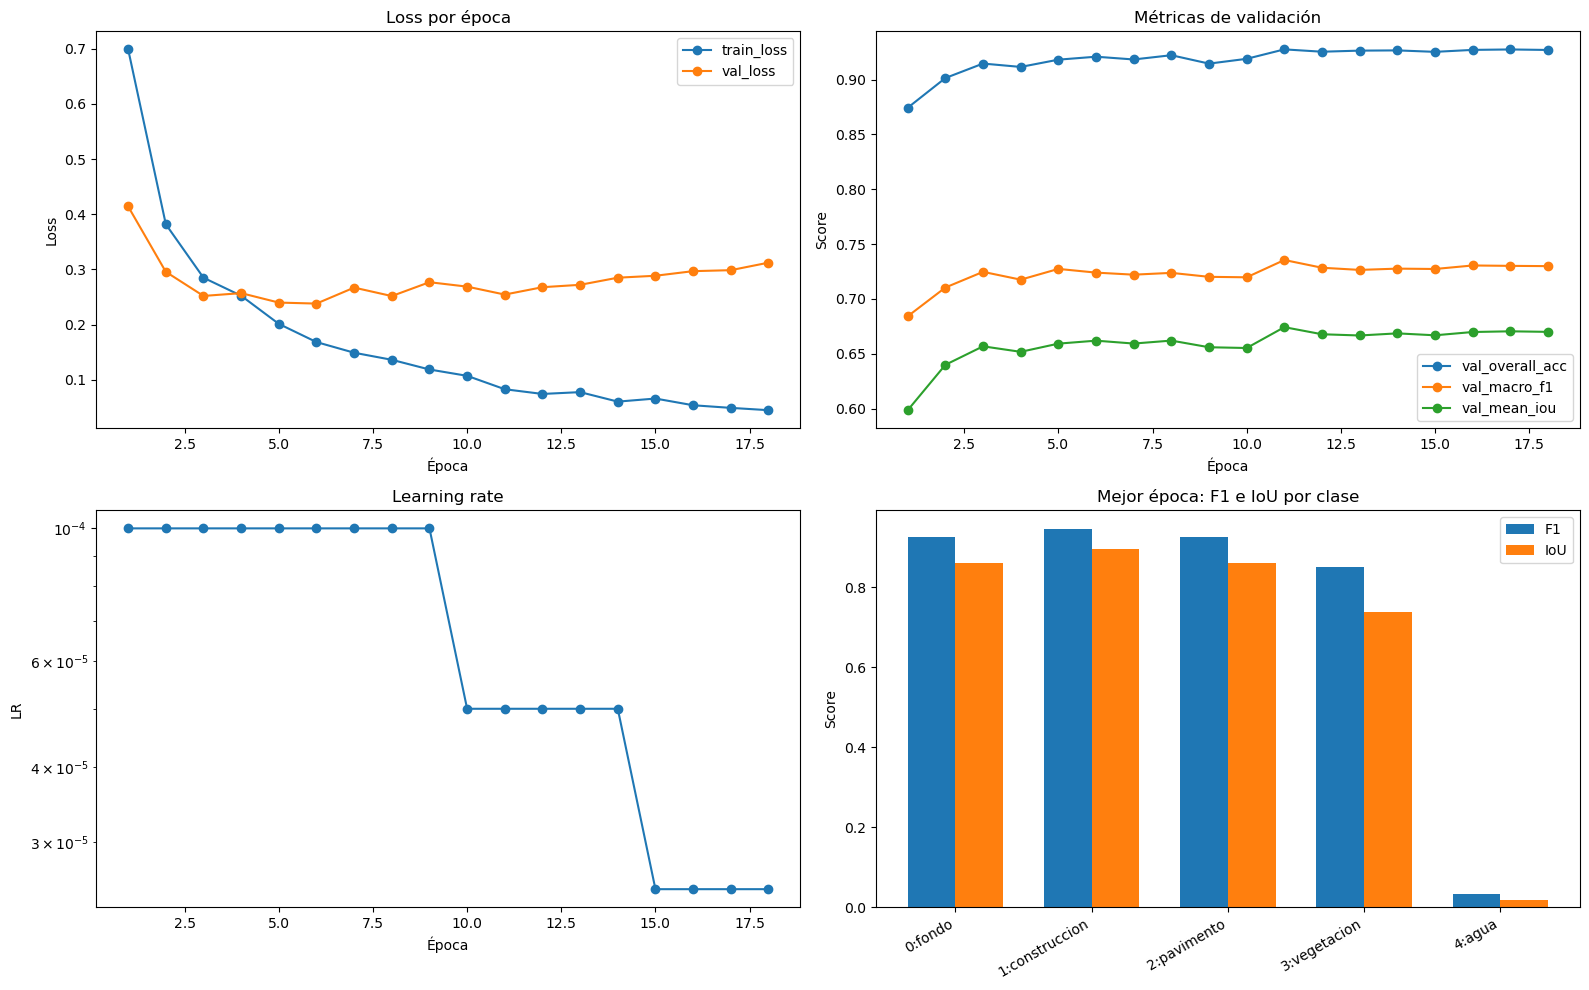

Resumen del mejor checkpoint RGB:
  mejor época      : 11
  mejor métrica    : val_mean_iou
  mejor valor      : 0.674228
  checkpoint       : /home/jovyan/work/datos/DATOS_AJUSTADOS/salidas_dl_v2/fase10_rgb_control/best_rgb_control.pt


In [38]:

# ============================================================
# 10.4 RESUMEN DEL ENTRENAMIENTO RGB Y CURVAS
# ============================================================

if len(rgb_history) == 0:
    raise RuntimeError("No hay histórico de entrenamiento. Ejecuta primero la celda 10.3.")

epochs_axis = [r["epoch"] for r in rgb_history]
train_losses = [r["train_loss"] for r in rgb_history]
val_losses = [r["val_loss"] for r in rgb_history]
val_accs = [r["val_overall_acc"] for r in rgb_history]
val_macro_f1s = [r["val_macro_f1"] for r in rgb_history]
val_mean_ious = [r["val_mean_iou"] for r in rgb_history]
lrs = [r["lr"] for r in rgb_history]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(epochs_axis, train_losses, marker="o", label="train_loss")
axes[0, 0].plot(epochs_axis, val_losses, marker="o", label="val_loss")
axes[0, 0].set_title("Loss por época")
axes[0, 0].set_xlabel("Época")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

axes[0, 1].plot(epochs_axis, val_accs, marker="o", label="val_overall_acc")
axes[0, 1].plot(epochs_axis, val_macro_f1s, marker="o", label="val_macro_f1")
axes[0, 1].plot(epochs_axis, val_mean_ious, marker="o", label="val_mean_iou")
axes[0, 1].set_title("Métricas de validación")
axes[0, 1].set_xlabel("Época")
axes[0, 1].set_ylabel("Score")
axes[0, 1].legend()

axes[1, 0].plot(epochs_axis, lrs, marker="o")
axes[1, 0].set_title("Learning rate")
axes[1, 0].set_xlabel("Época")
axes[1, 0].set_ylabel("LR")
axes[1, 0].set_yscale("log")

if rgb_best_epoch is None:
    best_idx = int(np.argmax(val_mean_ious))
else:
    best_idx = int(np.argmax([1 if r["epoch"] == rgb_best_epoch else 0 for r in rgb_history]))
best_record = rgb_history[best_idx]
class_labels = [f"{c}:{CLASS_MAP[c]}" for c in CLASS_MAP.keys()]
class_f1_values = [best_record["val_per_class"][c]["f1"] for c in CLASS_MAP.keys()]
class_iou_values = [best_record["val_per_class"][c]["iou"] for c in CLASS_MAP.keys()]

x = np.arange(len(class_labels))
bar_w = 0.35
axes[1, 1].bar(x - bar_w / 2, class_f1_values, width=bar_w, label="F1")
axes[1, 1].bar(x + bar_w / 2, class_iou_values, width=bar_w, label="IoU")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(class_labels, rotation=30, ha="right")
axes[1, 1].set_title("Mejor época: F1 e IoU por clase")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Resumen del mejor checkpoint RGB:")
print(f"  mejor época      : {rgb_best_epoch}")
print(f"  mejor métrica    : {RGB_TRAIN_CFG.monitor_metric}")
print(f"  mejor valor      : {rgb_best_metric:.6f}" if rgb_best_metric is not None else "  mejor valor      : None")
print(f"  checkpoint       : {RGB_CHECKPOINT_FP}")


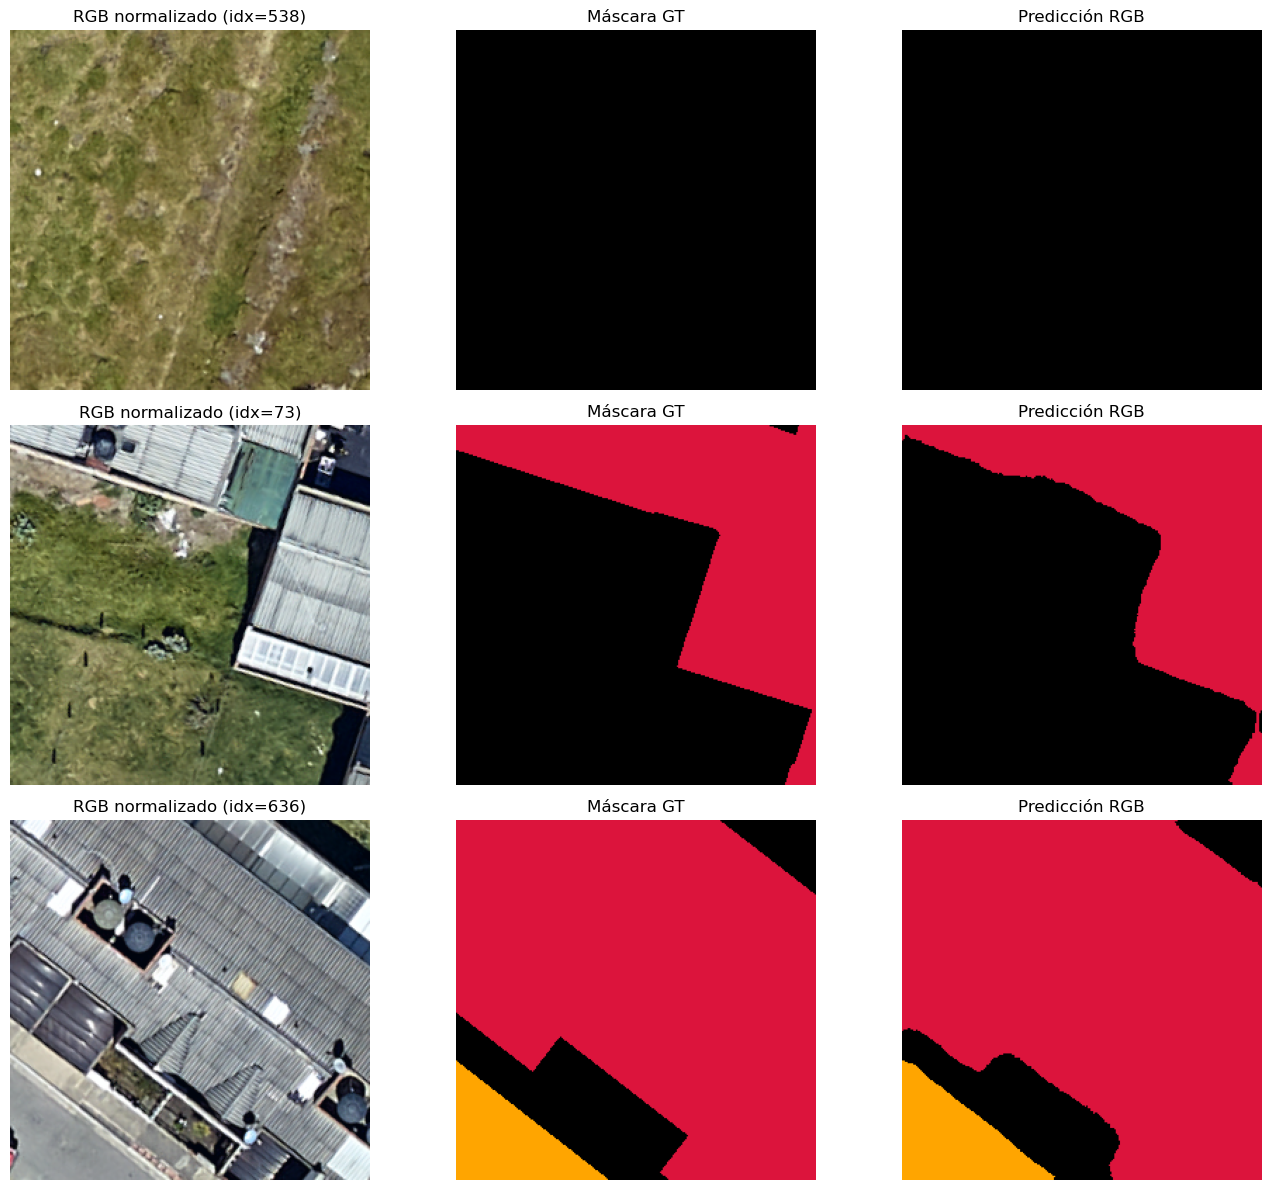

In [39]:

# ============================================================
# 10.5 CARGA DEL MEJOR MODELO RGB Y VISUALIZACIÓN CUALITATIVA
# ============================================================

if not RGB_CHECKPOINT_FP.exists():
    raise FileNotFoundError(
        f"No se encontró el checkpoint esperado: {RGB_CHECKPOINT_FP}. Ejecuta la celda 10.3 primero."
    )

rgb_best_payload = torch.load(RGB_CHECKPOINT_FP, map_location=DEVICE)
rgb_model.load_state_dict(rgb_best_payload["model_state_dict"])
rgb_model.eval()

def colorize_mask(mask_2d: np.ndarray) -> np.ndarray:
    palette = {
        0: (0, 0, 0),         # fondo
        1: (220, 20, 60),     # construccion
        2: (255, 165, 0),     # pavimento
        3: (34, 139, 34),     # vegetacion
        4: (30, 144, 255),    # agua
        IGNORE_INDEX: (255, 255, 255),
    }
    h, w = mask_2d.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, color in palette.items():
        rgb[mask_2d == cls_id] = np.array(color, dtype=np.uint8)
    return rgb

def denormalize_rgb_for_display(x_rgb: np.ndarray, profile: NormalizationProfile) -> np.ndarray:
    low = profile.ortho_low[:3].astype(np.float32).reshape(3, 1, 1)
    high = profile.ortho_high[:3].astype(np.float32).reshape(3, 1, 1)
    arr = np.clip(x_rgb, 0.0, 1.0)
    arr = arr * (high - low) + low
    arr = arr.transpose(1, 2, 0)
    arr = arr - arr.min()
    arr = arr / (arr.max() + 1e-8)
    return arr

def show_rgb_predictions(
    model: nn.Module,
    dataset: Dataset,
    profile: NormalizationProfile,
    device: torch.device,
    n_examples: int = 3,
    seed: int = SEED,
) -> None:
    if len(dataset) == 0:
        raise ValueError("El dataset está vacío; no hay ejemplos que mostrar.")

    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=min(n_examples, len(dataset)), replace=False)

    fig, axes = plt.subplots(len(indices), 3, figsize=(14, 4 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        x_t, y_t = dataset[idx]
        x_b = x_t.unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x_b)
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.int16)

        x_np = x_t.cpu().numpy()
        y_np = y_t.cpu().numpy().astype(np.int16)

        rgb_disp = denormalize_rgb_for_display(x_np, profile)
        y_disp = colorize_mask(y_np)
        pred_disp = colorize_mask(pred)

        axes[row, 0].imshow(rgb_disp)
        axes[row, 0].set_title(f"RGB normalizado (idx={idx})")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(y_disp)
        axes[row, 1].set_title("Máscara GT")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_disp)
        axes[row, 2].set_title("Predicción RGB")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()

show_rgb_predictions(
    model=rgb_model,
    dataset=val_rgb_dataset,
    profile=TRAIN_NORMALIZATION_PROFILE,
    device=DEVICE,
    n_examples=3,
    seed=SEED,
)


## Estado alcanzado hasta fase 10

Queda implementado el entrenamiento del **experimento control RGB** con:

- `AdamW`
- scheduler por validación
- early stopping
- guardado del mejor checkpoint
- métricas por época (`loss`, `accuracy`, `macro F1`, `mean IoU`)
- curvas de entrenamiento
- carga del mejor modelo y visualización cualitativa

El siguiente paso natural es la **fase 11**:
- entrenar el **experimento multifuente**
- reutilizar el mismo esquema de entrenamiento y validación
- dejar lista la comparación directa entre RGB y `RGB + NIR + HEIGHT`


## 11) Entrenamiento del experimento multifuente

En esta fase se entrena el modelo **RGB + NIR + HEIGHT** reutilizando la misma disciplina experimental del baseline RGB, para que la comparación sea justa:

- mismo split espacial
- misma lógica de métricas
- mismo control por scheduler y early stopping
- mismo manejo de `ignore_index`
- mismo esquema de checkpoint e histórico


In [40]:
# ============================================================
# 11.1 CONFIGURACIÓN DE ENTRENAMIENTO Y RUTAS DE SALIDA (MULTIFUENTE)
# ============================================================

from copy import deepcopy
import json
import time

@dataclass(frozen=True)
class MultiSourceTrainingConfig:
    epochs: int = 25
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    grad_clip_norm: float = 1.0
    amp: bool = False  # primero estabilidad; AMP vuelve cuando el entrenamiento sea sano
    early_stopping_patience: int = 7
    scheduler_mode: str = "max"
    scheduler_factor: float = 0.5
    scheduler_patience: int = 3
    scheduler_min_lr: float = 1e-6
    monitor_metric: str = "val_mean_iou"
    monitor_mode: str = "max"

MULTISOURCE_TRAIN_CFG = MultiSourceTrainingConfig()

MULTISOURCE_PHASE_DIR = PATHS.output_dir / "fase11_multisource"
MULTISOURCE_PHASE_DIR.mkdir(parents=True, exist_ok=True)

MULTISOURCE_CHECKPOINT_FP = MULTISOURCE_PHASE_DIR / "best_multisource.pt"
MULTISOURCE_HISTORY_FP = MULTISOURCE_PHASE_DIR / "multisource_training_history.json"

print("Configuración de entrenamiento multifuente:")
print(MULTISOURCE_TRAIN_CFG)
print("Directorio de salida fase 11:", MULTISOURCE_PHASE_DIR)
print("Checkpoint mejor modelo    :", MULTISOURCE_CHECKPOINT_FP)
print("Histórico de entrenamiento :", MULTISOURCE_HISTORY_FP)


Configuración de entrenamiento multifuente:
MultiSourceTrainingConfig(epochs=25, learning_rate=0.0001, weight_decay=0.0001, grad_clip_norm=1.0, amp=False, early_stopping_patience=7, scheduler_mode='max', scheduler_factor=0.5, scheduler_patience=3, scheduler_min_lr=1e-06, monitor_metric='val_mean_iou', monitor_mode='max')
Directorio de salida fase 11: /home/jovyan/work/datos/DATOS_AJUSTADOS/salidas_dl_v2/fase11_multisource
Checkpoint mejor modelo    : /home/jovyan/work/datos/DATOS_AJUSTADOS/salidas_dl_v2/fase11_multisource/best_multisource.pt
Histórico de entrenamiento : /home/jovyan/work/datos/DATOS_AJUSTADOS/salidas_dl_v2/fase11_multisource/multisource_training_history.json


In [41]:
# ============================================================
# 11.2 ENTRENAMIENTO DEL EXPERIMENTO MULTIFUENTE
# ============================================================

import json
import time
from copy import deepcopy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

# ------------------------------------------------------------
# Helpers de serialización robusta
# ------------------------------------------------------------
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, torch.Tensor):
        obj = obj.detach().cpu()
        return obj.item() if obj.ndim == 0 else obj.tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer, np.bool_)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    return obj

def flatten_epoch_record_safe(record: dict) -> dict:
    return {k: make_json_safe(v) for k, v in record.items()}

# ------------------------------------------------------------
# Reconstruir modelo multifuente desde cero
# ------------------------------------------------------------
multisource_model, multisource_pretrain_diagnostics = build_pretrained_unet_multisource(
    MULTISOURCE_MODEL_CFG,
    MULTISOURCE_ADAPT_CFG,
)
multisource_model = multisource_model.to(DEVICE)

multisource_criterion = build_segmentation_loss(
    class_weights=LOSS_CLASS_WEIGHTS,
    ignore_index=IGNORE_INDEX,
    device=DEVICE,
).to(DEVICE)

multisource_optimizer = torch.optim.AdamW(
    multisource_model.parameters(),
    lr=MULTISOURCE_TRAIN_CFG.learning_rate,
    weight_decay=MULTISOURCE_TRAIN_CFG.weight_decay,
)

multisource_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    multisource_optimizer,
    mode=MULTISOURCE_TRAIN_CFG.scheduler_mode,
    factor=MULTISOURCE_TRAIN_CFG.scheduler_factor,
    patience=MULTISOURCE_TRAIN_CFG.scheduler_patience,
    min_lr=MULTISOURCE_TRAIN_CFG.scheduler_min_lr,
)

multisource_history: List[Dict] = []
multisource_best_metric: Optional[float] = None
multisource_best_epoch: Optional[int] = None
multisource_epochs_without_improvement = 0
multisource_training_start = time.time()

# AMP moderno
if DEVICE.type == "cuda":
    multisource_scaler = torch.amp.GradScaler("cuda", enabled=MULTISOURCE_TRAIN_CFG.amp)
    torch.cuda.empty_cache()
else:
    multisource_scaler = None

print("Inicio entrenamiento multifuente...")
print(f"Monitor principal: {MULTISOURCE_TRAIN_CFG.monitor_metric} ({MULTISOURCE_TRAIN_CFG.monitor_mode})")
print("AMP habilitado:", MULTISOURCE_TRAIN_CFG.amp)
print("LR inicial:", MULTISOURCE_TRAIN_CFG.learning_rate)

for epoch in range(1, MULTISOURCE_TRAIN_CFG.epochs + 1):
    epoch_start = time.time()

    train_metrics = run_train_epoch(
        model=multisource_model,
        loader=train_multisource_loader,
        optimizer=multisource_optimizer,
        criterion=multisource_criterion,
        device=DEVICE,
        ignore_index=IGNORE_INDEX,
        use_amp=MULTISOURCE_TRAIN_CFG.amp,
        scaler=multisource_scaler,
        grad_clip_norm=MULTISOURCE_TRAIN_CFG.grad_clip_norm,
    )

    val_metrics = run_eval_epoch(
        model=multisource_model,
        loader=val_multisource_loader,
        criterion=multisource_criterion,
        device=DEVICE,
        num_classes=MODEL_NUM_CLASSES,
        class_map=CLASS_MAP,
        ignore_index=IGNORE_INDEX,
        use_amp=MULTISOURCE_TRAIN_CFG.amp,
    )

    current_monitor = (
        val_metrics["loss"]
        if MULTISOURCE_TRAIN_CFG.monitor_metric == "val_loss"
        else val_metrics[MULTISOURCE_TRAIN_CFG.monitor_metric.replace("val_", "")]
    )

    if not np.isfinite(current_monitor):
        raise RuntimeError(
            f"La métrica monitor ({MULTISOURCE_TRAIN_CFG.monitor_metric}) no es finita en la época {epoch}."
        )

    multisource_scheduler.step(current_monitor)

    improved = is_better_metric(
        current=float(current_monitor),
        best=multisource_best_metric,
        mode=MULTISOURCE_TRAIN_CFG.monitor_mode,
    )

    epoch_record = {
        "epoch": int(epoch),
        "lr": float(get_current_lr(multisource_optimizer)),
        "epoch_seconds": float(time.time() - epoch_start),
        "train_loss": float(train_metrics["loss"]),
        "train_steps": int(train_metrics["steps"]),
        "train_valid_pixels": int(train_metrics["valid_pixels"]),
        "train_skipped_batches": int(train_metrics["skipped_batches"]),
        "val_loss": float(val_metrics["loss"]),
        "val_overall_acc": float(val_metrics["overall_acc"]),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "val_mean_iou": float(val_metrics["mean_iou"]),
        "val_steps": int(val_metrics["steps"]),
        "val_valid_pixels": int(val_metrics["valid_pixels"]),
        "val_skipped_batches": int(val_metrics["skipped_batches"]),
        "val_per_class": val_metrics["per_class"],
        "val_confusion_matrix": val_metrics["confusion_matrix"],
    }
    multisource_history.append(epoch_record)

    print(
        f"[Epoch {epoch:02d}/{MULTISOURCE_TRAIN_CFG.epochs:02d}] "
        f"train_loss={epoch_record['train_loss']:.6f} | "
        f"val_loss={epoch_record['val_loss']:.6f} | "
        f"val_acc={epoch_record['val_overall_acc']:.4f} | "
        f"val_macro_f1={epoch_record['val_macro_f1']:.4f} | "
        f"val_mean_iou={epoch_record['val_mean_iou']:.4f} | "
        f"train_skip={epoch_record['train_skipped_batches']} | "
        f"val_skip={epoch_record['val_skipped_batches']} | "
        f"lr={epoch_record['lr']:.2e}"
    )

    if improved:
        multisource_best_metric = float(current_monitor)
        multisource_best_epoch = int(epoch)
        multisource_epochs_without_improvement = 0

        checkpoint_payload = {
            "epoch": int(epoch),
            "model_state_dict": deepcopy(multisource_model.state_dict()),
            "optimizer_state_dict": deepcopy(multisource_optimizer.state_dict()),
            "scheduler_state_dict": deepcopy(multisource_scheduler.state_dict()),
            "best_metric_name": str(MULTISOURCE_TRAIN_CFG.monitor_metric),
            "best_metric_value": float(multisource_best_metric),
            "training_config": make_json_safe(asdict(MULTISOURCE_TRAIN_CFG)),
            "multisource_model_config": make_json_safe(asdict(MULTISOURCE_MODEL_CFG)),
            "multisource_adapt_config": make_json_safe(asdict(MULTISOURCE_ADAPT_CFG)),
            "normalization_profile": make_json_safe(TRAIN_NORMALIZATION_PROFILE.to_dict()),
            "class_map": make_json_safe(CLASS_MAP),
            "pretrain_diagnostics": make_json_safe(multisource_pretrain_diagnostics),
            "history": [
                {
                    "epoch": int(r["epoch"]),
                    "lr": float(r["lr"]),
                    "epoch_seconds": float(r["epoch_seconds"]),
                    "train_loss": float(r["train_loss"]),
                    "train_steps": int(r["train_steps"]),
                    "train_valid_pixels": int(r["train_valid_pixels"]),
                    "train_skipped_batches": int(r["train_skipped_batches"]),
                    "val_loss": float(r["val_loss"]),
                    "val_overall_acc": float(r["val_overall_acc"]),
                    "val_macro_f1": float(r["val_macro_f1"]),
                    "val_mean_iou": float(r["val_mean_iou"]),
                    "val_steps": int(r["val_steps"]),
                    "val_valid_pixels": int(r["val_valid_pixels"]),
                    "val_skipped_batches": int(r["val_skipped_batches"]),
                }
                for r in multisource_history
            ],
        }
        torch.save(checkpoint_payload, MULTISOURCE_CHECKPOINT_FP)
    else:
        multisource_epochs_without_improvement += 1

    if multisource_epochs_without_improvement >= MULTISOURCE_TRAIN_CFG.early_stopping_patience:
        print(f"Early stopping multifuente activado en la época {epoch}.")
        break

multisource_total_minutes = (time.time() - multisource_training_start) / 60.0
print("\nEntrenamiento multifuente finalizado.")
print(f"  mejor época       : {multisource_best_epoch}")
print(f"  mejor métrica     : {multisource_best_metric}")
print(f"  tiempo total (min): {multisource_total_minutes:.2f}")

# ------------------------------------------------------------
# Guardado robusto del histórico multifuente
# ------------------------------------------------------------
multisource_history_safe = [flatten_epoch_record_safe(r) for r in multisource_history]

with open(MULTISOURCE_HISTORY_FP, "w", encoding="utf-8") as f:
    json.dump(multisource_history_safe, f, ensure_ascii=False, indent=2)

print(f"Histórico multifuente guardado en: {MULTISOURCE_HISTORY_FP}")

Inicio entrenamiento multifuente...
Monitor principal: val_mean_iou (max)
AMP habilitado: False
LR inicial: 0.0001
[Epoch 01/25] train_loss=0.661939 | val_loss=0.250677 | val_acc=0.9226 | val_macro_f1=0.7218 | val_mean_iou=0.6601 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 02/25] train_loss=0.324120 | val_loss=0.229640 | val_acc=0.9205 | val_macro_f1=0.7231 | val_mean_iou=0.6616 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 03/25] train_loss=0.244390 | val_loss=0.199411 | val_acc=0.9320 | val_macro_f1=0.7335 | val_mean_iou=0.6770 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 04/25] train_loss=0.207309 | val_loss=0.196429 | val_acc=0.9336 | val_macro_f1=0.7330 | val_mean_iou=0.6771 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 05/25] train_loss=0.174196 | val_loss=0.196638 | val_acc=0.9346 | val_macro_f1=0.7329 | val_mean_iou=0.6783 | train_skip=0 | val_skip=0 | lr=1.00e-04
[Epoch 06/25] train_loss=0.145393 | val_loss=0.202233 | val_acc=0.9368 | val_macro_f1=0.7338 | val_m

In [42]:
"""
# ============================================================
# 11.2 ENTRENAMIENTO DEL EXPERIMENTO MULTIFUENTE
# ============================================================

# Reconstruir el modelo multifuente desde cero para asegurar una corrida limpia.
multisource_model, multisource_pretrain_diagnostics = build_pretrained_unet_multisource(
    MULTISOURCE_MODEL_CFG,
    MULTISOURCE_ADAPT_CFG,
)
multisource_model = multisource_model.to(DEVICE)

multisource_criterion = build_segmentation_loss(
    class_weights=LOSS_CLASS_WEIGHTS,
    ignore_index=IGNORE_INDEX,
    device=DEVICE,
).to(DEVICE)

multisource_optimizer = torch.optim.AdamW(
    multisource_model.parameters(),
    lr=MULTISOURCE_TRAIN_CFG.learning_rate,
    weight_decay=MULTISOURCE_TRAIN_CFG.weight_decay,
)

multisource_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    multisource_optimizer,
    mode=MULTISOURCE_TRAIN_CFG.scheduler_mode,
    factor=MULTISOURCE_TRAIN_CFG.scheduler_factor,
    patience=MULTISOURCE_TRAIN_CFG.scheduler_patience,
    min_lr=MULTISOURCE_TRAIN_CFG.scheduler_min_lr,
)

multisource_history: List[Dict] = []
multisource_best_metric: Optional[float] = None
multisource_best_epoch: Optional[int] = None
multisource_epochs_without_improvement = 0
multisource_training_start = time.time()

if DEVICE.type == "cuda":
    multisource_scaler = torch.amp.GradScaler("cuda", enabled=MULTISOURCE_TRAIN_CFG.amp)
    torch.cuda.empty_cache()
else:
    multisource_scaler = None

print("Inicio entrenamiento multifuente...")
print(f"Monitor principal: {MULTISOURCE_TRAIN_CFG.monitor_metric} ({MULTISOURCE_TRAIN_CFG.monitor_mode})")
print("AMP habilitado:", MULTISOURCE_TRAIN_CFG.amp)
print("LR inicial:", MULTISOURCE_TRAIN_CFG.learning_rate)

for epoch in range(1, MULTISOURCE_TRAIN_CFG.epochs + 1):
    epoch_start = time.time()

    train_metrics = run_train_epoch(
        model=multisource_model,
        loader=train_multisource_loader,
        optimizer=multisource_optimizer,
        criterion=multisource_criterion,
        device=DEVICE,
        ignore_index=IGNORE_INDEX,
        use_amp=MULTISOURCE_TRAIN_CFG.amp,
        scaler=multisource_scaler,
        grad_clip_norm=MULTISOURCE_TRAIN_CFG.grad_clip_norm,
    )

    val_metrics = run_eval_epoch(
        model=multisource_model,
        loader=val_multisource_loader,
        criterion=multisource_criterion,
        device=DEVICE,
        num_classes=MODEL_NUM_CLASSES,
        class_map=CLASS_MAP,
        ignore_index=IGNORE_INDEX,
        use_amp=MULTISOURCE_TRAIN_CFG.amp,
    )

    current_monitor = (
        val_metrics["loss"]
        if MULTISOURCE_TRAIN_CFG.monitor_metric == "val_loss"
        else val_metrics[MULTISOURCE_TRAIN_CFG.monitor_metric.replace("val_", "")]
    )

    if not np.isfinite(current_monitor):
        raise RuntimeError(
            f"La métrica monitor ({MULTISOURCE_TRAIN_CFG.monitor_metric}) no es finita en la época {epoch}."
        )

    multisource_scheduler.step(current_monitor)

    improved = is_better_metric(
        current=float(current_monitor),
        best=multisource_best_metric,
        mode=MULTISOURCE_TRAIN_CFG.monitor_mode,
    )

    epoch_record = {
        "epoch": epoch,
        "lr": get_current_lr(multisource_optimizer),
        "epoch_seconds": float(time.time() - epoch_start),
        "train_loss": train_metrics["loss"],
        "train_steps": train_metrics["steps"],
        "train_valid_pixels": train_metrics["valid_pixels"],
        "train_skipped_batches": train_metrics["skipped_batches"],
        "val_loss": val_metrics["loss"],
        "val_overall_acc": val_metrics["overall_acc"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_mean_iou": val_metrics["mean_iou"],
        "val_steps": val_metrics["steps"],
        "val_valid_pixels": val_metrics["valid_pixels"],
        "val_skipped_batches": val_metrics["skipped_batches"],
        "val_per_class": val_metrics["per_class"],
        "val_confusion_matrix": val_metrics["confusion_matrix"],
    }
    multisource_history.append(epoch_record)

    print(
        f"[Epoch {epoch:02d}/{MULTISOURCE_TRAIN_CFG.epochs:02d}] "
        f"train_loss={epoch_record['train_loss']:.6f} | "
        f"val_loss={epoch_record['val_loss']:.6f} | "
        f"val_acc={epoch_record['val_overall_acc']:.4f} | "
        f"val_macro_f1={epoch_record['val_macro_f1']:.4f} | "
        f"val_mean_iou={epoch_record['val_mean_iou']:.4f} | "
        f"train_skip={epoch_record['train_skipped_batches']} | "
        f"val_skip={epoch_record['val_skipped_batches']} | "
        f"lr={epoch_record['lr']:.2e}"
    )

    if improved:
        multisource_best_metric = float(current_monitor)
        multisource_best_epoch = int(epoch)
        multisource_epochs_without_improvement = 0

        checkpoint_payload = {
            "epoch": epoch,
            "model_state_dict": deepcopy(multisource_model.state_dict()),
            "optimizer_state_dict": deepcopy(multisource_optimizer.state_dict()),
            "scheduler_state_dict": deepcopy(multisource_scheduler.state_dict()),
            "best_metric_name": MULTISOURCE_TRAIN_CFG.monitor_metric,
            "best_metric_value": multisource_best_metric,
            "training_config": asdict(MULTISOURCE_TRAIN_CFG),
            "multisource_model_config": asdict(MULTISOURCE_MODEL_CFG),
            "multisource_adapt_config": asdict(MULTISOURCE_ADAPT_CFG),
            "normalization_profile": TRAIN_NORMALIZATION_PROFILE.to_dict(),
            "class_map": CLASS_MAP,
            "history": [
                {
                    "epoch": r["epoch"],
                    "lr": r["lr"],
                    "epoch_seconds": r["epoch_seconds"],
                    "train_loss": r["train_loss"],
                    "train_steps": r["train_steps"],
                    "train_valid_pixels": r["train_valid_pixels"],
                    "train_skipped_batches": r["train_skipped_batches"],
                    "val_loss": r["val_loss"],
                    "val_overall_acc": r["val_overall_acc"],
                    "val_macro_f1": r["val_macro_f1"],
                    "val_mean_iou": r["val_mean_iou"],
                    "val_steps": r["val_steps"],
                    "val_valid_pixels": r["val_valid_pixels"],
                    "val_skipped_batches": r["val_skipped_batches"],
                }
                for r in multisource_history
            ],
        }
        torch.save(checkpoint_payload, MULTISOURCE_CHECKPOINT_FP)
    else:
        multisource_epochs_without_improvement += 1

    if multisource_epochs_without_improvement >= MULTISOURCE_TRAIN_CFG.early_stopping_patience:
        print(f"Early stopping multifuente activado en la época {epoch}.")
        break

multisource_total_minutes = (time.time() - multisource_training_start) / 60.0
print("\nEntrenamiento multifuente finalizado.")
print(f"  mejor época       : {multisource_best_epoch}")
print(f"  mejor métrica     : {multisource_best_metric}")
print(f"  tiempo total (min): {multisource_total_minutes:.2f}")

with open(MULTISOURCE_HISTORY_FP, "w", encoding="utf-8") as f:
    json.dump([flatten_epoch_record(r) for r in multisource_history], f, ensure_ascii=False, indent=2)

print(f"Histórico multifuente guardado en: {MULTISOURCE_HISTORY_FP}")
"""


'\n# ============================================================\n# 11.2 ENTRENAMIENTO DEL EXPERIMENTO MULTIFUENTE\n# ============================================================\n\n# Reconstruir el modelo multifuente desde cero para asegurar una corrida limpia.\nmultisource_model, multisource_pretrain_diagnostics = build_pretrained_unet_multisource(\n    MULTISOURCE_MODEL_CFG,\n    MULTISOURCE_ADAPT_CFG,\n)\nmultisource_model = multisource_model.to(DEVICE)\n\nmultisource_criterion = build_segmentation_loss(\n    class_weights=LOSS_CLASS_WEIGHTS,\n    ignore_index=IGNORE_INDEX,\n    device=DEVICE,\n).to(DEVICE)\n\nmultisource_optimizer = torch.optim.AdamW(\n    multisource_model.parameters(),\n    lr=MULTISOURCE_TRAIN_CFG.learning_rate,\n    weight_decay=MULTISOURCE_TRAIN_CFG.weight_decay,\n)\n\nmultisource_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(\n    multisource_optimizer,\n    mode=MULTISOURCE_TRAIN_CFG.scheduler_mode,\n    factor=MULTISOURCE_TRAIN_CFG.scheduler_fact

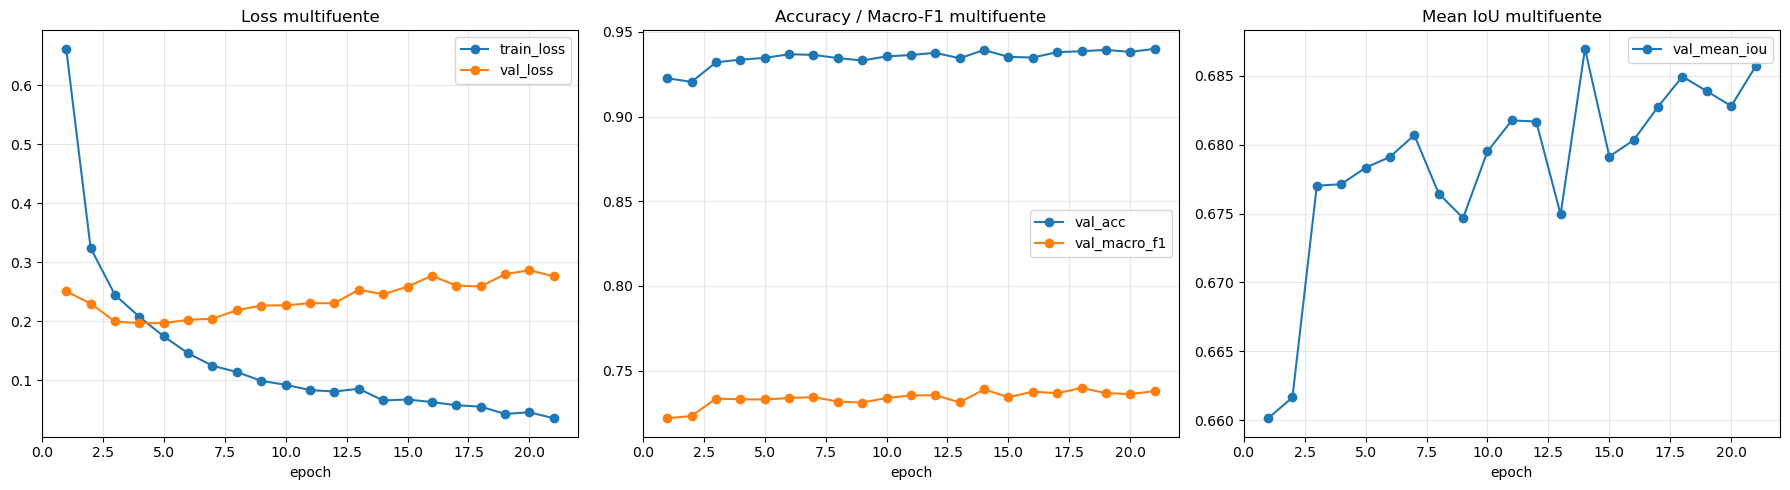

Resumen del mejor checkpoint multifuente:
  mejor época      : 14
  mejor métrica    : val_mean_iou
  mejor valor      : 0.686959
  checkpoint       : /home/jovyan/work/datos/DATOS_AJUSTADOS/salidas_dl_v2/fase11_multisource/best_multisource.pt


In [43]:
# ============================================================
# 11.3 RESUMEN DEL ENTRENAMIENTO MULTIFUENTE Y CURVAS
# ============================================================

if len(multisource_history) == 0:
    raise RuntimeError("No hay histórico de entrenamiento multifuente. Ejecuta primero la celda 11.2.")

epochs_axis = [r["epoch"] for r in multisource_history]
train_losses = [r["train_loss"] for r in multisource_history]
val_losses = [r["val_loss"] for r in multisource_history]
val_accs = [r["val_overall_acc"] for r in multisource_history]
val_f1s = [r["val_macro_f1"] for r in multisource_history]
val_ious = [r["val_mean_iou"] for r in multisource_history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_axis, train_losses, marker='o', label='train_loss')
axes[0].plot(epochs_axis, val_losses, marker='o', label='val_loss')
axes[0].set_title('Loss multifuente')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_axis, val_accs, marker='o', label='val_acc')
axes[1].plot(epochs_axis, val_f1s, marker='o', label='val_macro_f1')
axes[1].set_title('Accuracy / Macro-F1 multifuente')
axes[1].set_xlabel('epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_axis, val_ious, marker='o', label='val_mean_iou')
axes[2].set_title('Mean IoU multifuente')
axes[2].set_xlabel('epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Resumen del mejor checkpoint multifuente:")
print(f"  mejor época      : {multisource_best_epoch}")
print(f"  mejor métrica    : {MULTISOURCE_TRAIN_CFG.monitor_metric}")
print(f"  mejor valor      : {multisource_best_metric:.6f}" if multisource_best_metric is not None else "  mejor valor      : None")
print(f"  checkpoint       : {MULTISOURCE_CHECKPOINT_FP}")


Checkpoint multifuente cargado correctamente.
  epoch            : 14
  best metric name : val_mean_iou
  best metric value: 0.6869589546531112


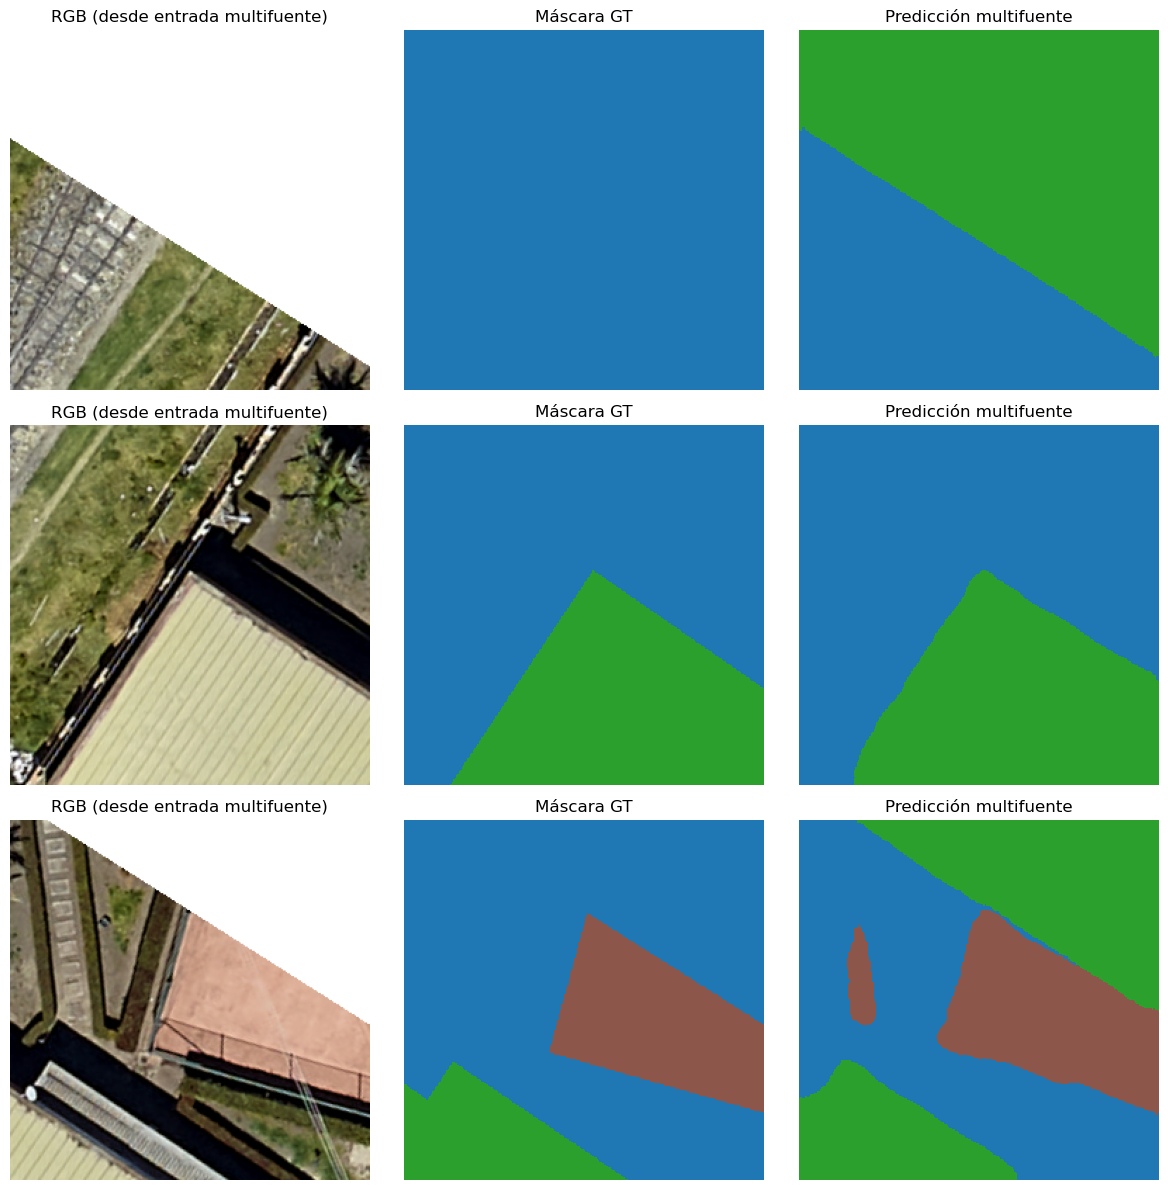

In [44]:
# ============================================================
# 11.4 CARGA DEL MEJOR MODELO MULTIFUENTE Y VISUALIZACIÓN CUALITATIVA
# ============================================================

if not MULTISOURCE_CHECKPOINT_FP.exists():
    raise FileNotFoundError(
        f"No se encontró el checkpoint esperado: {MULTISOURCE_CHECKPOINT_FP}. Ejecuta la celda 11.2 primero."
    )

multisource_best_payload = torch.load(MULTISOURCE_CHECKPOINT_FP, map_location=DEVICE)
multisource_model.load_state_dict(multisource_best_payload["model_state_dict"])
multisource_model.eval()

print("Checkpoint multifuente cargado correctamente.")
print("  epoch            :", multisource_best_payload.get("epoch"))
print("  best metric name :", multisource_best_payload.get("best_metric_name"))
print("  best metric value:", multisource_best_payload.get("best_metric_value"))

def decode_class_colors(mask: np.ndarray, num_classes: int) -> np.ndarray:
    cmap = plt.get_cmap("tab10", num_classes)
    color = cmap(np.clip(mask, 0, num_classes - 1))[:, :, :3]
    return color

@torch.no_grad()
def visualize_multisource_predictions(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    max_items: int = 3,
) -> None:
    batch_x, batch_y = next(iter(loader))
    batch_x = batch_x.to(device)
    logits = model(batch_x)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

    x_np = batch_x.cpu().numpy()
    y_np = batch_y.numpy()

    n = min(max_items, x_np.shape[0])
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        rgb = np.transpose(x_np[i][:3], (1, 2, 0))
        rgb = np.clip(rgb, 0.0, 1.0)
        gt = y_np[i].copy()
        pred = preds[i].copy()

        gt_vis = gt.copy()
        gt_vis[gt_vis == IGNORE_INDEX] = 0
        pred_vis = pred.copy()

        axes[i, 0].imshow(rgb)
        axes[i, 0].set_title("RGB (desde entrada multifuente)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_class_colors(gt_vis, MODEL_NUM_CLASSES), interpolation="nearest")
        axes[i, 1].set_title("Máscara GT")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_class_colors(pred_vis, MODEL_NUM_CLASSES), interpolation="nearest")
        axes[i, 2].set_title("Predicción multifuente")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

visualize_multisource_predictions(multisource_model, val_multisource_loader, DEVICE, max_items=3)


## 12) Evaluación y comparación RGB vs multifuente

Este bloque resume de forma comparable ambos experimentos usando la misma métrica principal (`val_mean_iou`) y sus métricas asociadas.


In [45]:
# ============================================================
# 12.1 COMPARACIÓN DE RESULTADOS RGB VS MULTIFUENTE
# ============================================================

def _best_record_from_history(history: List[Dict], key: str = "val_mean_iou") -> Dict:
    if len(history) == 0:
        raise ValueError("El histórico está vacío.")

    finite_idx = [i for i, r in enumerate(history) if np.isfinite(float(r.get(key, np.nan)))]
    if len(finite_idx) == 0:
        raise ValueError(f"No hay valores finitos para la métrica '{key}' en el histórico.")

    scores = [float(history[i][key]) for i in finite_idx]
    best_local = int(np.argmax(scores))
    return history[finite_idx[best_local]]

rgb_best_record = _best_record_from_history(rgb_history, key="val_mean_iou") if len(rgb_history) > 0 else None
multisource_best_record = _best_record_from_history(multisource_history, key="val_mean_iou") if len(multisource_history) > 0 else None

comparison_rows = []
if rgb_best_record is not None:
    comparison_rows.append({
        "experimento": "RGB control",
        "best_epoch": rgb_best_record["epoch"],
        "val_loss": rgb_best_record["val_loss"],
        "val_acc": rgb_best_record["val_overall_acc"],
        "val_macro_f1": rgb_best_record["val_macro_f1"],
        "val_mean_iou": rgb_best_record["val_mean_iou"],
    })
if multisource_best_record is not None:
    comparison_rows.append({
        "experimento": "RGB+NIR+HEIGHT",
        "best_epoch": multisource_best_record["epoch"],
        "val_loss": multisource_best_record["val_loss"],
        "val_acc": multisource_best_record["val_overall_acc"],
        "val_macro_f1": multisource_best_record["val_macro_f1"],
        "val_mean_iou": multisource_best_record["val_mean_iou"],
    })

import pandas as pd
comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,experimento,best_epoch,val_loss,val_acc,val_macro_f1,val_mean_iou
0,RGB control,11,0.254346,0.927499,0.735461,0.674228
1,RGB+NIR+HEIGHT,14,0.245608,0.939322,0.738886,0.686959


Mejor época RGB        : 11 | val_mean_iou = 0.6742276399366198
Mejor época multifuente: 14 | val_mean_iou = 0.6869589546531112


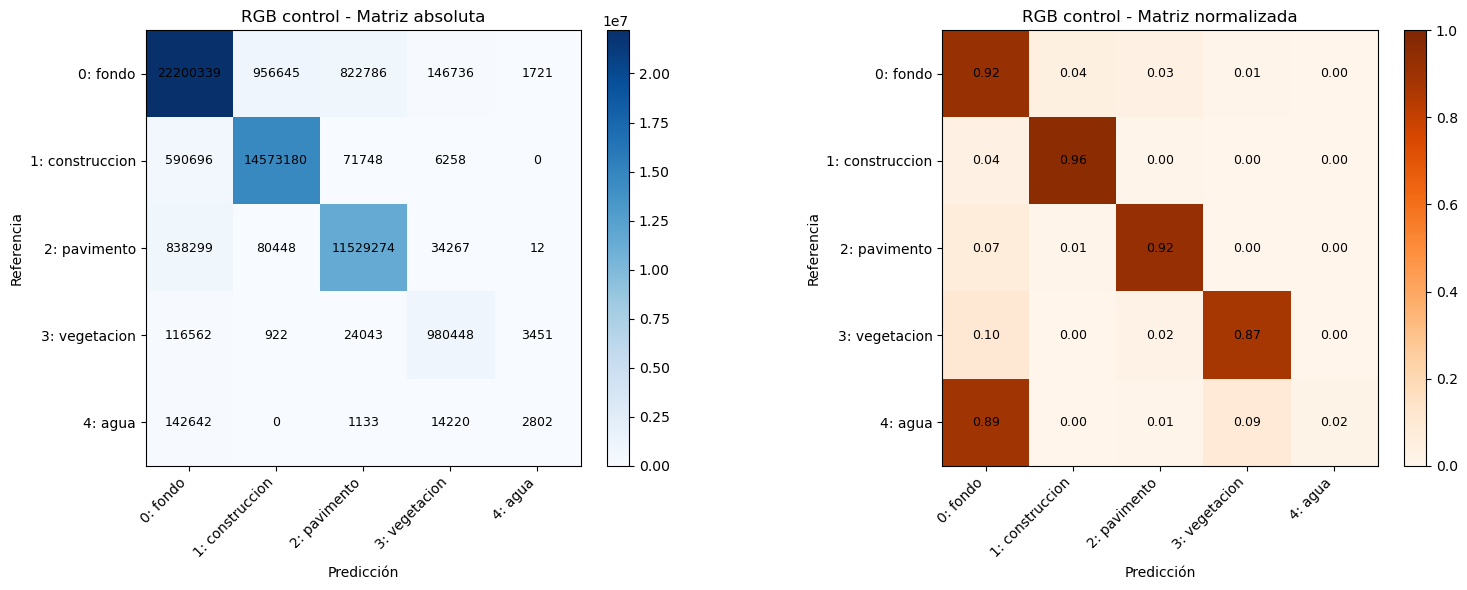

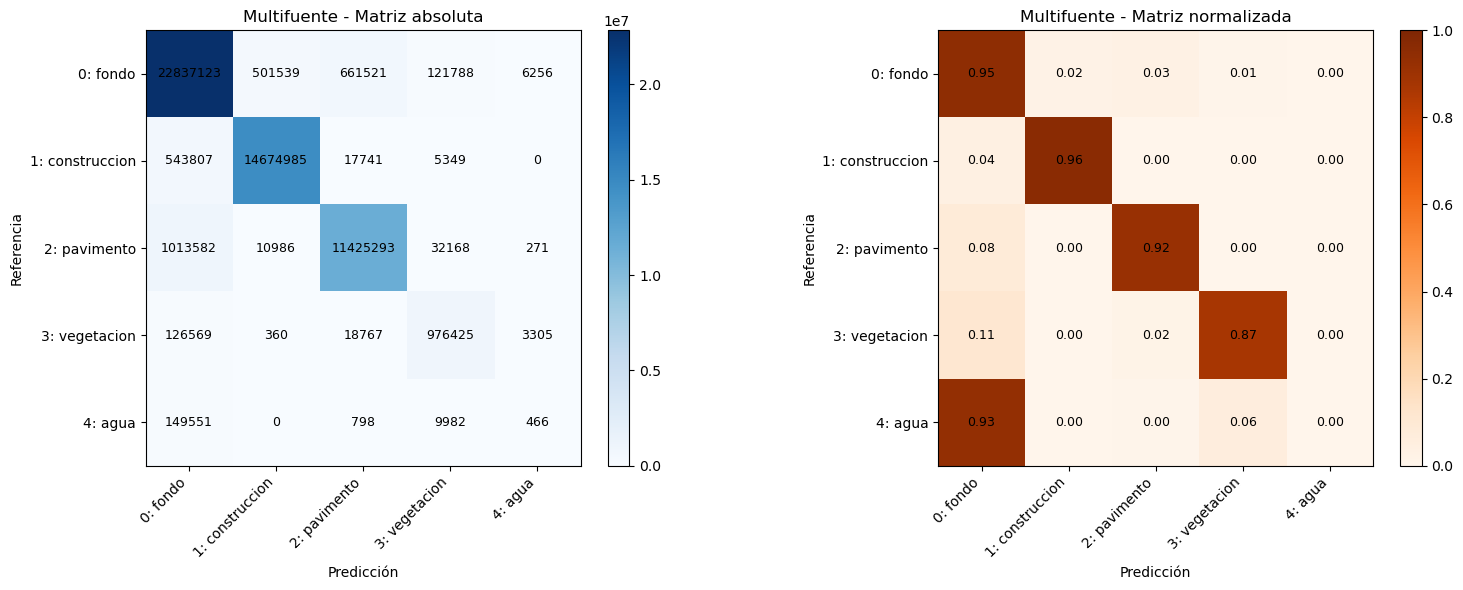


Resumen de confusiones RGB:
Top 10 confusiones:
01. Real=0:fondo -> Pred=1:construccion | píxeles=956645
02. Real=2:pavimento -> Pred=0:fondo | píxeles=838299
03. Real=0:fondo -> Pred=2:pavimento | píxeles=822786
04. Real=1:construccion -> Pred=0:fondo | píxeles=590696
05. Real=0:fondo -> Pred=3:vegetacion | píxeles=146736
06. Real=4:agua -> Pred=0:fondo | píxeles=142642
07. Real=3:vegetacion -> Pred=0:fondo | píxeles=116562
08. Real=2:pavimento -> Pred=1:construccion | píxeles=80448
09. Real=1:construccion -> Pred=2:pavimento | píxeles=71748
10. Real=2:pavimento -> Pred=3:vegetacion | píxeles=34267

Resumen de confusiones multifuente:
Top 10 confusiones:
01. Real=2:pavimento -> Pred=0:fondo | píxeles=1013582
02. Real=0:fondo -> Pred=2:pavimento | píxeles=661521
03. Real=1:construccion -> Pred=0:fondo | píxeles=543807
04. Real=0:fondo -> Pred=1:construccion | píxeles=501539
05. Real=4:agua -> Pred=0:fondo | píxeles=149551
06. Real=3:vegetacion -> Pred=0:fondo | píxeles=126569
07. Real

In [46]:
# ============================================================
# 13.1 ANÁLISIS DE CONFUSIÓN Y ERRORES CLAVE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def _extract_confusion_matrix(record: dict) -> np.ndarray:
    cm = record.get("val_confusion_matrix", None)
    if cm is None:
        raise ValueError("El registro no contiene 'val_confusion_matrix'.")
    return np.asarray(cm, dtype=np.float64)

def _normalize_confusion_matrix(cm: np.ndarray) -> np.ndarray:
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return cm / row_sum

def _class_labels_from_map(class_map: dict) -> list:
    labels = []
    for idx in range(MODEL_NUM_CLASSES):
        if idx in class_map:
            labels.append(f"{idx}: {class_map[idx]}")
        elif str(idx) in class_map:
            labels.append(f"{idx}: {class_map[str(idx)]}")
        else:
            labels.append(f"{idx}")
    return labels

def plot_confusion_matrix_from_record(record: dict, title: str, class_map: dict):
    cm = _extract_confusion_matrix(record)
    cm_norm = _normalize_confusion_matrix(cm)
    labels = _class_labels_from_map(class_map)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Matriz absoluta
    im0 = axes[0].imshow(cm, interpolation="nearest", cmap="Blues")
    axes[0].set_title(f"{title} - Matriz absoluta")
    axes[0].set_xlabel("Predicción")
    axes[0].set_ylabel("Referencia")
    axes[0].set_xticks(np.arange(len(labels)))
    axes[0].set_yticks(np.arange(len(labels)))
    axes[0].set_xticklabels(labels, rotation=45, ha="right")
    axes[0].set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(
                j, i, f"{int(cm[i, j])}",
                ha="center", va="center", fontsize=9
            )

    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # Matriz normalizada por fila
    im1 = axes[1].imshow(cm_norm, interpolation="nearest", cmap="Oranges", vmin=0.0, vmax=1.0)
    axes[1].set_title(f"{title} - Matriz normalizada")
    axes[1].set_xlabel("Predicción")
    axes[1].set_ylabel("Referencia")
    axes[1].set_xticks(np.arange(len(labels)))
    axes[1].set_yticks(np.arange(len(labels)))
    axes[1].set_xticklabels(labels, rotation=45, ha="right")
    axes[1].set_yticklabels(labels)

    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            axes[1].text(
                j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center", fontsize=9
            )

    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def summarize_top_confusions(record: dict, class_map: dict, top_k: int = 10):
    cm = _extract_confusion_matrix(record).copy()
    np.fill_diagonal(cm, 0)

    pairs = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                true_name = class_map.get(i, class_map.get(str(i), str(i)))
                pred_name = class_map.get(j, class_map.get(str(j), str(j)))
                pairs.append((cm[i, j], i, j, true_name, pred_name))

    pairs = sorted(pairs, key=lambda x: x[0], reverse=True)

    print(f"Top {min(top_k, len(pairs))} confusiones:")
    for rank, (count, i, j, true_name, pred_name) in enumerate(pairs[:top_k], start=1):
        print(f"{rank:02d}. Real={i}:{true_name} -> Pred={j}:{pred_name} | píxeles={int(count)}")

# ------------------------------------------------------------
# Elegir mejor registro RGB y multifuente
# ------------------------------------------------------------
if len(rgb_history) == 0:
    raise ValueError("rgb_history está vacío.")
if len(multisource_history) == 0:
    raise ValueError("multisource_history está vacío.")

rgb_best_record = max(rgb_history, key=lambda r: float(r["val_mean_iou"]))
multisource_best_record = max(multisource_history, key=lambda r: float(r["val_mean_iou"]))

print("Mejor época RGB        :", rgb_best_record["epoch"], "| val_mean_iou =", float(rgb_best_record["val_mean_iou"]))
print("Mejor época multifuente:", multisource_best_record["epoch"], "| val_mean_iou =", float(multisource_best_record["val_mean_iou"]))

plot_confusion_matrix_from_record(
    rgb_best_record,
    title="RGB control",
    class_map=CLASS_MAP,
)

plot_confusion_matrix_from_record(
    multisource_best_record,
    title="Multifuente",
    class_map=CLASS_MAP,
)

print("\nResumen de confusiones RGB:")
summarize_top_confusions(rgb_best_record, CLASS_MAP, top_k=10)

print("\nResumen de confusiones multifuente:")
summarize_top_confusions(multisource_best_record, CLASS_MAP, top_k=10)

## 14) Conclusión técnica provisional

Usa los resultados de las celdas 12 y 13 para decidir si el experimento multifuente mejora realmente al RGB. Si el RGB sigue con `NaN` en entrenamiento o métricas congeladas, no debe considerarse baseline válido hasta corregirlo.


In [47]:
!pip install codecarbon

In [48]:
from codecarbon import EmissionsTracker
import time

/opt/conda/envs/sara_semseg/lib/python3.11/site-packages/codecarbon/input.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [49]:
from codecarbon import EmissionsTracker
import time

rgb_tracker = EmissionsTracker(
    project_name="unet_rgb_control",
    output_dir="./codecarbon",
    output_file="codecarbon_rgb.csv",
    log_level="error"
)

rgb_tracker.start()
rgb_wallclock_start = time.time()

print("Inicio entrenamiento RGB control...")
print(f"Monitor principal: {RGB_TRAIN_CFG.monitor_metric} ({RGB_TRAIN_CFG.monitor_mode})")
print("AMP habilitado:", RGB_TRAIN_CFG.amp)
print("LR inicial:", RGB_TRAIN_CFG.learning_rate)

for epoch in range(1, RGB_TRAIN_CFG.epochs + 1):
    epoch_start = time.time()

    train_metrics = run_train_epoch(
        model=rgb_model,
        loader=train_rgb_loader,
        optimizer=rgb_optimizer,
        criterion=rgb_criterion,
        device=DEVICE,
        ignore_index=IGNORE_INDEX,
        use_amp=RGB_TRAIN_CFG.amp,
        scaler=rgb_scaler,
        grad_clip_norm=RGB_TRAIN_CFG.grad_clip_norm,
    )

    val_metrics = run_eval_epoch(
        model=rgb_model,
        loader=val_rgb_loader,
        criterion=rgb_criterion,
        device=DEVICE,
        num_classes=MODEL_NUM_CLASSES,
        class_map=CLASS_MAP,
        ignore_index=IGNORE_INDEX,
        use_amp=RGB_TRAIN_CFG.amp,
    )

    current_monitor = (
        val_metrics["loss"]
        if RGB_TRAIN_CFG.monitor_metric == "val_loss"
        else val_metrics[RGB_TRAIN_CFG.monitor_metric.replace("val_", "")]
    )

    if not np.isfinite(current_monitor):
        raise RuntimeError(
            f"La métrica monitor ({RGB_TRAIN_CFG.monitor_metric}) no es finita en la época {epoch}."
        )

    rgb_scheduler.step(current_monitor)

    improved = is_better_metric(
        current=float(current_monitor),
        best=rgb_best_metric,
        mode=RGB_TRAIN_CFG.monitor_mode,
    )

    epoch_record = {
        "epoch": int(epoch),
        "lr": float(get_current_lr(rgb_optimizer)),
        "epoch_seconds": float(time.time() - epoch_start),
        "train_loss": float(train_metrics["loss"]),
        "train_steps": int(train_metrics["steps"]),
        "train_valid_pixels": int(train_metrics["valid_pixels"]),
        "train_skipped_batches": int(train_metrics["skipped_batches"]),
        "val_loss": float(val_metrics["loss"]),
        "val_overall_acc": float(val_metrics["overall_acc"]),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "val_mean_iou": float(val_metrics["mean_iou"]),
        "val_steps": int(val_metrics["steps"]),
        "val_valid_pixels": int(val_metrics["valid_pixels"]),
        "val_skipped_batches": int(val_metrics["skipped_batches"]),
        "val_per_class": val_metrics["per_class"],
        "val_confusion_matrix": val_metrics["confusion_matrix"],
    }
    rgb_history.append(epoch_record)

rgb_total_emissions = rgb_tracker.stop()
rgb_total_seconds = time.time() - rgb_wallclock_start

print(f"Emisiones RGB (kg CO2eq): {rgb_total_emissions}")
print(f"Tiempo total RGB (s): {rgb_total_seconds:.2f}")

Inicio entrenamiento RGB control...
Monitor principal: val_mean_iou (max)
AMP habilitado: False
LR inicial: 0.0001
Emisiones RGB (kg CO2eq): None
Tiempo total RGB (s): 5139.53


In [50]:
multisource_tracker = EmissionsTracker(
    project_name="unet_multisource",
    output_dir="./codecarbon",
    output_file="codecarbon_multisource.csv",
    log_level="error"
)

multisource_tracker.start()
multisource_wallclock_start = time.time()

# ... tu loop de entrenamiento multifuente ...

multisource_total_emissions = multisource_tracker.stop()
multisource_total_seconds = time.time() - multisource_wallclock_start

print(f"Emisiones multifuente (kg CO2eq): {multisource_total_emissions}")
print(f"Tiempo total multifuente (s): {multisource_total_seconds:.2f}")

Emisiones multifuente (kg CO2eq): None
Tiempo total multifuente (s): 0.01


In [51]:
rgb_compute_summary = {
    "experimento": "RGB control",
    "wallclock_seconds": rgb_total_seconds,
    "emissions_kg_co2eq": rgb_total_emissions,
    "epochs": RGB_TRAIN_CFG.epochs,
    "seconds_per_epoch": rgb_total_seconds / RGB_TRAIN_CFG.epochs,
}

multisource_compute_summary = {
    "experimento": "RGB+NIR+nDSM",
    "wallclock_seconds": multisource_total_seconds,
    "emissions_kg_co2eq": multisource_total_emissions,
    "epochs": MULTISOURCE_TRAIN_CFG.epochs,
    "seconds_per_epoch": multisource_total_seconds / MULTISOURCE_TRAIN_CFG.epochs,
}

In [52]:
import pandas as pd

compute_df = pd.DataFrame([
    rgb_compute_summary,
    multisource_compute_summary
])

compute_df

,experimento,wallclock_seconds,emissions_kg_co2eq,epochs,seconds_per_epoch
0,RGB control,5139.531693,None,25,205.581268
1,RGB+NIR+nDSM,0.006408,None,25,0.000256


In [53]:
from codecarbon import EmissionsTracker
import time

inf_tracker = EmissionsTracker(
    project_name="rgb_test_inference",
    output_dir="./codecarbon",
    output_file="codecarbon_inference_rgb.csv",
    log_level="error"
)

rgb_model.eval()
inf_tracker.start()
t0 = time.time()

test_metrics = run_eval_epoch(
    model=rgb_model,
    loader=test_rgb_loader,
    criterion=rgb_criterion,
    device=DEVICE,
    num_classes=MODEL_NUM_CLASSES,
    class_map=CLASS_MAP,
    ignore_index=IGNORE_INDEX,
    use_amp=RGB_TRAIN_CFG.amp,
)

inf_emissions = inf_tracker.stop()
inf_seconds = time.time() - t0

print(test_metrics)
print(f"Inferencia test RGB - tiempo (s): {inf_seconds:.2f}")
print(f"Inferencia test RGB - emisiones (kg CO2eq): {inf_emissions}")

{'overall_acc': 0.8842625016317346, 'macro_f1': 0.7028388062352559, 'mean_iou': 0.624334013097703, 'per_class': {0: {'name': 'fondo', 'precision': 0.8988854837242711, 'recall': 0.881982035108569, 'f1': 0.8903535382399198, 'iou': 0.8023758637752729, 'support': 14634433}, 1: {'name': 'construccion', 'precision': 0.9056551530708389, 'recall': 0.9083602789450214, 'f1': 0.9070056990168214, 'iou': 0.829835707469787, 'support': 5005144}, 2: {'name': 'pavimento', 'precision': 0.8591981545884207, 'recall': 0.8912709088261754, 'f1': 0.8749407071588113, 'iou': 0.7776840853865259, 'support': 8763524}, 3: {'name': 'vegetacion', 'precision': 0.8116488641202904, 'recall': 0.8412769577512668, 'f1': 0.8261973745394713, 'iou': 0.7038639687957094, 'support': 1153147}, 4: {'name': 'agua', 'precision': 0.22313849138976474, 'recall': 0.008134466264069532, 'f1': 0.015696712221255394, 'iou': 0.007910440061219928, 'support': 113099}}, 'confusion_matrix': tensor([[12907307,   408887,  1156572,   159898,     176

****Explicación de la adaptación de U-Net preentrenada a 5 canales***
## Adaptación de la U-Net preentrenada a entrada multifuente

Para el experimento multifuente se empleó una arquitectura U-Net con encoder preentrenado en ImageNet. Dado que los pesos preentrenados están definidos para imágenes RGB de tres canales, fue necesario adaptar la primera capa convolucional del encoder para aceptar una entrada de cinco canales correspondiente a **R, G, B, NIR y HEIGHT (nDSM)**.

La adaptación se realizó conservando los pesos preentrenados de los tres canales RGB y extendiendo la primera convolución para los dos canales adicionales. Para inicializar estos nuevos canales, se utilizó una estrategia basada en la media de los pesos originales del encoder en RGB, lo que permite mantener una inicialización estable y aprovechar parcialmente la información aprendida en el preentrenamiento. Esta estrategia es preferible a una inicialización completamente aleatoria cuando se desea transferir conocimiento desde modelos entrenados en imágenes naturales hacia un problema de segmentación semántica multifuente.

De esta manera, el experimento multifuente no corresponde a un modelo entrenado completamente desde cero, sino a una **adaptación de un encoder preentrenado RGB a una entrada de cinco canales**, seguida de un ajuste fino con los datos del estudio.

***Métricas globales, métricas por clase y matriz de confusión***

In [77]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# Función: reconstruir y = predicción para evaluación
# ---------------------------------------------------------
def collect_predictions(model, dataloader, device, ignore_index=255):
    model.eval()
    all_true = []
    all_pred = []

    with torch.no_grad():
        for batch in dataloader:
            # Caso 1: batch viene como lista o tupla, por ejemplo [x, y] o (x, y)
            if isinstance(batch, (list, tuple)):
                x = batch[0].to(device)
                y = batch[1].to(device)

            # Caso 2: batch viene como diccionario
            elif isinstance(batch, dict):
                x = batch["image"].to(device)
                y = batch["mask"].to(device)

            else:
                raise TypeError(f"Formato de batch no soportado: {type(batch)}")

            logits = model(x)
            pred = torch.argmax(logits, dim=1)

            y_np = y.cpu().numpy().ravel()
            p_np = pred.cpu().numpy().ravel()

            valid = y_np != ignore_index
            all_true.append(y_np[valid])
            all_pred.append(p_np[valid])

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    return y_true, y_pred


# ---------------------------------------------------------
# Función: métricas desde matriz de confusión
# ---------------------------------------------------------
def metrics_from_confusion(cm, class_names):
    eps = 1e-12

    total = cm.sum()
    correct = np.trace(cm)
    overall_acc = correct / (total + eps)

    per_class = []
    f1s = []
    ious = []

    for i, cname in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = total - tp - fp - fn

        precision = tp / (tp + fp + eps)
        recall    = tp / (tp + fn + eps)
        f1        = 2 * precision * recall / (precision + recall + eps)
        iou       = tp / (tp + fp + fn + eps)
        support   = cm[i, :].sum()

        per_class.append({
            "clase": cname,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "iou": iou,
            "support": int(support)
        })

        f1s.append(f1)
        ious.append(iou)

    macro_f1 = float(np.mean(f1s))
    mean_iou = float(np.mean(ious))

    global_metrics = {
        "overall_acc": float(overall_acc),
        "macro_f1": macro_f1,
        "mean_iou": mean_iou
    }

    per_class_df = pd.DataFrame(per_class)
    return global_metrics, per_class_df


# ---------------------------------------------------------
# Función: evaluación completa
# ---------------------------------------------------------
def evaluate_model_on_test(model, dataloader, class_names, device, ignore_index=255):
    y_true, y_pred = collect_predictions(
        model=model,
        dataloader=dataloader,
        device=device,
        ignore_index=ignore_index
    )

    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    global_metrics, per_class_df = metrics_from_confusion(cm, class_names)
    return global_metrics, per_class_df, cm

***CARGAR LOS MEJORES CHECKPOINTS***

Evaluación final en test para RGB y multifuente

In [61]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", device)

Dispositivo en uso: cuda


In [63]:
# =========================================================
# Cargar mejores checkpoints antes de evaluar en test
# =========================================================
# =========================================================
# Cargar checkpoints reales guardados en el notebook
# =========================================================

rgb_ckpt = torch.load(RGB_CHECKPOINT_FP, map_location=device)
multi_ckpt = torch.load(MULTISOURCE_CHECKPOINT_FP, map_location=device)

print(rgb_ckpt.keys())
print(multi_ckpt.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_metric_name', 'best_metric_value', 'training_config', 'rgb_model_config', 'normalization_profile', 'class_map', 'history'])
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_metric_name', 'best_metric_value', 'training_config', 'multisource_model_config', 'multisource_adapt_config', 'normalization_profile', 'class_map', 'pretrain_diagnostics', 'history'])


In [69]:
# =========================================================
# Cargar pesos del modelo desde checkpoint
# =========================================================

rgb_ckpt = torch.load(RGB_CHECKPOINT_FP, map_location=device)
multi_ckpt = torch.load(MULTISOURCE_CHECKPOINT_FP, map_location=device)

rgb_model.load_state_dict(rgb_ckpt["model_state_dict"])
multisource_model.load_state_dict(multi_ckpt["model_state_dict"])

rgb_model.to(device)
rgb_model.eval()

multisource_model.to(device)
multisource_model.eval()

print("Checkpoints cargados correctamente.")

Checkpoints cargados correctamente.


***EVALUACIÓN FINAL EN TEST***
Tabla global de métricas

In [75]:
# =========================================================
# Nombres de clases para evaluación
# =========================================================

class_names = ["fondo", "construccion", "pavimento", "vegetacion", "agua"]

print("class_names:", class_names)

class_names: ['fondo', 'construccion', 'pavimento', 'vegetacion', 'agua']


In [78]:
# =========================================================
# Evaluación final en TEST
# =========================================================

rgb_global_test, rgb_per_class_test, cm_rgb_test = evaluate_model_on_test(
    model=rgb_model,
    dataloader=test_rgb_loader,
    class_names=class_names,
    device=device,
    ignore_index=IGNORE_INDEX
)

multi_global_test, multi_per_class_test, cm_multi_test = evaluate_model_on_test(
    model=multisource_model,
    dataloader=test_multisource_loader,
    class_names=class_names,
    device=device,
    ignore_index=IGNORE_INDEX
)

# Tabla global comparativa
df_global_test = pd.DataFrame([
    {
        "experimento": "RGB",
        "overall_acc": rgb_global_test["overall_acc"],
        "macro_f1": rgb_global_test["macro_f1"],
        "mean_iou": rgb_global_test["mean_iou"]
    },
    {
        "experimento": "RGB+NIR+HEIGHT",
        "overall_acc": multi_global_test["overall_acc"],
        "macro_f1": multi_global_test["macro_f1"],
        "mean_iou": multi_global_test["mean_iou"]
    }
])

display(df_global_test)

,experimento,overall_acc,macro_f1,mean_iou
0,RGB,0.878775,0.702237,0.619670
1,RGB+NIR+HEIGHT,0.903976,0.715829,0.649553


***Comparación RGB vs multifuente***

Tabla de metricas por clase 


In [79]:
# =========================================================
# Tabla por clase: RGB
# =========================================================
rgb_per_class_test = rgb_per_class_test.copy()
rgb_per_class_test["experimento"] = "RGB"

# =========================================================
# Tabla por clase: MULTIFUENTE
# =========================================================
multi_per_class_test = multi_per_class_test.copy()
multi_per_class_test["experimento"] = "RGB+NIR+HEIGHT"

# Unir
df_per_class_test = pd.concat(
    [rgb_per_class_test, multi_per_class_test],
    axis=0,
    ignore_index=True
)

display(df_per_class_test)

# Tabla pivot más cómoda para comparar
df_per_class_pivot = df_per_class_test.pivot_table(
    index="clase",
    columns="experimento",
    values=["precision", "recall", "f1", "iou", "support"]
)

display(df_per_class_pivot)

,clase,precision,recall,f1,iou,support,experimento
0,fondo,0.909421,0.863054,0.885631,0.794737,14634433,RGB
1,construccion,0.903410,0.892360,0.897851,0.814636,5005144,RGB
2,pavimento,0.833978,0.910230,0.870437,0.770597,8763524,RGB
3,vegetacion,0.788430,0.864777,0.824841,0.701897,1153147,RGB
4,agua,0.259451,0.017295,0.032428,0.016481,113099,RGB
5,fondo,0.912999,0.899423,0.906160,0.828421,14634433,RGB+NIR+HEIGHT
6,construccion,0.965756,0.953561,0.959620,0.922374,5005144,RGB+NIR+HEIGHT
7,pavimento,0.872116,0.900665,0.886160,0.795590,8763524,RGB+NIR+HEIGHT
8,vegetacion,0.788990,0.860159,0.823039,0.699292,1153147,RGB+NIR+HEIGHT
9,agua,0.080239,0.002140,0.004168,0.002088,113099,RGB+NIR+HEIGHT


f1                      iou                precision  \
experimento        RGB RGB+NIR+HEIGHT       RGB RGB+NIR+HEIGHT       RGB   
clase                                                                      
agua          0.032428       0.004168  0.016481       0.002088  0.259451   
construccion  0.897851       0.959620  0.814636       0.922374  0.903410   
fondo         0.885631       0.906160  0.794737       0.828421  0.909421   
pavimento     0.870437       0.886160  0.770597       0.795590  0.833978   
vegetacion    0.824841       0.823039  0.701897       0.699292  0.788430   

                               recall                    support  \
experimento  RGB+NIR+HEIGHT       RGB RGB+NIR+HEIGHT         RGB   
clase                                                              
agua               0.080239  0.017295       0.002140    113099.0   
construccion       0.965756  0.892360       0.953561   5005144.0   
fondo              0.912999  0.863054       0.899423  14634433.0   
pavimento          0.872116  0.910230       0.900665   8763524.0   
vegetacion         0.788990  0.864777       0.860159   1153147.0   

                             
experimento  RGB+NIR+HEIGHT  
clase                        
agua               113099.0  
construccion      5005144.0  
fondo            14634433.0  
pavimento         8763524.0  
vegetacion        1153147.0

***MATRICES DE CONFUSIÓN EN TEST***

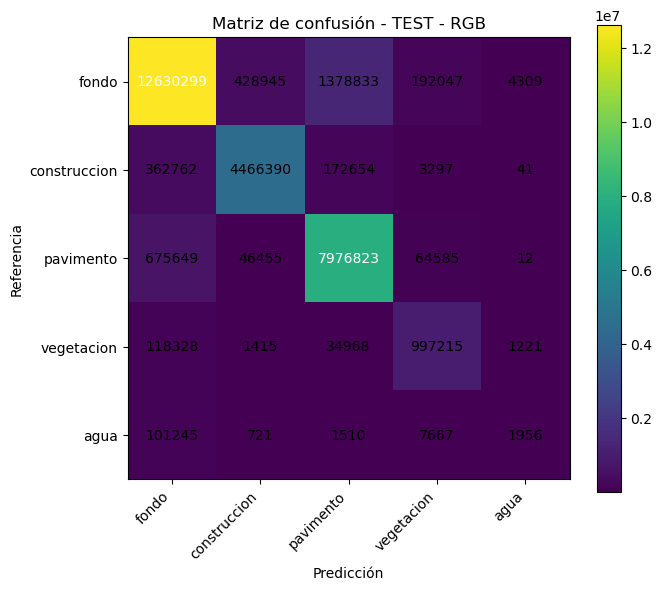

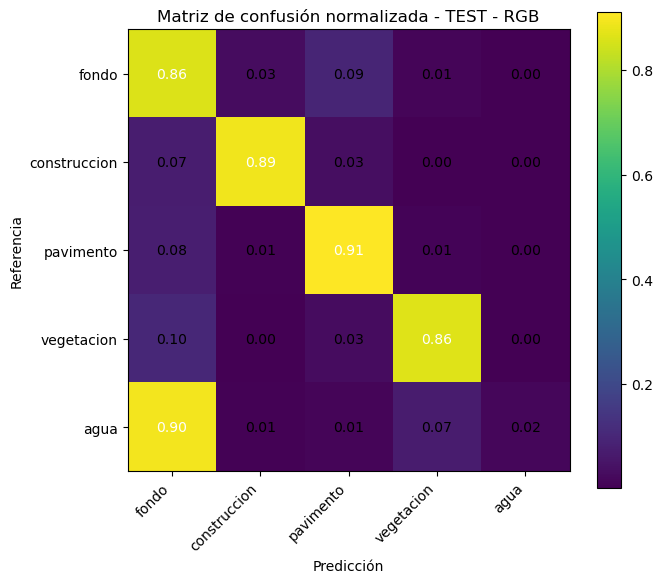

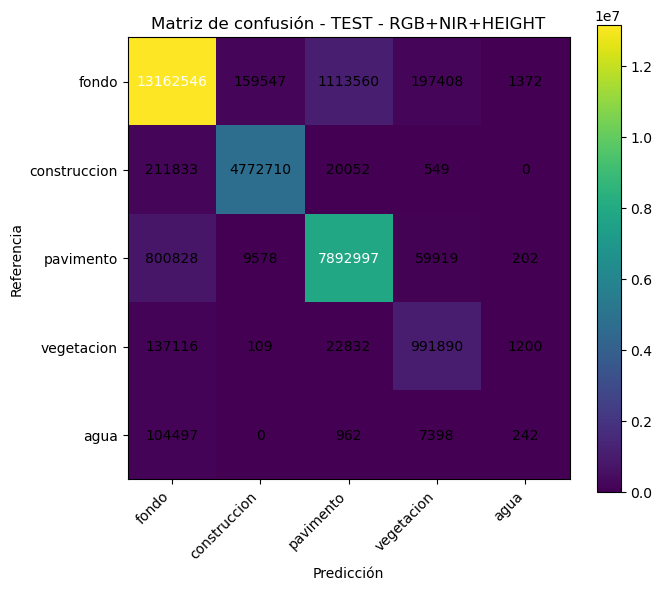

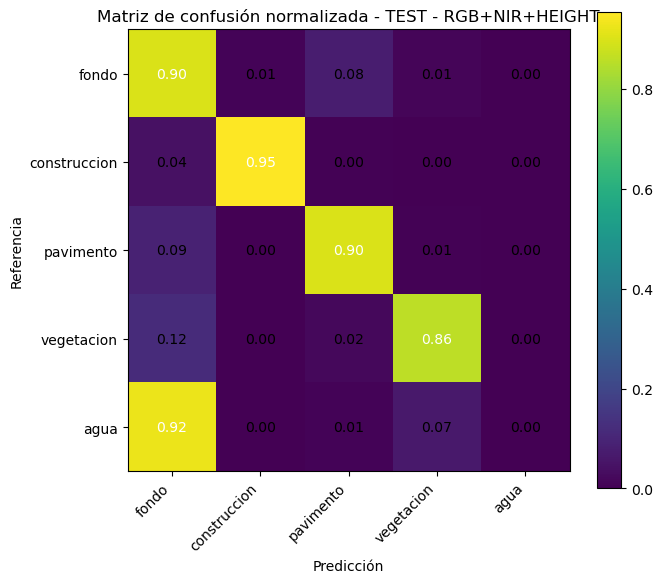

In [80]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names, title="Matriz de confusión", normalize=False):
    cm_plot = cm.astype(np.float64).copy()

    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm_plot, row_sums, out=np.zeros_like(cm_plot), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_plot, interpolation="nearest")
    fig.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicción")
    ax.set_ylabel("Referencia")
    ax.set_title(title)

    fmt = ".2f" if normalize else "d"
    thresh = cm_plot.max() / 2.0 if cm_plot.max() > 0 else 0.5

    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            value = cm_plot[i, j]
            text = format(value, fmt) if normalize else f"{int(value)}"
            ax.text(
                j, i, text,
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )

    plt.tight_layout()
    plt.show()


# RGB
plot_confusion_matrix(
    cm_rgb_test,
    class_names=class_names,
    title="Matriz de confusión - TEST - RGB",
    normalize=False
)

plot_confusion_matrix(
    cm_rgb_test,
    class_names=class_names,
    title="Matriz de confusión normalizada - TEST - RGB",
    normalize=True
)

# MULTIFUENTE
plot_confusion_matrix(
    cm_multi_test,
    class_names=class_names,
    title="Matriz de confusión - TEST - RGB+NIR+HEIGHT",
    normalize=False
)

plot_confusion_matrix(
    cm_multi_test,
    class_names=class_names,
    title="Matriz de confusión normalizada - TEST - RGB+NIR+HEIGHT",
    normalize=True
)

***LECTURA ESPECÍFICA DE LA CLASE AGUA***

In [81]:
# =========================================================
# Lectura específica de la clase AGUA
# =========================================================

clase_objetivo = "agua"  # cambia aquí si tu nombre exacto es distinto

def extract_class_row(df, class_name):
    row = df[df["clase"].str.lower() == class_name.lower()]
    if len(row) == 0:
        return None
    return row.iloc[0]

row_rgb_water = extract_class_row(rgb_per_class_test, clase_objetivo)
row_multi_water = extract_class_row(multi_per_class_test, clase_objetivo)

if row_rgb_water is not None and row_multi_water is not None:
    print("=== CLASE AGUA ===")
    print(f"RGB -> Precision: {row_rgb_water['precision']:.4f} | Recall: {row_rgb_water['recall']:.4f} | F1: {row_rgb_water['f1']:.4f} | IoU: {row_rgb_water['iou']:.4f}")
    print(f"RGB+NIR+HEIGHT -> Precision: {row_multi_water['precision']:.4f} | Recall: {row_multi_water['recall']:.4f} | F1: {row_multi_water['f1']:.4f} | IoU: {row_multi_water['iou']:.4f}")

    diff_f1 = row_multi_water["f1"] - row_rgb_water["f1"]
    diff_iou = row_multi_water["iou"] - row_rgb_water["iou"]

    print("\nInterpretación:")
    if diff_f1 > 0:
        print(f"- El experimento multifuente mejora el F1 de la clase agua en {diff_f1:.4f}.")
    elif diff_f1 < 0:
        print(f"- El experimento multifuente reduce el F1 de la clase agua en {abs(diff_f1):.4f}.")
    else:
        print("- No se observa cambio en el F1 de la clase agua.")

    if row_multi_water["recall"] < 0.10:
        print("- El recall sigue siendo muy bajo, lo que sugiere dificultades para recuperar correctamente los píxeles de agua.")
    if row_multi_water["support"] < 1000:
        print("- La clase agua parece tener poco soporte, lo que puede afectar su estabilidad estadística.")
else:
    print("No se encontró la clase 'agua'. Revisa el nombre exacto en class_names.")

=== CLASE AGUA ===
RGB -> Precision: 0.2595 | Recall: 0.0173 | F1: 0.0324 | IoU: 0.0165
RGB+NIR+HEIGHT -> Precision: 0.0802 | Recall: 0.0021 | F1: 0.0042 | IoU: 0.0021

Interpretación:
- El experimento multifuente reduce el F1 de la clase agua en 0.0283.
- El recall sigue siendo muy bajo, lo que sugiere dificultades para recuperar correctamente los píxeles de agua.


## Interpretación general de los resultados en test

La comparación final debe sustentarse en el conjunto de prueba, ya que este representa la evidencia más sólida de generalización fuera del proceso de ajuste. En este contexto, se compararon dos configuraciones: un modelo base con entrada RGB y un modelo multifuente con entrada RGB, NIR y HEIGHT (nDSM). La comparación se realizó empleando las mismas clases, el mismo criterio de exclusión de píxeles ignorados y el mismo protocolo de evaluación.

Las métricas globales permiten establecer si la incorporación de información multifuente mejora el desempeño general del modelo, particularmente en términos de exactitud global, F1 macro e IoU media. Sin embargo, estas métricas deben complementarse con un análisis por clase, dado que el comportamiento puede variar entre coberturas mayoritarias y minoritarias. En especial, la clase agua debe interpretarse con cautela si presenta bajo soporte o bajo recall, ya que en esos casos una exactitud global alta puede ocultar debilidades importantes en la segmentación de clases menos representadas.

Finalmente, la comparación del tiempo de entrenamiento y del tiempo de inferencia permite complementar la evaluación de exactitud con una lectura del costo computacional, lo cual resulta pertinente cuando se desea valorar la conveniencia práctica de incorporar fuentes adicionales al modelo.

***BOUNDARY-F1***

In [82]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from scipy.ndimage import binary_dilation
from skimage.segmentation import find_boundaries

In [83]:
# =========================================================
# Boundary-F1
# =========================================================

def boundary_map_from_mask(mask_2d):
    """
    Genera mapa binario de bordes para una máscara 2D multiclase.
    """
    return find_boundaries(mask_2d, mode="thick").astype(np.uint8)


def boundary_f1_binary(gt_boundary, pred_boundary, tolerance=2):
    """
    Calcula Precision, Recall y F1 de bordes binarios con tolerancia.
    """
    gt_boundary = gt_boundary.astype(bool)
    pred_boundary = pred_boundary.astype(bool)

    if gt_boundary.sum() == 0 and pred_boundary.sum() == 0:
        return {"precision": 1.0, "recall": 1.0, "f1": 1.0}
    if gt_boundary.sum() == 0 and pred_boundary.sum() > 0:
        return {"precision": 0.0, "recall": 1.0, "f1": 0.0}
    if gt_boundary.sum() > 0 and pred_boundary.sum() == 0:
        return {"precision": 1.0, "recall": 0.0, "f1": 0.0}

    gt_dil = binary_dilation(gt_boundary, iterations=tolerance)
    pred_dil = binary_dilation(pred_boundary, iterations=tolerance)

    matched_pred = pred_boundary & gt_dil
    matched_gt = gt_boundary & pred_dil

    precision = matched_pred.sum() / max(pred_boundary.sum(), 1)
    recall = matched_gt.sum() / max(gt_boundary.sum(), 1)

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }


def collect_predictions_as_maps(model, dataloader, device, ignore_index=255):
    """
    Devuelve listas de máscaras 2D (gt y pred) para cada muestra del dataloader.
    """
    model.eval()
    gt_masks = []
    pred_masks = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                x = batch[0].to(device)
                y = batch[1]
            elif isinstance(batch, dict):
                x = batch["image"].to(device)
                y = batch["mask"]
            else:
                raise TypeError(f"Formato de batch no soportado: {type(batch)}")

            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            y = y.cpu().numpy() if torch.is_tensor(y) else np.asarray(y)

            for i in range(pred.shape[0]):
                gt_i = y[i]
                pred_i = pred[i]

                # reemplazar ignore_index por fondo temporalmente para borde multiclase
                gt_i = gt_i.copy()
                gt_i[gt_i == ignore_index] = 0

                gt_masks.append(gt_i)
                pred_masks.append(pred_i)

    return gt_masks, pred_masks


def evaluate_boundary_f1_multiclass(model, dataloader, device, tolerance=2, ignore_index=255):
    gt_masks, pred_masks = collect_predictions_as_maps(
        model=model,
        dataloader=dataloader,
        device=device,
        ignore_index=ignore_index
    )

    precisions, recalls, f1s = [], [], []

    for gt, pred in zip(gt_masks, pred_masks):
        gt_b = boundary_map_from_mask(gt)
        pred_b = boundary_map_from_mask(pred)

        res = boundary_f1_binary(gt_b, pred_b, tolerance=tolerance)
        precisions.append(res["precision"])
        recalls.append(res["recall"])
        f1s.append(res["f1"])

    return {
        "boundary_precision": float(np.mean(precisions)),
        "boundary_recall": float(np.mean(recalls)),
        "boundary_f1": float(np.mean(f1s))
    }


def evaluate_boundary_f1_for_class(model, dataloader, class_id, device, tolerance=2, ignore_index=255):
    gt_masks, pred_masks = collect_predictions_as_maps(
        model=model,
        dataloader=dataloader,
        device=device,
        ignore_index=ignore_index
    )

    precisions, recalls, f1s = [], [], []

    for gt, pred in zip(gt_masks, pred_masks):
        gt_bin = (gt == class_id).astype(np.uint8)
        pred_bin = (pred == class_id).astype(np.uint8)

        gt_b = find_boundaries(gt_bin, mode="thick").astype(np.uint8)
        pred_b = find_boundaries(pred_bin, mode="thick").astype(np.uint8)

        res = boundary_f1_binary(gt_b, pred_b, tolerance=tolerance)
        precisions.append(res["precision"])
        recalls.append(res["recall"])
        f1s.append(res["f1"])

    return {
        "class_id": class_id,
        "boundary_precision": float(np.mean(precisions)),
        "boundary_recall": float(np.mean(recalls)),
        "boundary_f1": float(np.mean(f1s))
    }

In [84]:
# =========================================================
# Boundary-F1 multiclase en TEST
# =========================================================

rgb_bf1_multi = evaluate_boundary_f1_multiclass(
    model=rgb_model,
    dataloader=test_rgb_loader,
    device=device,
    tolerance=2,
    ignore_index=IGNORE_INDEX
)

multi_bf1_multi = evaluate_boundary_f1_multiclass(
    model=multisource_model,
    dataloader=test_multisource_loader,
    device=device,
    tolerance=2,
    ignore_index=IGNORE_INDEX
)

df_boundary_multiclass = pd.DataFrame([
    {
        "experimento": "RGB",
        **rgb_bf1_multi
    },
    {
        "experimento": "RGB+NIR+HEIGHT",
        **multi_bf1_multi
    }
])

display(df_boundary_multiclass)

,experimento,boundary_precision,boundary_recall,boundary_f1
0,RGB,0.292514,0.439629,0.308963
1,RGB+NIR+HEIGHT,0.358128,0.447761,0.362221


***BOUNDARY-F1 PARA CONSTRUCCIONES***

In [85]:
# =========================================================
# Boundary-F1 clase construccion en TEST
# =========================================================

rgb_bf1_building = evaluate_boundary_f1_for_class(
    model=rgb_model,
    dataloader=test_rgb_loader,
    class_id=1,
    device=device,
    tolerance=2,
    ignore_index=IGNORE_INDEX
)

multi_bf1_building = evaluate_boundary_f1_for_class(
    model=multisource_model,
    dataloader=test_multisource_loader,
    class_id=1,
    device=device,
    tolerance=2,
    ignore_index=IGNORE_INDEX
)

df_boundary_building = pd.DataFrame([
    {
        "experimento": "RGB",
        "clase": "construccion",
        **rgb_bf1_building
    },
    {
        "experimento": "RGB+NIR+HEIGHT",
        "clase": "construccion",
        **multi_bf1_building
    }
])

display(df_boundary_building)

,experimento,clase,class_id,boundary_precision,boundary_recall,boundary_f1
0,RGB,construccion,1,0.475516,0.653279,0.459603
1,RGB+NIR+HEIGHT,construccion,1,0.593670,0.693139,0.561411


In [86]:
# =========================================================
# Resumen final con métricas globales y Boundary-F1
# =========================================================

df_boundary_multiclass_small = df_boundary_multiclass[[
    "experimento", "boundary_precision", "boundary_recall", "boundary_f1"
]].rename(columns={
    "boundary_precision": "bf1_multi_precision",
    "boundary_recall": "bf1_multi_recall",
    "boundary_f1": "bf1_multi_f1"
})

df_boundary_building_small = df_boundary_building[[
    "experimento", "boundary_precision", "boundary_recall", "boundary_f1"
]].rename(columns={
    "boundary_precision": "bf1_constr_precision",
    "boundary_recall": "bf1_constr_recall",
    "boundary_f1": "bf1_constr_f1"
})

df_summary_geom = df_global_test.merge(df_boundary_multiclass_small, on="experimento", how="left")
df_summary_geom = df_summary_geom.merge(df_boundary_building_small, on="experimento", how="left")

display(df_summary_geom)

,experimento,overall_acc,macro_f1,mean_iou,bf1_multi_precision,bf1_multi_recall,bf1_multi_f1,bf1_constr_precision,bf1_constr_recall,bf1_constr_f1
0,RGB,0.878775,0.702237,0.619670,0.292514,0.439629,0.308963,0.475516,0.653279,0.459603
1,RGB+NIR+HEIGHT,0.903976,0.715829,0.649553,0.358128,0.447761,0.362221,0.593670,0.693139,0.561411


## Evaluación geométrica mediante Boundary-F1

Además de las métricas temáticas tradicionales, se incorporó una evaluación geométrica basada en Boundary-F1 con tolerancia espacial de 2 píxeles. Esta métrica permite valorar en qué medida los contornos predichos coinciden con los contornos de referencia, complementando así el análisis basado en exactitud global, F1 macro e IoU.

Se calcularon dos variantes: una versión multiclase, que evalúa los bordes globales de la segmentación, y una versión específica para la clase construcción, debido a su importancia dentro del problema de identificación de edificaciones. De esta manera, el análisis integra tanto la exactitud temática como la calidad geométrica de la delineación.